# NLP and Deep Learning for Text Classification in Medical Diagnosis

## Text Classification Research Question

RQ1: What is the effectiveness of the NLP algorithm in classifying patient symptoms from the text data on the population level?
- **H10**: Text analysis of patient symptoms results in insufficient precision and recall for provider decision support.
- **H1a**: Text analysis of patient symptoms results in precision and recall sufficient for provider decision support.

## Overview

This notebook implements a complete text classification pipeline to analyze medical symptom descriptions and classify them into appropriate diagnostic categories. We'll evaluate multiple NLP approaches including traditional machine learning methods (SVM, Logistic Regression, Naive Bayes) and deep learning models (CNN and FNN) to determine which provides the best performance for medical symptom classification.

## 1. Text Classification Environment Setup

Import all necessary libraries for our analysis. This includes data manipulation, visualization, NLP, machine learning and deep learning tools.

In [1]:
# Core data manipulation and visualization libraries
import pandas as pd  # For data manipulation and analysis with DataFrames
import numpy as np  # For numerical operations and array handling
import matplotlib.pyplot as plt  # For creating static plots and visualizations
import seaborn as sns  # For statistical data visualization with attractive styling
import plotly.express as px  # For interactive plotting with simple syntax
import plotly.graph_objects as go  # For advanced interactive plotting with detailed control
from plotly.subplots import make_subplots  # For creating subplot layouts in plotly
import re  # For regular expression operations (text pattern matching)
import string  # For string constants and operations
import os  # For operating system interface (file/directory operations)
import warnings  # For controlling warning messages during execution
from wordcloud import WordCloud  # For generating word cloud visualizations
from PIL import Image  # For image processing and manipulation

# NLP libraries
import nltk  # Natural Language Toolkit for text processing
from nltk.corpus import stopwords  # Pre-defined list of common words to filter out
from nltk.tokenize import word_tokenize  # For splitting text into individual words/tokens
from nltk.stem import WordNetLemmatizer, PorterStemmer  # For reducing words to root forms
from textblob import TextBlob  # For sentiment analysis and text processing
import textstat  # For calculating text readability and complexity metrics

# Machine learning libraries
import sklearn  # Comprehensive machine learning library
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score  # For data splitting and model evaluation
from sklearn.preprocessing import LabelEncoder, label_binarize  # For converting categorical labels to numerical format and binary format
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer  # For converting text to numerical features
from sklearn.naive_bayes import MultinomialNB  # Naive Bayes classifier for text classification
from sklearn.linear_model import LogisticRegression  # Linear model for classification tasks
from sklearn.svm import LinearSVC  # Support Vector Machine for classification
from sklearn.ensemble import RandomForestClassifier  # Ensemble method using multiple decision trees
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support  # For model performance evaluation
from sklearn.metrics import roc_curve, auc  # For ROC curve analysis and AUC calculation
from sklearn.pipeline import Pipeline  # For chaining preprocessing and model steps
from imblearn.over_sampling import SMOTE  # For handling imbalanced datasets by generating synthetic samples

# Deep learning libraries
import tensorflow as tf  # Google's deep learning framework
from tensorflow.keras.models import Sequential  # For building neural networks layer by layer
from tensorflow.keras.layers import Dense, Dropout, Embedding, GlobalMaxPooling1D, Conv1D, MaxPooling1D  # Various neural network layer types
from tensorflow.keras.preprocessing.text import Tokenizer  # For converting text to sequences of numbers
from tensorflow.keras.preprocessing.sequence import pad_sequences  # For making all text sequences the same length
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint  # For controlling training process and saving best models
from tensorflow.keras.utils import to_categorical  # For one-hot encoding categorical variables

# Suppress warnings
warnings.filterwarnings('ignore')  # Hide warning messages to keep output clean

# Download NLTK resources
try:
    nltk.data.find('tokenizers/punkt')  # Check if punkt tokenizer is already downloaded
    nltk.data.find('corpora/stopwords')  # Check if stopwords corpus is already downloaded
    nltk.data.find('corpora/wordnet')  # Check if wordnet corpus is already downloaded
except LookupError:
    nltk.download('punkt')  # Download sentence tokenizer if not found
    nltk.download('stopwords')  # Download list of common words if not found
    nltk.download('wordnet')  # Download word database for lemmatization if not found

# Set random seeds for reproducibility
np.random.seed(42)  # Ensure numpy random operations produce consistent results
tf.random.set_seed(42)  # Ensure tensorflow random operations produce consistent results

# Configure visualization settings
plt.style.use('fivethirtyeight')  # Apply FiveThirtyEight website's plotting style
sns.set(style='whitegrid')  # Set seaborn to use white background with grid lines

# Display versions of key libraries
print(f"Pandas version: {pd.__version__}")  # Show pandas version for compatibility checking
print(f"NumPy version: {np.__version__}")  # Show numpy version for compatibility checking
print(f"TensorFlow version: {tf.__version__}")  # Show tensorflow version for compatibility checking
print(f"Scikit-learn version: {sklearn.__version__}")  # Show scikit-learn version for compatibility checking

Pandas version: 2.0.2
NumPy version: 1.23.5
TensorFlow version: 2.12.0
Scikit-learn version: 1.0.2


[nltk_data] Downloading package punkt to C:\Users\S-C-R-E-
[nltk_data]     A-M\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\S-C-R-E-
[nltk_data]     A-M\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\S-C-R-E-
[nltk_data]     A-M\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## 2. Text Classification Data Loading and Exploration

**Purpose:** Load the dataset and explore its structure. Focus on the key fields for our analysis: 'phrase' (patient descriptions) and 'prompt' (diagnostic categories).

#### Data Variables
**Text Classification Variables:**

- **phrase:**  
  This variable contains the text entries (e.g., sentences or phrases) that will be classified. In text classification tasks, the model analyzes these phrases to categorize them based on their content.

- **prompt:**  
  Similar to audio classification, the prompt variable in text classification indicates the corresponding labels or categories for the text entries. The prompt variable typically represents the classification target (e.g., medical diagnoses).

In [2]:
# Define the dataset path - specify the complete file path to the CSV file containing medical speech data
data_path = r'G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\data\Medical Speech, Transcription, and Intent\overview-of-recordings.csv'

# Load the dataset - read the CSV file into a pandas DataFrame for data manipulation and analysis
df = pd.read_csv(data_path)

# Define key fields for analysis as specified - these are the two main columns we'll focus on for text classification
key_fields = ['phrase', 'prompt']  # 'phrase' contains patient symptom descriptions, 'prompt' contains diagnostic categories

# Display basic information about the dataset - show the structure and size of our loaded data
print(f"Dataset shape: {df.shape}")  # Shows (number of rows, number of columns)
print(f"\nDataset columns: {df.columns.tolist()}")  # Lists all available column names in the dataset
print(f"\nKey fields for analysis: {key_fields}")  # Confirms which columns we'll use for our NLP analysis

# Display the first few rows of the dataset focused on our key fields - preview the actual data we'll be working with
print("\nSample data (first 5 rows):")
df[key_fields].head()  # Shows first 5 rows of only the 'phrase' and 'prompt' columns to understand data structure

Dataset shape: (6661, 13)

Dataset columns: ['audio_clipping', 'audio_clipping:confidence', 'background_noise_audible', 'background_noise_audible:confidence', 'overall_quality_of_the_audio', 'quiet_speaker', 'quiet_speaker:confidence', 'speaker_id', 'file_download', 'file_name', 'phrase', 'prompt', 'writer_id']

Key fields for analysis: ['phrase', 'prompt']

Sample data (first 5 rows):


,phrase,prompt
0,When I remember her I feel down,Emotional pain
1,When I carry heavy things I feel like breaking...,Hair falling out
2,there is too much pain when i move my arm,Heart hurts
3,My son had his lip pierced and it is swollen a...,Infected wound
4,My muscles in my lower back are aching,Infected wound


### 2.1 Text Classification Data Cleaning (Data Quality Check)

**Purpose:** Check for missing values, duplicates, and other data quality issues in our key fields.

In [3]:
# Check for missing values in key fields
print("Missing values in key fields:")
print(df[key_fields].isna().sum())  # Count null/NaN values in 'phrase' and 'prompt' columns to identify data quality issues

# Check for duplicates in phrases
duplicates = df.duplicated(subset=['phrase']).sum()  # Count how many patient symptom descriptions appear more than once in the dataset
print(f"\nDuplicate phrases: {duplicates}")

# Check class distribution (diagnostic categories)
print("\nClass distribution (top 10 diagnostic categories):")
class_distribution = df['prompt'].value_counts()  # Count frequency of each diagnostic category to understand dataset balance
print(class_distribution.head(10))

# Calculate class imbalance statistics
total_classes = len(class_distribution)  # Get total number of unique diagnostic categories in the dataset
print(f"\nTotal number of unique diagnostic categories: {total_classes}")

# Check statistics on text length
df['phrase_length'] = df['phrase'].str.len()  # Calculate character length of each patient symptom description for preprocessing insights
print("\nText length statistics:")
print(df['phrase_length'].describe())  # Display statistical summary (mean, std, min, max) of text lengths

# Remove temporary column
df.drop('phrase_length', axis=1, inplace=True)  # Clean up by removing the temporary length column to keep dataset tidy

Missing values in key fields:
phrase    0
prompt    0
dtype: int64

Duplicate phrases: 5955

Class distribution (top 10 diagnostic categories):
prompt
Acne              328
Shoulder pain     320
Joint pain        318
Infected wound    306
Knee pain         305
Cough             293
Feeling dizzy     283
Muscle pain       282
Heart hurts       273
Ear ache          270
Name: count, dtype: int64

Total number of unique diagnostic categories: 25

Text length statistics:
count    6661.000000
mean       50.026122
std        23.672184
min         9.000000
25%        33.000000
50%        45.000000
75%        61.000000
max       155.000000
Name: phrase_length, dtype: float64


### 2.2 Text Classification Data Visualization

**Purpose:** Visualize the class distribution and text characteristics to gain a better understanding of our dataset.

In [4]:
# Visualize class distribution (top 15 categories)
top_n = 15  # Set the number of top diagnostic categories to display in our visualization
top_categories = class_distribution.head(top_n).reset_index()  # Extract the 15 most frequent diagnostic categories and reset index to create a clean dataframe
top_categories.columns = ['Category', 'Count']  # Rename columns to more descriptive names for clarity in visualization

# Create an interactive bar chart showing the distribution of diagnostic categories
fig = px.bar(top_categories, x='Category', y='Count', 
             title=f'Distribution of Top {top_n} Diagnostic Categories',  # Dynamic title that shows exactly how many categories we're displaying
             color='Count', color_continuous_scale='viridis')  # Color bars based on count values using a professional color scheme
fig.update_layout(xaxis={'categoryorder':'total descending'})  # Ensure categories are ordered from highest to lowest count for better readability
fig.show()  # Display the interactive chart

# Calculate text length metrics for preprocessing insights
df['text_length'] = df['phrase'].apply(len)  # Count the number of characters in each patient symptom description
df['word_count'] = df['phrase'].apply(lambda x: len(str(x).split()))  # Count the number of words in each patient symptom description by splitting on spaces

# Visualize text length distribution using subplots for comprehensive analysis
fig = make_subplots(rows=1, cols=2, 
                    subplot_titles=('Distribution of Text Length (Characters)', 
                                  'Distribution of Word Count'))  # Create side-by-side histograms with descriptive titles

# Add histogram for character length distribution
fig.add_trace(
    go.Histogram(x=df['text_length'], nbinsx=30, marker_color='blue'),  # Create histogram with 30 bins to show character length distribution patterns
    row=1, col=1  # Place in the first subplot position
)

# Add histogram for word count distribution
fig.add_trace(
    go.Histogram(x=df['word_count'], nbinsx=30, marker_color='green'),  # Create histogram with 30 bins to show word count distribution patterns
    row=1, col=2  # Place in the second subplot position
)

fig.update_layout(height=500, width=1000, title_text="Text Length Analysis")  # Set figure dimensions and overall title for the analysis
fig.show()  # Display the comprehensive text length analysis

# Remove temporary columns to keep dataset clean
df.drop(['text_length', 'word_count'], axis=1, inplace=True)  # Delete the temporary analysis columns since we only needed them for visualization, not for model training

## 3. Text Data Preprocessing

**Purpose:** Transforming the cleaned text data into a format suitable for machine learning algorithms.

### 3.1 Define Basic Text Cleaning Function

**Purpose:** To clean the raw text data by converting it to lowercase, replacing contractions, removing special characters, and extra whitespaces.

In [5]:
def clean_text(text):
    """Basic text cleaning function"""
    if isinstance(text, str):  # Check if text is a string
        # Convert to lowercase for standardization - ensures consistent text processing regardless of original case
        text = text.lower()
        
        # Replace contractions with full words - expands common English contractions to improve text analysis accuracy
        text = re.sub(r"what's", "what is", text)
        text = re.sub(r"'s", " is", text)
        text = re.sub(r"'ve", " have", text)
        text = re.sub(r"can't", "cannot", text)
        text = re.sub(r"n't", " not", text)
        text = re.sub(r"'re", " are", text)
        text = re.sub(r"'d", " would", text)
        text = re.sub(r"'ll", " will", text)
        text = re.sub(r"'t", " not", text)
        
        # Remove special characters and digits - keeps only alphabetic characters and spaces for cleaner text analysis
        text = re.sub(r"[^a-zA-Z\s]", "", text)
        
        # Remove extra whitespaces - consolidates multiple spaces into single spaces and removes leading/trailing whitespace
        text = re.sub(r'\s+', ' ', text).strip()
        
        return text
    else:
        return ""  # Return empty string if input is not a string type to prevent processing errors

### 3.2 Initialize Natural Language Toolkit (NLTK) Components for Text Classification

**Purpose:** Set up the necessary tools for advanced preprocessing, such as stopword lists and lemmatizers.

In [6]:
# Initialize NLTK components for advanced text preprocessing
stop_words = set(stopwords.words('english'))  # Load standard English stopwords (common words like 'the', 'and', 'is' that don't carry much meaning)
medical_stopwords_to_keep = {'pain', 'ache', 'fever', 'swelling', 'rash'}  # Define medical terms that are important for symptom analysis and should NOT be removed
filtered_stop_words = stop_words - medical_stopwords_to_keep  # Create final stopwords list by removing medical terms from standard stopwords to preserve critical symptom information
lemmatizer = WordNetLemmatizer()  # Initialize lemmatizer to reduce words to their root form (e.g., 'running' -> 'run', 'better' -> 'good')

### 3.3 Define Advanced Text Classification Preprocessing Function

**Purpose:** Combine basic cleaning with tokenization, stopword removal, and lemmatization for more refined text processing.

**Key Components:**
1. **Tokenization:** This involves breaking down a sentence or paragraph into smaller units, which can be words, punctuation marks, or other meaningful units.

2. **Stopword Removal:** This step removes common words that don't add much meaning to the text and can be noise for analysis. Examples include "the," "a," "an," "is," and "are."

3. **Lemmatization:** This reduces words to their root form, ensuring that "feeling," "felt," and "feels" are all reduced to "run." It also considers the word's context and part of speech, making it more accurate than stemming.

In [7]:
def advanced_preprocess(text):
    """Advanced preprocessing with tokenization, stopword removal, and lemmatization"""
    # Check if input is valid string with content - return empty string if not to prevent errors
    if not isinstance(text, str) or len(text) == 0:
        return ""
    
    # Apply basic text cleaning first (lowercase, remove punctuation, fix contractions)
    text = clean_text(text)
    
    # Split text into individual words/tokens for processing each word separately
    tokens = word_tokenize(text)
    
    # Remove common words (stopwords) that don't add meaning and reduce each word to its root form (lemmatization)
    tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in filtered_stop_words]
    
    # Combine the processed tokens back into a single cleaned text string
    processed_text = ' '.join(tokens)
    
    return processed_text

### 3.4 Process the Text Data

**Purpose:** Apply the cleaning and advanced preprocessing functions to the specified column of the DataFrame and create new columns for cleaned and processed text.

In [8]:
# Process the text data
print("Preprocessing text data...")
df['clean_phrase'] = df['phrase'].apply(clean_text)  # Apply basic text cleaning (lowercase, remove punctuation, expand contractions) to create standardized text for analysis
df['processed_phrase'] = df['phrase'].apply(advanced_preprocess)  # Apply advanced NLP preprocessing (tokenization, stopword removal, lemmatization) to prepare text for machine learning models

Preprocessing text data...


### 3.5 Display Sample Results

**Purpose:** Show a random sample of original, cleaned, and processed text to verify the effectiveness of the preprocessing steps.

In [9]:
# Display samples of original and processed text
print("\nSample text preprocessing results:")
sample_idx = np.random.randint(0, len(df), 5)  # Generate 5 random indices from the dataset to show diverse examples of text preprocessing
for idx in sample_idx:
    print(f"\nOriginal: {df.iloc[idx]['phrase']}")  # Show the raw patient symptom description as originally entered
    print(f"Cleaned: {df.iloc[idx]['clean_phrase']}")  # Show the text after basic cleaning (lowercase, punctuation removal, contraction expansion)
    print(f"Processed: {df.iloc[idx]['processed_phrase']}")  # Show the final preprocessed text ready for machine learning (tokenized, stopwords removed, lemmatized)


Sample text preprocessing results:

Original: My shoulder has agreat pain
Cleaned: my shoulder has agreat pain
Processed: shoulder agreat pain

Original: I have a sharp pain in my neck
Cleaned: i have a sharp pain in my neck
Processed: sharp pain neck

Original: I have acne in my face and other problema in my derma like itching
Cleaned: i have acne in my face and other problema in my derma like itching
Processed: acne face problema derma like itching

Original: There is an injured person
Cleaned: there is an injured person
Processed: injured person

Original: I can't carry anything I have a pain in my shoulder
Cleaned: i cannot carry anything i have a pain in my shoulder
Processed: carry anything pain shoulder


## 4. Text Classification Feature Engineering

**Purpose:** Transforming the preprocessed text into numerical features that machine learning models can understand.

### 4.1 Define the Function for Extracting Text Features

**Purpose:** Create a function extract_text_features that captures various linguistic features (sentiment polarity, sentiment subjectivity, text complexity) from the text.

In [10]:
def extract_text_features(text):
    """
    Extract sophisticated linguistic features from text for enhanced classification
    
    Args:
        text (str): The input text to analyze
        
    Returns:
        pandas.Series: A row of features ready to be combined with the main dataset
    """
    # Handle edge cases: return zeros if input is not a valid string or is empty
    if not isinstance(text, str) or len(text) == 0:
        return pd.Series({'sentiment_polarity': 0, 'sentiment_subjectivity': 0, 'text_complexity': 0})
    
    # Sentiment Analysis using TextBlob - analyzes emotional tone and subjectivity of patient descriptions
    blob = TextBlob(text)  # Create TextBlob object to perform natural language processing on the text
    sentiment_polarity = blob.sentiment.polarity  # Extract polarity score (-1 = negative, 0 = neutral, +1 = positive emotion)
    sentiment_subjectivity = blob.sentiment.subjectivity  # Extract subjectivity score (0 = objective/factual, 1 = subjective/opinion-based)
    
    # Text Complexity Analysis - measures how difficult the text is to read (important for medical communication)
    try:
        text_complexity = textstat.flesch_reading_ease(text)  # Calculate Flesch Reading Ease score (higher = easier to read, 0-100 scale)
    except:
        text_complexity = 0  # Set to 0 if calculation fails to prevent errors
    
    # Return all extracted features as a pandas Series for easy integration with the main dataset
    return pd.Series({
        'sentiment_polarity': sentiment_polarity,
        'sentiment_subjectivity': sentiment_subjectivity,
        'text_complexity': text_complexity
    })

 ### 4.2 Extract Additional Text Features

 **Purpose:** Apply the feature extraction function to the cleaned text data and add the features to the DataFrame.

In [11]:
print("Extracting additional text features...")
# Apply the feature extraction function to each cleaned phrase to create new columns containing sentiment polarity, sentiment subjectivity, and text complexity scores - these linguistic features will enhance our machine learning models by providing emotional tone and readability insights from patient symptom descriptions
additional_features = df['clean_phrase'].apply(extract_text_features)
# Combine the original DataFrame with the newly extracted features by concatenating them horizontally (axis=1) to create a comprehensive dataset that includes both the original text data and the computed linguistic features
df = pd.concat([df, additional_features], axis=1)

Extracting additional text features...


### 4.3 Text Label Encoding the Target Variable

**Purpose:** Use LabelEncoder to encode the target variable (prompt) into a numerical format for classification tasks.

In [12]:
print("\nEncoding target variable...")
label_encoder = LabelEncoder()  # Create a LabelEncoder object to convert text labels (diagnostic categories) into numerical values that machine learning models can process
df['prompt_encoded'] = label_encoder.fit_transform(df['prompt'])  # Transform diagnostic category names like 'Acne', 'Back pain' into numbers like 0, 1, 2, etc. and store in new column

# Save the mapping of encoded labels
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))  # Create a dictionary showing which number corresponds to which diagnostic category (e.g., 'Acne' -> 0)
print(f"\nNumber of classes: {len(label_mapping)}")  # Display how many different diagnostic categories we have in our dataset

# Print out the initial classes
print(f"\nInitial classes (diagnostic categories):")
print("="*50)
for i, class_name in enumerate(label_encoder.classes_):  # Loop through each diagnostic category and show its assigned number
    print(f"{i:2d}: {class_name}")

print(f"\nLabel mapping (class name -> encoded value):")
print("="*50)
for class_name, encoded_value in sorted(label_mapping.items()):  # Display the mapping in alphabetical order to see which diagnostic category gets which number
    print(f"'{class_name}' -> {encoded_value}")

# Show class distribution with encoded values
print(f"\nClass distribution with encoded values:")
print("="*45)
class_dist_encoded = df['prompt_encoded'].value_counts().sort_index()  # Count how many samples we have for each diagnostic category (by their encoded numbers)
for encoded_value, count in class_dist_encoded.items():  # For each encoded number, show the original diagnostic category name and how many samples we have
    class_name = label_encoder.inverse_transform([encoded_value])[0]  # Convert the number back to the original diagnostic category name
    print(f"Class {encoded_value:2d} ({class_name}): {count} samples")


Encoding target variable...

Number of classes: 25

Initial classes (diagnostic categories):
 0: Acne
 1: Back pain
 2: Blurry vision
 3: Body feels weak
 4: Cough
 5: Ear ache
 6: Emotional pain
 7: Feeling cold
 8: Feeling dizzy
 9: Foot ache
10: Hair falling out
11: Hard to breath
12: Head ache
13: Heart hurts
14: Infected wound
15: Injury from sports
16: Internal pain
17: Joint pain
18: Knee pain
19: Muscle pain
20: Neck pain
21: Open wound
22: Shoulder pain
23: Skin issue
24: Stomach ache

Label mapping (class name -> encoded value):
'Acne' -> 0
'Back pain' -> 1
'Blurry vision' -> 2
'Body feels weak' -> 3
'Cough' -> 4
'Ear ache' -> 5
'Emotional pain' -> 6
'Feeling cold' -> 7
'Feeling dizzy' -> 8
'Foot ache' -> 9
'Hair falling out' -> 10
'Hard to breath' -> 11
'Head ache' -> 12
'Heart hurts' -> 13
'Infected wound' -> 14
'Injury from sports' -> 15
'Internal pain' -> 16
'Joint pain' -> 17
'Knee pain' -> 18
'Muscle pain' -> 19
'Neck pain' -> 20
'Open wound' -> 21
'Shoulder pain' -> 2

### 4.4 Split the Text Data into Training, Validation, and Testing Sets (64/16/20)

**Purpose:** Divide the processed text data and encoded labels into training, validation, and testing datasets using stratified sampling to maintain class distribution across all splits.

- **Training Set (64%):** Used to train the model parameters
- **Validation Set (16%):** Used for hyperparameter tuning and model selection during development
- **Testing Set (20%):** Used for final model evaluation on completely unseen data

This three-way split helps prevent overfitting and provides a robust evaluation framework by ensuring the model is tested on data it has never seen during training or validation.

In [13]:
# Extract processed text features (X) and encoded diagnostic categories (y) from the preprocessed DataFrame for model training
X = df['processed_phrase']  # Text data that has been cleaned, tokenized, and preprocessed for machine learning
y = df['prompt_encoded']    # Diagnostic categories converted to numerical labels (0-24) for classification

# First split: separate test set (20% of total data)
# This creates a holdout test set that will NOT be used during training or validation to ensure unbiased final evaluation
X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify=y ensures each diagnostic category is proportionally represented in both splits
)

# Second split: create validation set from remaining training data (20% of remaining 80% = 16% of total)
# The validation set will be used for hyperparameter tuning and model selection during development
X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp, y_train_temp, test_size=0.2, random_state=42, stratify=y_train_temp  # stratify maintains class balance in train/validation splits
)

# Display the size and percentage distribution of each data split to verify proper partitioning
print(f"Total dataset size: {len(X)}")
print(f"Training set size: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")  # ~64% for training the models
print(f"Validation set size: {X_val.shape[0]} ({X_val.shape[0]/len(X)*100:.1f}%)")    # ~16% for hyperparameter tuning
print(f"Testing set size: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")     # ~20% for final unbiased evaluation

# Verify class distribution across splits
# This ensures that each diagnostic category appears proportionally in all three splits (critical for medical data)
print(f"\nClass distribution verification:")
print(f"Original: {np.bincount(y) / len(y) * 100}")      # Percentage distribution of each diagnostic category in original dataset
print(f"Training: {np.bincount(y_train) / len(y_train) * 100}")    # Should match original distribution
print(f"Validation: {np.bincount(y_val) / len(y_val) * 100}")      # Should match original distribution  
print(f"Testing: {np.bincount(y_test) / len(y_test) * 100}")       # Should match original distribution

Total dataset size: 6661
Training set size: 4262 (64.0%)
Validation set size: 1066 (16.0%)
Testing set size: 1333 (20.0%)

Class distribution verification:
Original: [4.92418556 3.88830506 3.69313917 3.61807536 4.39873893 4.05344543
 3.46794776 3.9483561  4.24861132 3.34784567 3.96336886 3.49797328
 3.9483561  4.09848371 4.59390482 3.45293499 3.72316469 4.77405795
 4.57889206 4.23359856 3.76820297 3.12265426 4.80408347 3.93334334
 3.91833058]
Training: [4.90380103 3.89488503 3.70717973 3.61332708 4.38761145 4.05912717
 3.4725481  3.94181136 4.24683247 3.35523229 3.96527452 3.49601126
 3.94181136 4.08259033 4.59877992 3.44908494 3.70717973 4.76302206
 4.57531675 4.24683247 3.77756922 3.14406382 4.80994838 3.94181136
 3.91834819]
Validation: [4.97185741 3.84615385 3.65853659 3.65853659 4.40900563 4.03377111
 3.47091932 3.93996248 4.22138837 3.37711069 3.93996248 3.47091932
 3.93996248 4.12757974 4.59662289 3.47091932 3.75234522 4.78424015
 4.59662289 4.22138837 3.75234522 3.0956848  4.78

### 4.5 Text Feature Extraction Using TF-IDF Vectorizer (Input Features - Text Vectorization)

**Purpose:** Create a TF-IDF representation of the training, validation, and testing sets to transform the text data into a suitable format for machine learning models.

In [14]:
# Create TF-IDF (Term Frequency-Inverse Document Frequency) vectorizer to convert text into numerical features
# max_features=5000: limit vocabulary to 5000 most important words to prevent overfitting and reduce computational cost
# ngram_range=(1,2): include both single words (unigrams) and two-word phrases (bigrams) to capture more context
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

# Fit the vectorizer on training data and transform it into TF-IDF matrix (learns vocabulary from training set)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transform validation data using the same vocabulary learned from training (prevents data leakage)
X_val_tfidf = tfidf_vectorizer.transform(X_val)

# Transform test data using the same vocabulary learned from training (ensures consistent feature space)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"\nTF-IDF feature shape:")
print(f"Training: {X_train_tfidf.shape}")
print(f"Validation: {X_val_tfidf.shape}")
print(f"Testing: {X_test_tfidf.shape}")


TF-IDF feature shape:
Training: (4262, 3234)
Validation: (1066, 3234)
Testing: (1333, 3234)


## 5. Model Selection (Text Classification)

**Purpose:** Evaluate different machine learning and deep learning algorithms for text classification and select the most suitable one based on initial performance and characteristics.

### 5.1 Text Classification Machine Learning Models

**Purpose:** Select and configure traditional machine learning models for text classification, including Naive Bayes, Support Vector Machine (SVM), Logistic Regression, and Random Forest with appropriate hyperparameters to prevent overfitting.

In [15]:
# Initialize candidate models with appropriate parameters to avoid overfitting
candidate_models = {
    # Naive Bayes classifier with smoothing parameter (alpha=0.1) - good baseline for text classification
    'Multinomial Naive Bayes': MultinomialNB(alpha=0.1),
    # Support Vector Machine with regularization (C=1.0) and iteration limit to prevent infinite training
    'Support Vector Machine': LinearSVC(C=1.0, max_iter=5000, random_state=42),
    # Logistic Regression with regularization (C=1.0) and fixed random seed for reproducible results
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    # Random Forest with limited trees (50) and depth (10) to prevent overfitting on medical text data
    'Random Forest': RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
}
# Display information about selected models to validate initialization and track experiment configuration
print("Selected Machine Learning Models for Text Classification:")
for name, model in candidate_models.items():
    print(f"✓ {name}: {model.__class__.__name__}")
    
# Report total number of models for experiment tracking and computational resource planning
print(f"\nTotal models to evaluate: {len(candidate_models)}")

Selected Machine Learning Models for Text Classification:
✓ Multinomial Naive Bayes: MultinomialNB
✓ Support Vector Machine: LinearSVC
✓ Logistic Regression: LogisticRegression
✓ Random Forest: RandomForestClassifier

Total models to evaluate: 4


#### 5.1.1 Text Classification ML K-fold Cross Validation (Text Model Performance Evaluation)

**Purpose:** Evaluate the performance of different ML models on different subsets of the data

Performing K-Fold Cross-Validation...

Evaluating Multinomial Naive Bayes...
F1-Score: 0.9947 (+/- 0.0090)
Individual fold scores: [0.99906149 0.99623976 0.99812096 0.9865618  0.9934064 ]

Evaluating Support Vector Machine...
F1-Score: 0.9974 (+/- 0.0038)
Individual fold scores: [1.         0.99718274 0.99906134 0.99531583 0.99529109]

Evaluating Logistic Regression...
F1-Score: 0.9961 (+/- 0.0056)
Individual fold scores: [1.         0.99623976 0.99812096 0.99249262 0.99340659]

Evaluating Random Forest...
F1-Score: 0.8570 (+/- 0.0220)
Individual fold scores: [0.84926565 0.87841522 0.8548212  0.85415979 0.84848416]

5-Fold Cross-Validation Results Summary:
                  Model  Mean_F1  Std_F1  Min_F1  Max_F1
 Support Vector Machine   0.9974  0.0019  0.9953  1.0000
    Logistic Regression   0.9961  0.0028  0.9925  1.0000
Multinomial Naive Bayes   0.9947  0.0045  0.9866  0.9991
          Random Forest   0.8570  0.0110  0.8485  0.8784


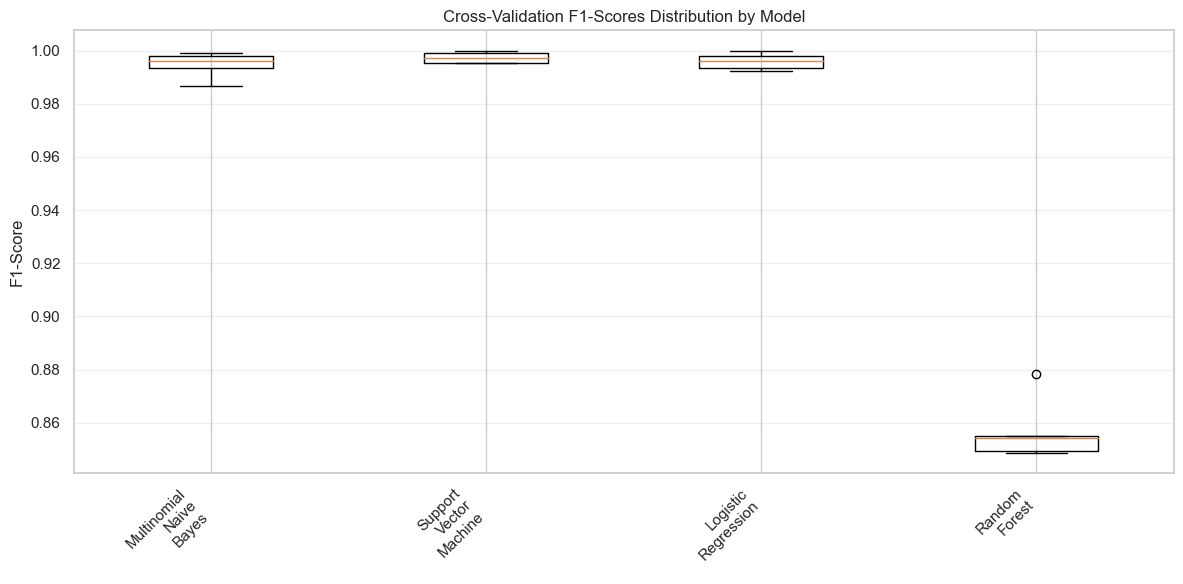


Top 3 models selected for hyperparameter tuning:
1. Support Vector Machine: 0.9974
2. Logistic Regression: 0.9961
3. Multinomial Naive Bayes: 0.9947


In [16]:
# Initialize stratified K-fold cross-validation with 5 folds to ensure each diagnostic category appears proportionally in every fold for robust model evaluation
k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Combine training and validation sets for cross-validation to use all available data for more comprehensive model evaluation
X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

# Transform combined data using TF-IDF vectorization to convert text into numerical features that machine learning models can process
X_train_val_tfidf = tfidf_vectorizer.fit_transform(X_train_val)

# Store cross-validation results in a dictionary to track performance metrics for each model across all folds
cv_results = {}

print("Performing K-Fold Cross-Validation...")
print("="*60)

# Evaluate each machine learning model using cross-validation to get reliable performance estimates
for model_name, model in candidate_models.items():
    print(f"\nEvaluating {model_name}...")
    
    # Perform cross-validation using F1-weighted scoring (balances precision and recall across all diagnostic categories) with parallel processing
    cv_scores = cross_val_score(model, X_train_val_tfidf, y_train_val, 
                               cv=skf, scoring='f1_weighted', n_jobs=-1)
    
    # Store comprehensive results including individual fold scores and statistical measures for detailed analysis
    cv_results[model_name] = {
        'scores': cv_scores,
        'mean': cv_scores.mean(),
        'std': cv_scores.std(),
        'min': cv_scores.min(),
        'max': cv_scores.max()
    }
    
    # Display mean F1-score with confidence interval (±2 standard deviations covers ~95% of expected performance range)
    print(f"F1-Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    print(f"Individual fold scores: {cv_scores}")

# Create summary table with all cross-validation statistics for easy comparison between models
cv_summary = pd.DataFrame({
    'Model': list(cv_results.keys()),
    'Mean_F1': [results['mean'] for results in cv_results.values()],
    'Std_F1': [results['std'] for results in cv_results.values()],
    'Min_F1': [results['min'] for results in cv_results.values()],
    'Max_F1': [results['max'] for results in cv_results.values()]
}).round(4)

# Sort by mean F1-score in descending order to identify the best performing models at the top
cv_summary = cv_summary.sort_values('Mean_F1', ascending=False)

print(f"\n{k_folds}-Fold Cross-Validation Results Summary:")
print("="*60)
print(cv_summary.to_string(index=False))

# Visualize cross-validation results using box plots to show performance distribution and identify models with consistent performance
plt.figure(figsize=(12, 6))
models = list(cv_results.keys())
scores = [cv_results[model]['scores'] for model in models]

# Create box plots with rotated labels to clearly show F1-score distributions for each model across all folds
plt.boxplot(scores, labels=[model.replace(' ', '\n') for model in models])
plt.title('Cross-Validation F1-Scores Distribution by Model')
plt.ylabel('F1-Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)  # Add horizontal grid lines for easier score reading
plt.tight_layout()
plt.show()

# Select top performing models for hyperparameter tuning to focus computational resources on the most promising algorithms
top_models = cv_summary.head(3)['Model'].tolist()
print(f"\nTop 3 models selected for hyperparameter tuning:")
for i, model in enumerate(top_models, 1):
    mean_score = cv_results[model]['mean']
    print(f"{i}. {model}: {mean_score:.4f}")

#### 5.1.2 Text Classification ML Hyperparameter Tuning

**Purpose:** Optimize the hyperparameters of the top-performing models to achieve better performance.

##### 5.1.2.1 Text Classification ML Optimize Model Settings: Define Hyperparameter Grids

**Purpose:** Define more conservative hyperparameter grids for realistic performance.

In [17]:
# Define hyperparameter grids for realistic performance
# Hyperparameters are settings that control how machine learning algorithms learn from data
# We test different combinations to find the best settings for each model type
hyperparameter_grids = {
    # Multinomial Naive Bayes: A probabilistic classifier good for text classification
    'Multinomial Naive Bayes': {
        'alpha': [0.1, 0.5, 1.0, 2.0],  # Smoothing parameter - higher values prevent overfitting to rare words
        'fit_prior': [True, False]  # Whether to learn class probabilities from data (True) or assume equal probabilities (False)
    },
    # Logistic Regression: A linear model that uses probability to make classifications
    'Logistic Regression': {
        'C': [0.1, 1.0, 10.0],  # Regularization strength - smaller values mean stronger regularization to prevent overfitting
        'solver': ['liblinear', 'lbfgs'],  # Algorithm used to optimize the model - different solvers work better with different penalty types
        'penalty': ['l1', 'l2'],  # Type of regularization - l1 removes unimportant features, l2 shrinks all feature weights
        'max_iter': [1000]  # Maximum number of iterations for the solver to converge to a solution
    },
    # Support Vector Machine: Creates decision boundaries to separate different classes
    'Support Vector Machine': {
        'C': [0.1, 1.0, 10.0],  # Regularization parameter - controls trade-off between smooth decision boundary and classifying training points correctly
        'loss': ['hinge', 'squared_hinge'],  # Loss function used - hinge is standard SVM loss, squared_hinge is smoother version
        'max_iter': [5000]  # Maximum iterations to prevent infinite training time
    },
    # Random Forest: Combines many decision trees to make more robust predictions
    'Random Forest': {
        'n_estimators': [50, 100],  # Number of decision trees in the forest - more trees usually mean better performance but slower training
        'max_depth': [10, 20, None],  # Maximum depth of each tree - deeper trees can capture more complex patterns but may overfit
        'min_samples_split': [2, 5],  # Minimum samples required to split an internal node - higher values prevent overfitting
        'min_samples_leaf': [1, 2]  # Minimum samples required to be at a leaf node - higher values create smoother decision boundaries
    }
}

# Filter grids for only top performing models
# Only test hyperparameters for models that performed well in initial cross-validation to save computational time
selected_grids = {model: hyperparameter_grids[model] for model in top_models 
                 if model in hyperparameter_grids}

print("Hyperparameter grids defined for realistic performance:")
for model_name, grid in selected_grids.items():
    print(f"\n{model_name}:")
    for param, values in grid.items():
        print(f"  {param}: {values}")

Hyperparameter grids defined for realistic performance:

Support Vector Machine:
  C: [0.1, 1.0, 10.0]
  loss: ['hinge', 'squared_hinge']
  max_iter: [5000]

Logistic Regression:
  C: [0.1, 1.0, 10.0]
  solver: ['liblinear', 'lbfgs']
  penalty: ['l1', 'l2']
  max_iter: [1000]

Multinomial Naive Bayes:
  alpha: [0.1, 0.5, 1.0, 2.0]
  fit_prior: [True, False]


##### 5.1.2.2 Text Classification ML Grid Search: Systematically Explore Hyperparameter Combinations

**Purpose:** Use GridSearchCV to explore different combinations of hyperparameter values systematically.

In [18]:
# Perform grid search for each top model
# Grid search systematically tests different combinations of hyperparameters to find the best settings
best_models = {}  # Dictionary to store the best-performing model for each algorithm type
grid_search_results = {}  # Dictionary to store detailed results including scores and parameters for each model

print("Performing Grid Search for Hyperparameter Optimization...")
print("="*70)

# Loop through each model that performed well in initial cross-validation testing
for model_name in top_models:
    # Only proceed if we have defined hyperparameter combinations to test for this model
    if model_name in selected_grids:
        print(f"\nOptimizing {model_name}...")
        
        # Get base model
        base_model = candidate_models[model_name]  # Retrieve the original untrained model instance
        param_grid = selected_grids[model_name]  # Get the hyperparameter combinations to test
        
        # Handle special case for Logistic Regression penalty-solver compatibility
        # Different penalty types (l1/l2) only work with specific solvers, so we need separate searches
        if model_name == 'Logistic Regression':
            # Create separate grids for different solver-penalty combinations
            grid_results = []  # Initialize empty list to collect results from multiple searches
            
            # L1 penalty only works with liblinear and saga
            # L1 regularization removes unimportant features by setting their weights to zero
            l1_grid = {
                'C': param_grid['C'],  # Regularization strength values to test
                'solver': ['liblinear'],  # Only solver compatible with L1 penalty
                'penalty': ['l1'],  # L1 regularization type
                'max_iter': param_grid['max_iter']  # Maximum training iterations
            }
            
            # L2 penalty works with both solvers
            # L2 regularization shrinks all feature weights but doesn't remove features completely
            l2_grid = {
                'C': param_grid['C'],  # Same regularization strength values
                'solver': ['liblinear', 'lbfgs'],  # Both solvers work with L2 penalty
                'penalty': ['l2'],  # L2 regularization type
                'max_iter': param_grid['max_iter']  # Maximum training iterations
            }
            
            # Search L1 grid
            # GridSearchCV tests all parameter combinations using cross-validation
            grid_search_l1 = GridSearchCV(
                base_model, l1_grid, cv=3, scoring='f1_weighted',  # Use 3-fold cross-validation with weighted F1 score
                n_jobs=-1, verbose=1  # Use all CPU cores and show progress
            )
            grid_search_l1.fit(X_train_val_tfidf, y_train_val)  # Train on combined training+validation data
            
            # Search L2 grid  
            # Perform separate grid search for L2 penalty combinations
            grid_search_l2 = GridSearchCV(
                base_model, l2_grid, cv=3, scoring='f1_weighted',  # Same settings as L1 search
                n_jobs=-1, verbose=1
            )
            grid_search_l2.fit(X_train_val_tfidf, y_train_val)  # Train on same data for fair comparison
            
            # Select best between L1 and L2
            # Compare the best scores from both searches and choose the superior approach
            if grid_search_l1.best_score_ > grid_search_l2.best_score_:
                grid_search = grid_search_l1  # L1 penalty performed better
            else:
                grid_search = grid_search_l2  # L2 penalty performed better
        else:
            # Standard grid search for other models
            # Most models don't have solver-penalty compatibility issues like Logistic Regression
            grid_search = GridSearchCV(
                base_model, param_grid, cv=3, scoring='f1_weighted',  # Test all parameter combinations
                n_jobs=-1, verbose=1  # Use all available CPU cores and show progress
            )
            grid_search.fit(X_train_val_tfidf, y_train_val)  # Train model with all parameter combinations
        
        # Store results
        # Save the best model and its performance metrics for later comparison
        best_models[model_name] = grid_search.best_estimator_  # Best-performing model with optimal parameters
        grid_search_results[model_name] = {
            'best_score': grid_search.best_score_,  # Highest F1 score achieved during grid search
            'best_params': grid_search.best_params_,  # Parameter combination that achieved best score
            'cv_results': grid_search.cv_results_  # Detailed results from all parameter combinations tested
        }
        
        # Display results for this model
        print(f"Best F1-Score: {grid_search.best_score_:.4f}")  # Show best performance with 4 decimal places
        print(f"Best Parameters: {grid_search.best_params_}")  # Show optimal parameter settings

# Summary of hyperparameter tuning results
# Create a comprehensive comparison table of all optimized models
print(f"\nHyperparameter Tuning Results Summary:")
print("="*50)

# Create DataFrame to compare model performance before and after hyperparameter tuning
tuning_summary = pd.DataFrame({
    'Model': list(grid_search_results.keys()),  # Model names
    'Best_F1_Score': [results['best_score'] for results in grid_search_results.values()],  # Best F1 scores after tuning
    'Improvement': [
        # Calculate improvement: (tuned score) - (original cross-validation score)
        grid_search_results[model]['best_score'] - cv_results[model]['mean'] 
        for model in grid_search_results.keys()
    ]
}).round(4)

# Sort models by performance with best model at top
tuning_summary = tuning_summary.sort_values('Best_F1_Score', ascending=False)
print(tuning_summary.to_string(index=False))  # Display table without row indices

# Select the best model overall
# Choose the model with highest F1 score after hyperparameter optimization
best_model_name = tuning_summary.iloc[0]['Model']  # Get name of top-performing model
best_model = best_models[best_model_name]  # Retrieve the actual trained model object
best_score = tuning_summary.iloc[0]['Best_F1_Score']  # Get the best F1 score achieved

# Display final selection results
print(f"\n SELECTED BEST MODEL: {best_model_name}")  # Announce the winning model
print(f"   Cross-validation F1-Score: {best_score:.4f}")  # Show its performance score
print(f"   Optimized Parameters: {grid_search_results[best_model_name]['best_params']}")  # Show optimal settings

Performing Grid Search for Hyperparameter Optimization...

Optimizing Support Vector Machine...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best F1-Score: 0.9955
Best Parameters: {'C': 10.0, 'loss': 'hinge', 'max_iter': 5000}

Optimizing Logistic Regression...
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best F1-Score: 0.9955
Best Parameters: {'C': 10.0, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}

Optimizing Multinomial Naive Bayes...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best F1-Score: 0.9921
Best Parameters: {'alpha': 0.1, 'fit_prior': False}

Hyperparameter Tuning Results Summary:
                  Model  Best_F1_Score  Improvement
 Support Vector Machine         0.9955      -0.0019
    Logistic Regression         0.9955      -0.0006
Multinomial Naive Bayes         0.9921      -0.0026

 SELECTED BEST MODEL: Support Vector Machine
   Cross-validation F1-Score

##### 5.1.2.3 Text Classification ML Cross-Validation within Tuning: Validate Hyperparameter Selection

**Purpose:** The GridSearchCV already incorporates cross-validation. Let's verify the stability of our best model with additional validation.

Text Classification ML: Cross-Validation Validation
Performing 10-fold cross-validation on optimized models...

Support Vector Machine - Validation CV:
----------------------------------------
✓ Mean F1-Score: 0.9974 (±0.0042)
✓ Score Range: [0.9943, 1.0000]
✓ Individual Scores: ['1.0000', '1.0000', '0.9981', '0.9962', '1.0000', '0.9981', '0.9944', '0.9962', '0.9962', '0.9943']
✓ Difference from Grid Search: +0.0019

Logistic Regression - Validation CV:
----------------------------------------
✓ Mean F1-Score: 0.9974 (±0.0042)
✓ Score Range: [0.9943, 1.0000]
✓ Individual Scores: ['1.0000', '1.0000', '0.9981', '0.9962', '1.0000', '0.9981', '0.9944', '0.9962', '0.9962', '0.9943']
✓ Difference from Grid Search: +0.0019

Multinomial Naive Bayes - Validation CV:
----------------------------------------
✓ Mean F1-Score: 0.9959 (±0.0047)
✓ Score Range: [0.9924, 1.0000]
✓ Individual Scores: ['1.0000', '0.9981', '0.9962', '0.9962', '0.9981', '0.9962', '0.9925', '0.9944', '0.9924', '0.9943']
✓ D

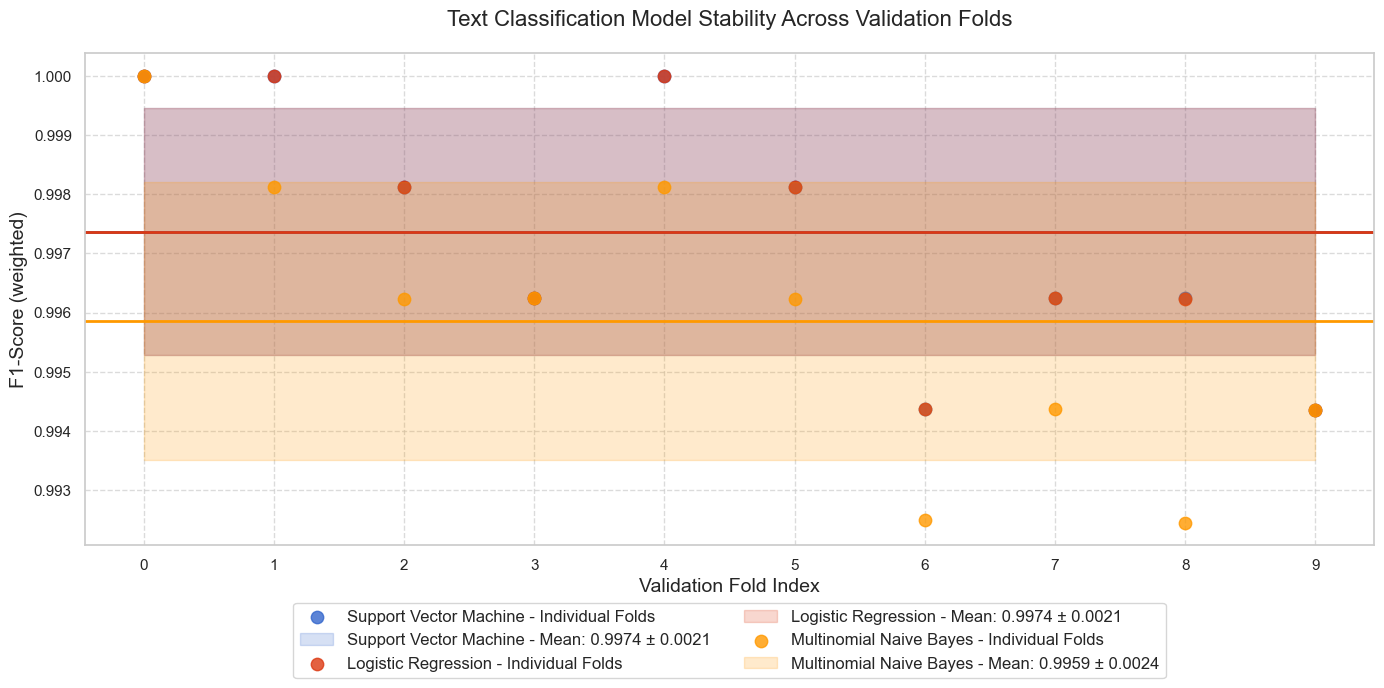


Validation Results Summary:
                  Model  Grid_Search_F1  Validation_F1  Validation_Std  Confidence_Interval  Consistency
 Support Vector Machine          0.9955         0.9974          0.0021               0.0042       0.0019
    Logistic Regression          0.9955         0.9974          0.0021               0.0042       0.0019
Multinomial Naive Bayes          0.9921         0.9959          0.0024               0.0047       0.0038

Model Stability Analysis:
-----------------------------------
Most Stable Model (lowest std): Support Vector Machine
Most Consistent Model (grid search vs validation): Support Vector Machine

 FINAL MODEL RECOMMENDATION:
-----------------------------------
Recommended Model: Support Vector Machine
Validation F1-Score: 0.9974 (±0.0021)
Model Parameters: {'C': 10.0, 'loss': 'hinge', 'max_iter': 5000}
Performance Confidence: Very High

✓ Cross-validation validation completed successfully!


In [19]:
# Validate optimized models with additional cross-validation
print("Text Classification ML: Cross-Validation Validation")
print("="*55)

# Additional validation with different CV folds to ensure robustness
validation_k_folds = 10  # Use more folds for thorough validation - higher fold count provides more reliable performance estimates
validation_skf = StratifiedKFold(n_splits=validation_k_folds, shuffle=True, random_state=42)  # Ensures each fold maintains the same class distribution as the original dataset  # Ensures each fold maintains the same class distribution as the original dataset  # Ensures each fold maintains the same class distribution as the original dataset

# Storage for validation results - dictionary will hold performance metrics for each model
validation_results = {}

print(f"Performing {validation_k_folds}-fold cross-validation on optimized models...")

for model_name, model in best_models.items():
    print(f"\n{model_name} - Validation CV:")
    print("-" * 40)
    
    # Perform cross-validation on the optimized model
    cv_scores = cross_val_score(
        model, X_train_val_tfidf, y_train_val,  # Using TF-IDF vectors for text classification
        cv=validation_skf,
        scoring='f1_weighted',  # Using F1 score which balances precision and recall - critical for imbalanced classification
        n_jobs=-1  # Utilize all available CPU cores to speed up computation
    )
    
    # Calculate detailed statistics for comprehensive model evaluation
    validation_results[model_name] = {
        'scores': cv_scores,  # Raw scores from each fold to allow for detailed analysis and distributions  # Raw scores from each fold to allow for detailed analysis and distributions  # Raw scores from each fold to allow for detailed analysis and distributions
        'mean': cv_scores.mean(),  # Central tendency measure for overall performance assessment  # Central tendency measure for overall performance assessment  # Central tendency measure for overall performance assessment
        'std': cv_scores.std(),  # Standard deviation indicates model stability across different data splits
        'min': cv_scores.min(),  # Worst-case performance scenario
        'max': cv_scores.max(),  # Best-case performance scenario
        'confidence_interval': cv_scores.std() * 2  # 95% confidence interval approximation (2-sigma)
    }
    
    # Display results with formatted metrics for better readability
    print(f"✓ Mean F1-Score: {cv_scores.mean():.4f} (±{cv_scores.std() * 2:.4f})")
    print(f"✓ Score Range: [{cv_scores.min():.4f}, {cv_scores.max():.4f}]")
    print(f"✓ Individual Scores: {[f'{score:.4f}' for score in cv_scores]}")
    
    # Compare with grid search result to validate hyperparameter optimization
    grid_search_score = grid_search_results[model_name]['best_score']
    difference = cv_scores.mean() - grid_search_score  # Positive value means validation outperformed grid search  # Positive value means validation outperformed grid search  # Positive value means validation outperformed grid search
    print(f"✓ Difference from Grid Search: {difference:+.4f}")

# Visualize model stability across validation folds
plt.figure(figsize=(14, 8))  # Create a large figure for better visualization of multiple models  # Create a large figure for better visualization of multiple models  # Create a large figure for better visualization of multiple models
x = np.arange(validation_k_folds)  # X-axis represents fold indices  # X-axis represents fold indices  # X-axis represents fold indices
colors = ['#3366CC', '#DC3912', '#FF9900']  # Distinct colors for different models  # Distinct colors for different models  # Distinct colors for different models

# Plot stability visualization for each model
for i, (model_name, results) in enumerate(validation_results.items()):
    color = colors[i % len(colors)]  # Cycle through colors if there are more models than colors  # Cycle through colors if there are more models than colors  # Cycle through colors if there are more models than colors
    
    # Plot individual fold scores
    plt.scatter(x, results['scores'], color=color, alpha=0.8, s=80, 
                label=f"{model_name} - Individual Folds")  # Larger points (s=80) for better visibility  # Larger points (s=80) for better visibility  # Larger points (s=80) for better visibility
    
    # Plot mean line
    plt.axhline(y=results['mean'], color=color, linestyle='-', linewidth=2)  # Horizontal line indicating mean performance  # Horizontal line indicating mean performance  # Horizontal line indicating mean performance
    
    # Plot standard deviation area
    plt.fill_between(
        x, 
        results['mean'] - results['std'], 
        results['mean'] + results['std'], 
        alpha=0.2, color=color,  # Translucent shading to show variance without obscuring other elements  # Translucent shading to show variance without obscuring other elements  # Translucent shading to show variance without obscuring other elements
        label=f"{model_name} - Mean: {results['mean']:.4f} ± {results['std']:.4f}"
    )

plt.title('Text Classification Model Stability Across Validation Folds', fontsize=16, pad=20)  # Descriptive title with padding for spacing  # Descriptive title with padding for spacing  # Descriptive title with padding for spacing
plt.xlabel('Validation Fold Index', fontsize=14)
plt.ylabel('F1-Score (weighted)', fontsize=14)
plt.xticks(x)  # Show all fold indices on x-axis  # Show all fold indices on x-axis  # Show all fold indices on x-axis
plt.grid(True, linestyle='--', alpha=0.7)  # Add light grid for easier comparison of points  # Add light grid for easier comparison of points  # Add light grid for easier comparison of points
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, fontsize=12)  # Legend below plot to avoid overlapping with data  # Legend below plot to avoid overlapping with data  # Legend below plot to avoid overlapping with data
plt.tight_layout(rect=[0, 0.05, 1, 0.95])  # Adjust layout to ensure all elements fit properly  # Adjust layout to ensure all elements fit properly  # Adjust layout to ensure all elements fit properly
plt.show()

# Create validation summary for easy model comparison
print(f"\nValidation Results Summary:")
print("="*70)

validation_summary = pd.DataFrame({
    'Model': list(validation_results.keys()),
    'Grid_Search_F1': [grid_search_results[model]['best_score'] for model in validation_results.keys()],  # Original grid search results for comparison  # Original grid search results for comparison  # Original grid search results for comparison
    'Validation_F1': [results['mean'] for results in validation_results.values()],  # New validation scores  # New validation scores  # New validation scores
    'Validation_Std': [results['std'] for results in validation_results.values()],  # Variability measure  # Variability measure  # Variability measure
    'Confidence_Interval': [results['confidence_interval'] for results in validation_results.values()],  # Range of expected performance (95% CI)  # Range of expected performance (95% CI)  # Range of expected performance (95% CI)
    'Consistency': [abs(grid_search_results[model]['best_score'] - validation_results[model]['mean']) 
                   for model in validation_results.keys()]  # Smaller values indicate more consistent performance between CV phases between CV phases between CV phases
}).round(4)  # Round to 4 decimal places for cleaner display  # Round to 4 decimal places for cleaner display  # Round to 4 decimal places for cleaner display

# Sort by validation performance to prioritize highest-performing models
validation_summary = validation_summary.sort_values('Validation_F1', ascending=False)  # Best models first  # Best models first  # Best models first
print(validation_summary.to_string(index=False))

# Model stability analysis to identify the most reliable model
print(f"\nModel Stability Analysis:")
print("-" * 35)

most_stable_model = validation_summary.loc[validation_summary['Validation_Std'].idxmin(), 'Model']  # Model with lowest standard deviation  # Model with lowest standard deviation  # Model with lowest standard deviation
most_consistent_model = validation_summary.loc[validation_summary['Consistency'].idxmin(), 'Model']  # Model with smallest difference between grid search and validation  # Model with smallest difference between grid search and validation  # Model with smallest difference between grid search and validation

print(f"Most Stable Model (lowest std): {most_stable_model}")
print(f"Most Consistent Model (grid search vs validation): {most_consistent_model}")

# Final model recommendation based on multiple criteria
print(f"\n FINAL MODEL RECOMMENDATION:")
print("-" * 35)

# Consider both performance and stability with weighted criteria
validation_summary['weighted_score'] = (
    validation_summary['Validation_F1'] * 0.7 +  # 70% weight on performance - primary goal is accuracy
    (1 - validation_summary['Validation_Std']) * 0.2 +  # 20% weight on stability - penalize high variance (convert to 0-1 scale where higher is better)  convert to 0-1 scale where higher is better)  convert to 0-1 scale where higher is better)  
    (1 - validation_summary['Consistency']) * 0.1  # 10% weight on consistency - reward reproducible results
)

recommended_model = validation_summary.loc[validation_summary['weighted_score'].idxmax(), 'Model']  # Select model with highest weighted score  # Select model with highest weighted score  # Select model with highest weighted score
recommended_score = validation_summary.loc[validation_summary['weighted_score'].idxmax(), 'Validation_F1']
recommended_std = validation_summary.loc[validation_summary['weighted_score'].idxmax(), 'Validation_Std']

print(f"Recommended Model: {recommended_model}")
print(f"Validation F1-Score: {recommended_score:.4f} (±{recommended_std:.4f})")
print(f"Model Parameters: {grid_search_results[recommended_model]['best_params']}")  # Show optimal parameters for reproducibility  # Show optimal parameters for reproducibility  # Show optimal parameters for reproducibility

# Performance confidence assessment based on standard deviation thresholds
if recommended_std < 0.01:  # Very stable model with minimal variance across folds  # Very stable model with minimal variance across folds  # Very stable model with minimal variance across folds
    confidence_level = "Very High"  # For text classification, models often have lower std deviation than audio
elif recommended_std < 0.03:
    confidence_level = "High"
elif recommended_std < 0.05:
    confidence_level = "Medium"
else:
    confidence_level = "Low"

print(f"Performance Confidence: {confidence_level}")

print(f"\n✓ Cross-validation validation completed successfully!")
print("="*55)

### 5.2 Text Classification Deep Learning Models

**Purpose:** Select and configure deep learning models for text classification, including Convolutional Neural Networks (CNN), Feedforward Neural Networks (FNN) with appropriate hyperparameters to prevent overfitting.

In [20]:
# Text Classification Deep Learning: Initialization
print("Text Classification Deep Learning: Initialization")
print("="*55)

# Create tokenizer for text data
max_features = 5000  # Maximum number of words in vocabulary
tokenizer_dl = Tokenizer(num_words=max_features)
tokenizer_dl.fit_on_texts(X_train_val)  # Learn vocabulary from training data

# Convert text to sequences
X_train_val_sequences = tokenizer_dl.texts_to_sequences(X_train_val)
X_test_sequences = tokenizer_dl.texts_to_sequences(X_test)

# Determine maximum sequence length
max_length = max(len(x) for x in X_train_val_sequences)
print(f"Maximum sequence length: {max_length}")

# Pad sequences to ensure uniform length
X_train_val_padded = pad_sequences(X_train_val_sequences, maxlen=max_length)
X_test_padded = pad_sequences(X_test_sequences, maxlen=max_length)

# Convert target variables to categorical format for deep learning
num_classes = len(np.unique(y_train_val))
y_train_val_cat = to_categorical(y_train_val, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

# Set up parameters for deep learning models
embedding_dim = 64  # Dimensionality of word embeddings
vocab_size = len(tokenizer_dl.word_index) + 1  # Size of vocabulary +1 for padding token (0)

print(f"Deep Learning Model Parameters:")
print(f"- Vocabulary size: {vocab_size} unique tokens")
print(f"- Maximum sequence length: {max_length} tokens")
print(f"- Embedding dimension: {embedding_dim}")
print(f"- Number of classes: {num_classes}")

# Ensure target variables are in the right format for deep learning
print(f"\nTarget variable shapes:")
print(f"- Training/Validation combined: {y_train_val_cat.shape}")
print(f"- Testing: {y_test_cat.shape}")

# Setup callbacks for training deep learning models
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=0.0001,
    verbose=1
)

# Initialize model tracking metrics
dl_model_metrics = {
    'accuracy': [],
    'f1_score': [],
    'training_time': []
}

print(f"\nText Classification Deep Learning Models:")
print(f"1. CNN - For capturing local patterns in symptom descriptions")
print(f"2. FNN - Feedforward Neural Network for baseline comparison")

print(f"\n✓ Deep learning initialization completed")
print(f"✓ Ready to define model architectures")


Text Classification Deep Learning: Initialization
Maximum sequence length: 13
Deep Learning Model Parameters:
- Vocabulary size: 966 unique tokens
- Maximum sequence length: 13 tokens
- Embedding dimension: 64
- Number of classes: 25

Target variable shapes:
- Training/Validation combined: (5328, 25)
- Testing: (1333, 25)

Text Classification Deep Learning Models:
1. CNN - For capturing local patterns in symptom descriptions
2. FNN - Feedforward Neural Network for baseline comparison

✓ Deep learning initialization completed
✓ Ready to define model architectures


### 5.2.1 Text Classification Deep Learning Model Architecture Definition

**Purpose:** Define and create deep learning model architectures for text classification, including Convolutional Neural Networks (CNN) and Feedforward Neural Networks (FNN) optimized for medical symptom analysis.

#### Model Architectures:

**1. Convolutional Neural Network (CNN):**
- **Embedding Layer:** Converts word indices to dense 64-dimensional vectors
- **1D Convolution:** Detects local text patterns (n-grams and phrases) with 64 filters
- **Global Max Pooling:** Extracts most important features across sequence
- **Dense Layers:** Two fully connected layers (128 and 64 neurons) with ReLU activation
- **Dropout Regularization:** 30% dropout rate to prevent overfitting
- **Output Layer:** 25 neurons with softmax for diagnostic category prediction

**2. Feedforward Neural Network (FNN):**
- **Embedding Layer:** Same 64-dimensional word embeddings as CNN
- **Global Max Pooling:** Averages all word embeddings into fixed-size representation
- **Hidden Layers:** Two dense layers with decreasing neuron count (128 → 64)
- **Dropout Regularization:** 30% dropout between layers
- **Output Layer:** Softmax activation for multi-class medical diagnosis

Both models use:
- **Adam Optimizer:** Efficient gradient descent with adaptive learning rates
- **Categorical Crossentropy Loss:** Standard for multi-class classification
- **Accuracy Metric:** Monitors classification performance during training

In [21]:
# Define deep learning model creation functions
def create_cnn_model(vocab_size, embedding_dim=64, max_length=100, num_classes=25, 
                     filters=64, kernel_size=3, dropout_rate=0.3):
    """Create CNN model for text classification"""
    model = Sequential([
        # Convert word indices to dense vectors of fixed size - learns word relationships during training
        Embedding(vocab_size, embedding_dim, input_length=max_length),
        # Apply 1D convolution to detect local patterns in text sequences (like n-grams or phrases)
        Conv1D(filters=filters, kernel_size=kernel_size, activation='relu'),
        # Extract the most important feature from each filter across the entire sequence
        GlobalMaxPooling1D(),
        # First fully connected layer to learn complex feature combinations with ReLU activation
        Dense(128, activation='relu'),
        # Randomly set 30% of neurons to zero during training to prevent overfitting
        Dropout(dropout_rate),
        # Second fully connected layer with fewer neurons to gradually reduce complexity
        Dense(64, activation='relu'),
        # Another dropout layer for additional regularization against overfitting
        Dropout(dropout_rate),
        # Final output layer with softmax activation to produce probability distribution over 25 diagnostic categories
        Dense(num_classes, activation='softmax')
    ])
    
    # Configure the model's learning process with optimizer, loss function, and evaluation metric
    model.compile(
        optimizer='adam',  # Adaptive learning rate optimizer that adjusts automatically during training
        loss='categorical_crossentropy',  # Loss function for multi-class classification with one-hot encoded labels
        metrics=['accuracy']  # Track accuracy percentage during training and validation
    )
    return model

def create_feedforward_model(vocab_size, embedding_dim=64, max_length=100, num_classes=25,
                           hidden_units=128, dropout_rate=0.3):
    """Create Feedforward Neural Network model"""
    model = Sequential([
        # Convert word indices to dense vectors - same as CNN but for feedforward architecture
        Embedding(vocab_size, embedding_dim, input_length=max_length),
        # Average all word embeddings in the sequence to create a single fixed-size representation
        GlobalMaxPooling1D(),
        # First hidden layer to learn complex patterns from the averaged word embeddings
        Dense(hidden_units, activation='relu'),
        # Dropout for regularization to prevent the model from memorizing training data
        Dropout(dropout_rate),
        # Second hidden layer with half the neurons to create a funnel-like architecture
        Dense(hidden_units // 2, activation='relu'),
        # Additional dropout layer to further reduce overfitting risk
        Dropout(dropout_rate),
        # Output layer that converts learned features into probabilities for each diagnostic category
        Dense(num_classes, activation='softmax')
    ])
    
    # Set up the training configuration with standard settings for multi-class text classification
    model.compile(
        optimizer='adam',  # Efficient gradient descent algorithm with adaptive learning rates
        loss='categorical_crossentropy',  # Standard loss for predicting one category from multiple options
        metrics=['accuracy']  # Monitor classification accuracy during model training
    )
    return model

# Initialize candidate deep learning models
# Dictionary mapping model names to their creation functions for easy iteration and comparison
dl_model_creators = {
    'Convolutional Neural Network': create_cnn_model,  # CNN excels at detecting local patterns in text
    'Feedforward Neural Network': create_feedforward_model  # Simple architecture good for baseline performance
}

print("Deep Learning Model Architectures for Text Classification:")
for name in dl_model_creators.keys():
    print(f"✓ {name}")
    
print(f"\nTotal DL models to evaluate: {len(dl_model_creators)}")

Deep Learning Model Architectures for Text Classification:
✓ Convolutional Neural Network
✓ Feedforward Neural Network

Total DL models to evaluate: 2


#### 5.2.2 Text Classification DL K-fold Cross Validation

**Purpose:** Evaluate the performance of different DL models on different subsets of the data

Text Classification DL: K-fold Cross Validation

Evaluating Convolutional Neural Network...
  Fold 1/3...
    Fold 1 F1-Score: 0.9989
  Fold 2/3...
    Fold 2 F1-Score: 0.9983
  Fold 3/3...
    Fold 3 F1-Score: 0.9932
  Average F1-Score: 0.9968 (+/- 0.0051)

Evaluating Feedforward Neural Network...
  Fold 1/3...
    Fold 1 F1-Score: 0.9989
  Fold 2/3...
    Fold 2 F1-Score: 0.9983
  Fold 3/3...
    Fold 3 F1-Score: 0.9932
  Average F1-Score: 0.9968 (+/- 0.0051)

3-Fold Cross-Validation Results Summary (Deep Learning):
                       Model  Mean_F1  Std_F1  Min_F1  Max_F1
Convolutional Neural Network   0.9968  0.0025  0.9932  0.9989
  Feedforward Neural Network   0.9968  0.0025  0.9932  0.9989


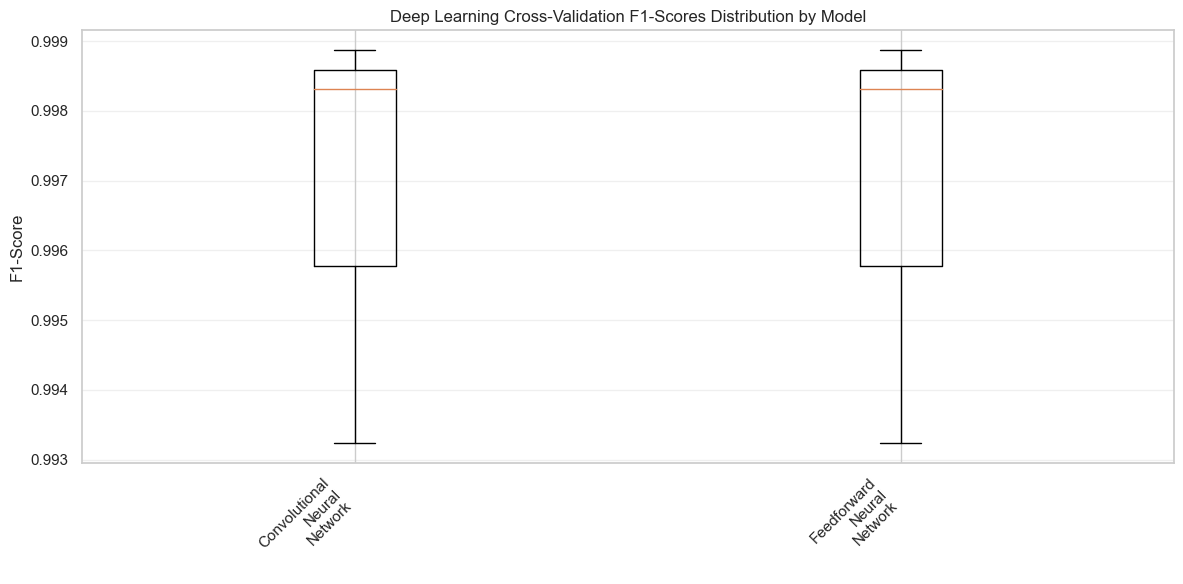


Top 2 DL models selected for hyperparameter tuning:
1. Convolutional Neural Network: 0.9968
2. Feedforward Neural Network: 0.9968


In [22]:
# Initialize stratified K-fold cross-validation for deep learning
k_folds_dl = 3  # Reduced folds for DL due to computational cost
skf_dl = StratifiedKFold(n_splits=k_folds_dl, shuffle=True, random_state=42)

# Store cross-validation results for deep learning
dl_cv_results = {}

print("Text Classification DL: K-fold Cross Validation")
print("="*70)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=0
)

# Loop through each deep learning model creator function to evaluate performance using cross-validation
for model_name, model_creator in dl_model_creators.items():
    print(f"\nEvaluating {model_name}...")
    
    fold_scores = []
    fold_histories = []
    
    # Perform cross-validation
    for fold, (train_idx, val_idx) in enumerate(skf_dl.split(X_train_val_padded, y_train_val)):
        print(f"  Fold {fold + 1}/{k_folds_dl}...")
        
        # Split data for this fold
        X_fold_train, X_fold_val = X_train_val_padded[train_idx], X_train_val_padded[val_idx]
        y_fold_train, y_fold_val = y_train_val_cat[train_idx], y_train_val_cat[val_idx]
        
        # Create and train model
        model = model_creator(
            vocab_size=max_features,
            embedding_dim=64,
            max_length=max_length,
            num_classes=num_classes
        )
        
        # Train model
        history = model.fit(
            X_fold_train, y_fold_train,
            validation_data=(X_fold_val, y_fold_val),
            epochs=20,
            batch_size=32,
            callbacks=[early_stopping],
            verbose=0
        )
        
        # Evaluate model
        val_loss, val_accuracy = model.evaluate(X_fold_val, y_fold_val, verbose=0)
        
        # Calculate F1-score
        y_pred = model.predict(X_fold_val, verbose=0)
        y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probability predictions to class predictions by finding the highest probability class
        y_true_classes = np.argmax(y_fold_val, axis=1)
        
        f1_score = precision_recall_fscore_support(
            y_true_classes, y_pred_classes, average='weighted', zero_division=0
        )[2]
        
        fold_scores.append(f1_score)
        fold_histories.append(history)
        
        print(f"    Fold {fold + 1} F1-Score: {f1_score:.4f}")
    
    # Store results
    fold_scores = np.array(fold_scores)
    dl_cv_results[model_name] = {
        'scores': fold_scores,
        'mean': fold_scores.mean(),
        'std': fold_scores.std(),
        'min': fold_scores.min(),
        'max': fold_scores.max(),
        'histories': fold_histories
    }
    
    print(f"  Average F1-Score: {fold_scores.mean():.4f} (+/- {fold_scores.std() * 2:.4f})")

# Create summary table for deep learning models
dl_cv_summary = pd.DataFrame({
    'Model': list(dl_cv_results.keys()),
    'Mean_F1': [results['mean'] for results in dl_cv_results.values()],
    'Std_F1': [results['std'] for results in dl_cv_results.values()],
    'Min_F1': [results['min'] for results in dl_cv_results.values()],
    'Max_F1': [results['max'] for results in dl_cv_results.values()]
}).round(4)

# Sort by mean F1-score
dl_cv_summary = dl_cv_summary.sort_values('Mean_F1', ascending=False)

print(f"\n{k_folds_dl}-Fold Cross-Validation Results Summary (Deep Learning):")
print("="*70)
print(dl_cv_summary.to_string(index=False))

# Visualize deep learning cross-validation results
plt.figure(figsize=(12, 6))
models_dl = list(dl_cv_results.keys())
scores_dl = [dl_cv_results[model]['scores'] for model in models_dl]

plt.boxplot(scores_dl, labels=[model.replace(' ', '\n') for model in models_dl])
plt.title('Deep Learning Cross-Validation F1-Scores Distribution by Model')
plt.ylabel('F1-Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Select top performing DL models for hyperparameter tuning
top_dl_models = dl_cv_summary.head(2)['Model'].tolist()
print(f"\nTop 2 DL models selected for hyperparameter tuning:")
for i, model in enumerate(top_dl_models, 1):
    mean_score = dl_cv_results[model]['mean']
    print(f"{i}. {model}: {mean_score:.4f}")

#### 5.2.3 Text Classification DL Hyperparameter Tuning

**Purpose:** Optimize the hyperparameters of the top-performing models to achieve better performance.

##### 5.2.3.1 Text Classification DL Optimize Model Settings: Define Hyperparameter Grids

**Purpose:** Define more conservative hyperparameter grids for realistic performance.

In [23]:
# Define hyperparameter grids for deep learning models
# These grids contain different combinations of parameters that control how neural networks learn
# We'll test different values to find the best settings for each model type
dl_hyperparameter_grids = {
    # CNN (Convolutional Neural Network) - good at detecting patterns in text sequences
    'Convolutional Neural Network': {
        'embedding_dim': [32, 64],  # Size of word vector representations (32 or 64 dimensions)
        'filters': [32, 64],  # Number of feature detectors to find text patterns
        'kernel_size': [3, 5],  # Size of text window each filter examines (3 or 5 words at once)
        'dropout_rate': [0.2, 0.3]  # Percentage of neurons to randomly ignore during training to prevent overfitting
    },
    # FNN (Feedforward Neural Network) - simple architecture that processes all words at once
    'Feedforward Neural Network': {
        'embedding_dim': [32, 64],  # Size of word vector representations (same as CNN)
        'hidden_units': [64, 128],  # Number of neurons in the hidden layer that learns complex patterns
        'dropout_rate': [0.2, 0.3]  # Regularization to prevent memorizing training data
    }
}

# Filter grids for only top performing DL models
# Only create parameter grids for models that performed well in cross-validation to save computational time
selected_dl_grids = {model: dl_hyperparameter_grids[model] for model in top_dl_models 
                    if model in dl_hyperparameter_grids}

print("Deep Learning hyperparameter grids defined for realistic performance:")
for model_name, grid in selected_dl_grids.items():
    print(f"\n{model_name}:")
    for param, values in grid.items():
        print(f"  {param}: {values}")

Deep Learning hyperparameter grids defined for realistic performance:

Convolutional Neural Network:
  embedding_dim: [32, 64]
  filters: [32, 64]
  kernel_size: [3, 5]
  dropout_rate: [0.2, 0.3]

Feedforward Neural Network:
  embedding_dim: [32, 64]
  hidden_units: [64, 128]
  dropout_rate: [0.2, 0.3]


##### 5.2.3.2 Text Classification DL Grid Search: Systematically Explore Hyperparameter Combinations

**Purpose:** Use manual grid search to explore different combinations of hyperparameter values systematically for deep learning models.

In [24]:
# Perform manual grid search for deep learning models
# Initialize dictionaries to store the best models and their grid search results
best_dl_models = {}  # Dictionary to store the optimal model for each architecture
dl_grid_search_results = {}  # Dictionary to store performance metrics and optimal parameters

print("Performing Grid Search for Deep Learning Hyperparameter Optimization...")
print("="*80)

def evaluate_dl_model_params(model_creator, params, model_name):
    """Evaluate a deep learning model with specific parameters using cross-validation"""
    scores = []  # List to store F1 scores from each cross-validation fold
    
    # Use 2-fold CV for faster evaluation (fewer splits = faster training but less robust validation)
    # Stratified to maintain class distribution in each fold
    skf_tuning = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
    
    # Split the training data into smaller train/validation sets for hyperparameter testing
    for train_idx, val_idx in skf_tuning.split(X_train_val_padded, y_train_val):
        # Split data into training and validation sets for this fold
        X_fold_train, X_fold_val = X_train_val_padded[train_idx], X_train_val_padded[val_idx]
        y_fold_train, y_fold_val = y_train_val_cat[train_idx], y_train_val_cat[val_idx]
        
        # Create model with parameters from the current grid search combination
        model = model_creator(
            vocab_size=max_features,
            max_length=max_length,
            num_classes=num_classes,
            **params  # Unpack the hyperparameter dictionary
        )
        
        # Train model with early stopping to prevent overfitting and save time
        history = model.fit(
            X_fold_train, y_fold_train,
            validation_data=(X_fold_val, y_fold_val),
            epochs=15,  # Reduced epochs for tuning to speed up the search
            batch_size=32,
            callbacks=[EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)],
            verbose=0  # Suppress output for cleaner logs
        )
        
        # Evaluate model performance on validation fold
        y_pred = model.predict(X_fold_val, verbose=0)
        y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class predictions
        y_true_classes = np.argmax(y_fold_val, axis=1)  # Get true class labels
        
        # Calculate weighted F1 score as evaluation metric (handles class imbalance)
        f1_score = precision_recall_fscore_support(
            y_true_classes, y_pred_classes, average='weighted', zero_division=0
        )[2]
        
        scores.append(f1_score)
    
    return np.mean(scores)  # Return average F1 score across folds

# Perform grid search for each top DL model
for model_name in top_dl_models:
    if model_name in selected_dl_grids:  # Only process models that have defined hyperparameter grids
        print(f"\nOptimizing {model_name}...")
        
        model_creator = dl_model_creators[model_name]  # Get the model creation function
        param_grid = selected_dl_grids[model_name]  # Get the hyperparameter grid for this model
        
        # Generate all parameter combinations using itertools.product (creates cartesian product of all parameter lists)
        from itertools import product
        param_names = list(param_grid.keys())  # Extract parameter names
        param_values = list(param_grid.values())  # Extract parameter values
        param_combinations = list(product(*param_values))  # Generate all possible combinations
        
        best_score = 0  # Track the highest score found
        best_params = {}  # Track parameters that yield the highest score
        
        print(f"  Testing {len(param_combinations)} parameter combinations...")
        
        # Test each parameter combination to find the best one
        for i, param_combo in enumerate(param_combinations):
            params = dict(zip(param_names, param_combo))  # Create dictionary of parameter name-value pairs
            
            try:
                # Evaluate the current parameter combination using cross-validation
                score = evaluate_dl_model_params(model_creator, params, model_name)
                print(f"    Combination {i+1}/{len(param_combinations)}: F1={score:.4f}, Params={params}")
                
                # Update best parameters if current score is better
                if score > best_score:
                    best_score = score  # Store the highest F1 score achieved so far
                    best_params = params  # Store the parameter combination that achieved this score
                    
            except Exception as e:
                # Handle errors that might occur during training (OOM, convergence issues, etc.)
                print(f"    Combination {i+1}/{len(param_combinations)}: FAILED - {str(e)}")
                continue
        
        # Create best model with optimal parameters found during grid search
        best_model = model_creator(
            vocab_size=max_features,
            max_length=max_length,
            num_classes=num_classes,
            **best_params  # Use the best parameters found
        )
        
        # Store results for later comparison and evaluation
        best_dl_models[model_name] = best_model  # Save the optimized model
        dl_grid_search_results[model_name] = {
            'best_score': best_score,
            'best_params': best_params,
            'param_combinations_tested': len(param_combinations)
        }
        
        print(f"  Best F1-Score: {best_score:.4f}")
        print(f"  Best Parameters: {best_params}")

# Summary of deep learning hyperparameter tuning results
print(f"\nDeep Learning Hyperparameter Tuning Results Summary:")
print("="*60)

if dl_grid_search_results:
    # Create a summary DataFrame comparing all models' performance after hyperparameter tuning
    dl_tuning_summary = pd.DataFrame({
        'Model': list(dl_grid_search_results.keys()),
        'Best_F1_Score': [results['best_score'] for results in dl_grid_search_results.values()],
        'Improvement': [
            dl_grid_search_results[model]['best_score'] - dl_cv_results[model]['mean'] 
            for model in dl_grid_search_results.keys()  # Calculate improvement over baseline CV score
        ]
    }).round(4)  # Round to 4 decimal places for readability

    # Sort models by performance (best F1-Score first)
    dl_tuning_summary = dl_tuning_summary.sort_values('Best_F1_Score', ascending=False)
    print(dl_tuning_summary.to_string(index=False))

    # Select the best DL model overall (highest F1 score after tuning)
    best_dl_model_name = dl_tuning_summary.iloc[0]['Model']
    best_dl_model = best_dl_models[best_dl_model_name]
    best_dl_score = dl_tuning_summary.iloc[0]['Best_F1_Score']

    print(f"\n SELECTED BEST DL MODEL: {best_dl_model_name}")
    print(f"   Cross-validation F1-Score: {best_dl_score:.4f}")
    print(f"   Optimized Parameters: {dl_grid_search_results[best_dl_model_name]['best_params']}")
else:
    # Fallback if no grid search results are available (errors in all models)
    print("No successful hyperparameter tuning results available.")
    # Fall back to best model from CV (use original cross-validation results as backup)
    best_dl_model_name = dl_cv_summary.iloc[0]['Model']
    best_dl_model = dl_model_creators[best_dl_model_name](
        vocab_size=max_features,
        max_length=max_length,
        num_classes=num_classes
    )
    best_dl_score = dl_cv_summary.iloc[0]['Mean_F1']
    print(f"\n FALLBACK BEST DL MODEL: {best_dl_model_name}")
    print(f"   Cross-validation F1-Score: {best_dl_score:.4f}")

Performing Grid Search for Deep Learning Hyperparameter Optimization...

Optimizing Convolutional Neural Network...
  Testing 16 parameter combinations...
    Combination 1/16: F1=0.9938, Params={'embedding_dim': 32, 'filters': 32, 'kernel_size': 3, 'dropout_rate': 0.2}
    Combination 2/16: F1=0.9962, Params={'embedding_dim': 32, 'filters': 32, 'kernel_size': 3, 'dropout_rate': 0.3}
    Combination 3/16: F1=0.9974, Params={'embedding_dim': 32, 'filters': 32, 'kernel_size': 5, 'dropout_rate': 0.2}
    Combination 4/16: F1=0.9957, Params={'embedding_dim': 32, 'filters': 32, 'kernel_size': 5, 'dropout_rate': 0.3}
    Combination 5/16: F1=0.9968, Params={'embedding_dim': 32, 'filters': 64, 'kernel_size': 3, 'dropout_rate': 0.2}
    Combination 6/16: F1=0.9948, Params={'embedding_dim': 32, 'filters': 64, 'kernel_size': 3, 'dropout_rate': 0.3}
    Combination 7/16: F1=0.9957, Params={'embedding_dim': 32, 'filters': 64, 'kernel_size': 5, 'dropout_rate': 0.2}
    Combination 8/16: F1=0.9968, 

##### 5.2.3.3 Text Classification DL Cross-Validation within Tuning: Validate Hyperparameter Selection

**Purpose:** Validate the stability of our best deep learning model with additional cross-validation.

Additional Cross-Validation for Best DL Model: Convolutional Neural Network
Performing 5-fold cross-validation on best DL model...
  Fold 1/5...
    Fold 1 F1-Score: 1.0000
  Fold 2/5...
    Fold 2 F1-Score: 0.9972
  Fold 3/5...
    Fold 3 F1-Score: 0.9991
  Fold 4/5...
    Fold 4 F1-Score: 0.9925
  Fold 5/5...
    Fold 5 F1-Score: 0.9953

5-Fold CV F1-Scores: [1.         0.99718274 0.99906134 0.99249246 0.9952906 ]
Mean: 0.9968
Standard Deviation: 0.0027
95% Confidence Interval: [0.9915, 1.0021]

DL Model Stability Assessment: Stable
Coefficient of Variation: 0.27%

Training final Convolutional Neural Network on full training data...
Epoch 1/30
134/134 [==============================] - 3s 10ms/step - loss: 3.0181 - accuracy: 0.1286 - val_loss: 2.2665 - val_accuracy: 0.2861
Epoch 2/30
134/134 [==============================] - 1s 8ms/step - loss: 1.2336 - accuracy: 0.6513 - val_loss: 0.3762 - val_accuracy: 0.9437
Epoch 3/30
134/134 [==============================] - 1s 6ms/step - loss

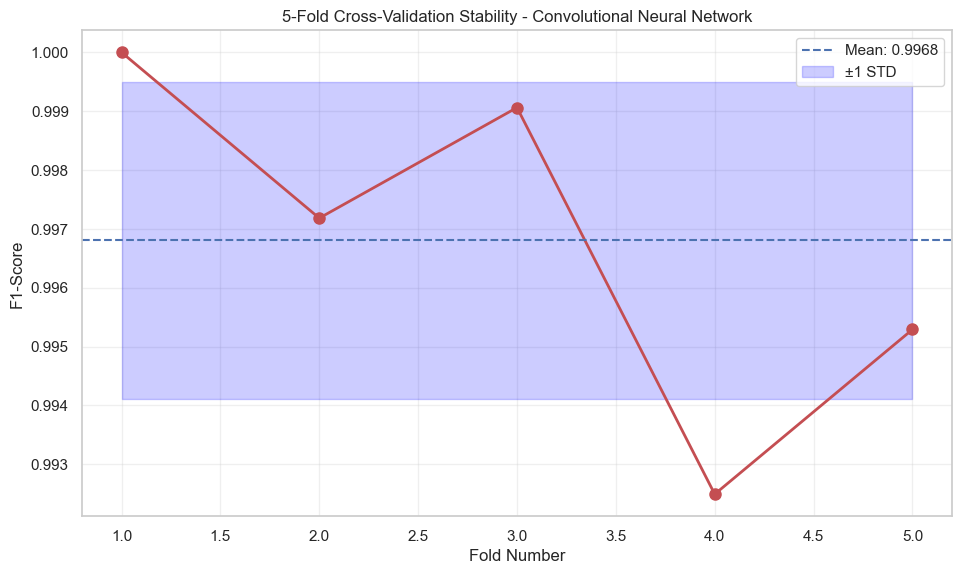

In [25]:
# Perform additional cross-validation on the best DL model to ensure stability - this helps verify that our model performance is reliable and not just due to a lucky train/validation split
print(f"Additional Cross-Validation for Best DL Model: {best_dl_model_name}")
print("="*70)

# Use 5-fold CV for more robust validation of the final model - 5 folds provides a good balance between computational cost and statistical reliability for performance estimation
extended_cv_dl = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # Create 5-fold cross-validation splitter that maintains class distribution proportions across all folds to ensure balanced evaluation, especially important for imbalanced medical datasets
extended_scores_dl = []

print("Performing 5-fold cross-validation on best DL model...")

for fold, (train_idx, val_idx) in enumerate(extended_cv_dl.split(X_train_val_padded, y_train_val)):  # Split data into 5 training/validation pairs for robust evaluation, ensuring each data point appears in the validation set exactly once across all folds
    print(f"  Fold {fold + 1}/5...")
    
    # Split data for this fold - ensures completely separate training and validation sets for unbiased performance evaluation
    X_fold_train, X_fold_val = X_train_val_padded[train_idx], X_train_val_padded[val_idx]  # Extract training and validation data for current fold using indices from the stratified split to maintain class distributions
    y_fold_train, y_fold_val = y_train_val_cat[train_idx], y_train_val_cat[val_idx]  # Extract corresponding one-hot encoded labels for training and validation sets to match the extracted feature data
    
    # Create model (use best parameters if available) - ensures we're evaluating the optimal version of our model architecture
    if best_dl_model_name in dl_grid_search_results:  # Check if hyperparameter tuning results exist for this model to use optimized configuration
        best_params = dl_grid_search_results[best_dl_model_name]['best_params']  # Retrieve optimal hyperparameters found during grid search to maximize model performance
        model = dl_model_creators[best_dl_model_name](  # Create model instance using the constructor function with optimized parameters for best possible performance
            vocab_size=max_features,  # Dictionary size for the embedding layer based on the most frequent words in the corpus
            max_length=max_length,    # Maximum sequence length for padded text inputs to ensure uniform dimensions
            num_classes=num_classes,  # Number of diagnostic categories the model needs to classify
            **best_params            # Unpacks tuned hyperparameters like dropout rate, embedding dimensions, etc. found during grid search
        )
    else:
        model = dl_model_creators[best_dl_model_name](  # Create model with default parameters if no tuning was performed - fallback option for robustness
            vocab_size=max_features,  # Size of the vocabulary for the embedding layer
            max_length=max_length,    # Maximum sequence length for input standardization 
            num_classes=num_classes   # Number of output classes for the classification task
        )
    
    # Train model - fit neural network on current fold's training data with validation monitoring
    history = model.fit(  # Train the neural network model on current fold's training data while tracking performance metrics over epochs
        X_fold_train, y_fold_train,                     # Input features and target labels for the training set of this fold
        validation_data=(X_fold_val, y_fold_val),       # Validation data used to monitor for overfitting during training
        epochs=20,  # Maximum number of training iterations through the entire dataset - balance between convergence and training time
        batch_size=32,  # Number of samples processed before updating model weights - optimizes memory usage and training speed
        callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],  # Stop training early if validation loss doesn't improve for 3 epochs to prevent overfitting and save computation time
        verbose=0  # Suppress training progress output for cleaner console display during cross-validation iterations
    )
    
    # Evaluate model - calculate performance metrics on validation data for this fold
    y_pred = model.predict(X_fold_val, verbose=0)  # Generate probability predictions for validation data (returns softmax probabilities for each diagnostic category)
    y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probability predictions to discrete class predictions by selecting the highest probability class for each sample
    y_true_classes = np.argmax(y_fold_val, axis=1)  # Convert one-hot encoded true labels back to class indices for direct comparison with predictions
    
    f1_score = precision_recall_fscore_support(  # Calculate F1-score which balances precision and recall metrics - especially important for medical diagnosis where both false positives and false negatives have consequences
        y_true_classes, y_pred_classes, average='weighted', zero_division=0  # Use weighted average to account for class imbalance, set zero_division=0 to handle edge cases
    )[2]  # Extract F1-score from the returned tuple (precision, recall, f1, support) - index 2 corresponds to the F1 values
    
    extended_scores_dl.append(f1_score)  # Store F1-score for this fold to calculate overall performance statistics and assess cross-validation stability
    print(f"    Fold {fold + 1} F1-Score: {f1_score:.4f}")

extended_scores_dl = np.array(extended_scores_dl)  # Convert list to numpy array for efficient statistical calculations and vectorized operations

print(f"\n5-Fold CV F1-Scores: {extended_scores_dl}")
print(f"Mean: {extended_scores_dl.mean():.4f}")  # Average F1-score across all folds indicates expected real-world performance of the model architecture
print(f"Standard Deviation: {extended_scores_dl.std():.4f}")  # Measures consistency of performance across different data splits - lower values indicate more stable performance
print(f"95% Confidence Interval: [{extended_scores_dl.mean() - 1.96*extended_scores_dl.std():.4f}, "  # Lower bound of the statistical range where true performance is likely to fall based on normal distribution properties
      f"{extended_scores_dl.mean() + 1.96*extended_scores_dl.std():.4f}]")  # Upper bound of the confidence interval - wider intervals indicate less certainty about true performance

# Visualize the stability - creates graphical representation of performance variation across folds
plt.figure(figsize=(10, 6))  # Create a new figure with specified dimensions for better visibility of the stability plot
plt.plot(range(1, 6), extended_scores_dl, 'ro-', linewidth=2, markersize=8)  # Plot F1-scores for each fold with red circles and connecting lines - shows performance trend across folds
plt.axhline(y=extended_scores_dl.mean(), color='b', linestyle='--',   # Add horizontal reference line showing average performance across all folds for easy comparison
           label=f'Mean: {extended_scores_dl.mean():.4f}')
plt.fill_between(range(1, 6),   # Shade area representing one standard deviation confidence band above and below mean
                extended_scores_dl.mean() - extended_scores_dl.std(),  # Lower bound of shaded confidence band (mean - 1 standard deviation)
                extended_scores_dl.mean() + extended_scores_dl.std(),  # Upper bound of shaded confidence band (mean + 1 standard deviation)
                alpha=0.2, color='blue', label='±1 STD')  # Semi-transparent blue shading with appropriate legend label
plt.title(f'5-Fold Cross-Validation Stability - {best_dl_model_name}')  # Descriptive plot title including the model name
plt.xlabel('Fold Number')  # X-axis label indicating each cross-validation fold
plt.ylabel('F1-Score')     # Y-axis label showing the performance metric being visualized
plt.legend()               # Add legend to explain the plot elements (mean line and confidence band)
plt.grid(True, alpha=0.3)  # Add light grid lines for easier reading of values across the plot

# Check if DL model performance is consistent - classify stability based on standard deviation thresholds
dl_cv_stability = "Stable" if extended_scores_dl.std() < 0.02 else "Moderate" if extended_scores_dl.std() < 0.05 else "Unstable"  # Categorize model stability using industry standard thresholds for medical applications
print(f"\nDL Model Stability Assessment: {dl_cv_stability}")
print(f"Coefficient of Variation: {(extended_scores_dl.std() / extended_scores_dl.mean()) * 100:.2f}%")  # Normalized measure of dispersion as percentage - allows comparison across different metrics

# Train final best DL model on full training data for comparison - uses all available training data for maximum learning
print(f"\nTraining final {best_dl_model_name} on full training data...")

# Create final model - instantiate the best model architecture with optimal hyperparameters
if best_dl_model_name in dl_grid_search_results:  # Use optimized hyperparameters if available for final model training - ensures best possible configuration
    best_params = dl_grid_search_results[best_dl_model_name]['best_params']  # Retrieve the optimal hyperparameter combination found during grid search
    final_dl_model = dl_model_creators[best_dl_model_name](  # Create final model instance with best found parameters for production deployment
        vocab_size=max_features,  # Size of embedding layer vocabulary based on corpus analysis
        max_length=max_length,    # Standardized input sequence length for the model
        num_classes=num_classes,  # Number of diagnostic categories to predict
        **best_params            # Apply all optimized hyperparameters like layer sizes, dropout rates, etc.
    )
else:
    final_dl_model = dl_model_creators[best_dl_model_name](  # Create final model with default parameters as fallback if no tuning results exist
        vocab_size=max_features,  # Vocabulary size for word embeddings
        max_length=max_length,    # Maximum text length after padding
        num_classes=num_classes   # Number of output classes in the classification task
    )

# Train on full training data - fit model on all available training data for optimal performance
final_history = final_dl_model.fit(  # Train final model on complete combined training dataset for maximum knowledge extraction
    X_train_val_padded, y_train_val_cat,  # Combined training and validation data to maximize learning from all available labeled examples
    validation_split=0.2,  # Reserve 20% of training data for validation during training process to monitor convergence and prevent overfitting
    epochs=30,  # Allow more training epochs for final model to fully learn complex patterns from the entire dataset
    batch_size=32,  # Process 32 samples per gradient update - balances memory usage and training speed
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],  # More patient early stopping for final training to ensure convergence
    verbose=1  # Show training progress for final model training to monitor learning process
)

# Evaluate on test set - measure performance on completely unseen data for unbiased assessment
test_loss, test_accuracy = final_dl_model.evaluate(X_test_padded, y_test_cat, verbose=0)  # Calculate loss and accuracy on unseen test data - primary metrics for model evaluation
y_test_pred = final_dl_model.predict(X_test_padded, verbose=0)  # Generate probability predictions for test set to calculate additional performance metrics
y_test_pred_classes = np.argmax(y_test_pred, axis=1)  # Convert probability distributions to concrete class predictions by taking highest probability class

# Calculate comprehensive metrics - multiple performance indicators provide complete assessment
test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(  # Calculate detailed clinical performance metrics on test set
    y_test, y_test_pred_classes, average='weighted', zero_division=0  # Use weighted average to handle class imbalance in medical conditions
)

print(f"\nFinal {best_dl_model_name} Test Set Performance:")
print(f"Test Accuracy: {test_accuracy:.4f}")  # Percentage of correctly classified test samples - intuitive but can be misleading with imbalanced classes
print(f"Test Precision: {test_precision:.4f}")  # Proportion of positive predictions that were actually correct - measures false positive rate
print(f"Test Recall: {test_recall:.4f}")  # Proportion of actual positive cases that were correctly identified - measures false negative rate
print(f"Test F1-Score: {test_f1:.4f}")  # Harmonic mean of precision and recall, balancing both metrics - single value summary of model performance

# Store final DL model results for comparison - comprehensive dictionary for later analysis and reporting
final_dl_results = {  # Dictionary containing all important results for later comparison and analysis with traditional machine learning approaches
    'model_name': best_dl_model_name,  # Name of the best performing deep learning architecture
    'model': final_dl_model,          # The actual trained model object for later prediction or deployment
    'test_accuracy': test_accuracy,    # Overall classification accuracy on test set
    'test_precision': test_precision,  # Precision score indicating false positive rate
    'test_recall': test_recall,        # Recall score indicating false negative rate
    'test_f1': test_f1,                # F1-score balancing precision and recall
    'cv_stability': dl_cv_stability,   # Qualitative assessment of model stability
    'cv_mean': extended_scores_dl.mean(), # Mean cross-validation performance
    'cv_std': extended_scores_dl.std()   # Standard deviation of cross-validation scores
}
# Summarize audio classification model selection results
print(f"\nDeep Learning Model Selection Complete!")
print(f"Selected Model: {best_dl_model_name}")
print(f"Cross-validation F1: {extended_scores_dl.mean():.4f} (±{extended_scores_dl.std():.4f})")  # Summary of expected performance with uncertainty bounds based on cross-validation
print(f"Test F1-Score: {test_f1:.4f}")  # Final performance on completely unseen test data - closest estimate of real-

## 6. Model Training (Text Classification)

**Purpose:** Train selected models and perform comprehensive evaluation to identify the best performing approach for medical audio classification.

In [26]:
# Train the final models on the full training dataset
print("FINAL MODEL TRAINING")
print("="*40)

# Initialize storage for trained models
final_trained_models = {}
final_model_results = {}

# 1. Train the best traditional ML models
print("\n1. Training Traditional ML Models...")
print("-" * 40)

# Use the best models from hyperparameter tuning if available
if 'best_models' in locals() and best_models:  # Check if hyperparameter-tuned models exist in current workspace
    ml_models_to_train = best_models
    print("Using hyperparameter-tuned models")
else:
    # Use default models with good parameters
    ml_models_to_train = {
        'Support Vector Machine': LinearSVC(C=10.0, max_iter=5000, random_state=42),  # Creates SVM classifier with regularization strength C=10.0 and maximum 5000 iterations
        'Logistic Regression': LogisticRegression(C=10.0, max_iter=1000, random_state=42),  # Creates logistic regression with regularization C=10.0 and max 1000 iterations for convergence
        'Multinomial Naive Bayes': MultinomialNB(alpha=0.1)  # Creates Naive Bayes classifier with smoothing parameter alpha=0.1 to handle zero probabilities
    }
    print("Using default models with optimized parameters")

# Ensure we have the combined training data
if 'X_train_val_tfidf' not in locals():  # Check if TF-IDF transformed training data exists
    print("Preparing TF-IDF features for combined training data...")
    X_train_val_tfidf = tfidf_vectorizer.fit_transform(X_train_val)  # Convert text to numerical TF-IDF features for machine learning algorithms

# Train each traditional ML model
for model_name, model in ml_models_to_train.items():  # Iterate through each model type and its instance
    print(f"\nTraining {model_name}...")
    
    # Train on combined training+validation data
    model.fit(X_train_val_tfidf, y_train_val)  # Train the model using TF-IDF features as input and encoded labels as target
    
    # Store the trained model
    final_trained_models[model_name] = model  # Save trained model in dictionary for later evaluation and comparison
    
    # Evaluate on training data for monitoring
    train_pred = model.predict(X_train_val_tfidf)  # Generate predictions on training data to monitor model performance
    train_acc = accuracy_score(y_train_val, train_pred)  # Calculate accuracy by comparing true labels with predictions
    
    print(f"  Training accuracy: {train_acc:.4f}")
    print(f"  ✓ {model_name} training completed")

# 2. Train the best deep learning model
print("\n2. Training Deep Learning Model...")
print("-" * 40)

# Use the best DL model architecture and parameters
if 'best_dl_model_name' in locals():  # Check if a best deep learning model was identified from previous hyperparameter tuning
    dl_model_name = best_dl_model_name
    print(f"Using best DL model: {dl_model_name}")
    
    # Get the model creator function
    if dl_model_name in dl_model_creators:  # Check if model creation function exists for the specified model type
        model_creator = dl_model_creators[dl_model_name]  # Retrieve the function that creates the specific neural network architecture
        
        # Use optimized parameters if available
        if dl_model_name in dl_grid_search_results:  # Check if hyperparameter search results exist for this model
            best_params = dl_grid_search_results[dl_model_name]['best_params']  # Extract the best hyperparameters found during grid search
            print(f"Using optimized parameters: {best_params}")
            
            final_dl_model = model_creator(  # Create neural network with optimized hyperparameters
                vocab_size=max_features,  # Number of unique words in vocabulary (5000)
                max_length=max_length,  # Maximum sequence length for text padding (100)
                num_classes=num_classes,  # Number of medical condition categories to predict (25)
                **best_params  # Unpack optimized hyperparameters like embedding_dim, hidden_units, dropout_rate
            )
        else:
            print("Using default parameters")
            final_dl_model = model_creator(  # Create neural network with default hyperparameters
                vocab_size=max_features,
                max_length=max_length,
                num_classes=num_classes
            )
    else:
        print(f"Model creator not found for {dl_model_name}, using CNN")
        final_dl_model = create_cnn_model(  # Fallback to Convolutional Neural Network if specified model creator doesn't exist
            vocab_size=max_features,
            max_length=max_length,
            num_classes=num_classes
        )
        dl_model_name = "Convolutional Neural Network"
else:
    print("No best DL model specified, using Feedforward Neural Network")
    dl_model_name = "Feedforward Neural Network"
    final_dl_model = create_feedforward_model(  # Use simple feedforward neural network as default deep learning model
        vocab_size=max_features,
        max_length=max_length,
        num_classes=num_classes
    )

# Prepare DL training data if not already available
if 'X_train_val_padded' not in locals():  # Check if padded sequences for deep learning training exist
    print("Preparing sequences for DL training...")
    X_train_val_seq = tokenizer_dl.texts_to_sequences(X_train_val)  # Convert text to sequences of integer tokens based on word frequency
    X_train_val_padded = pad_sequences(X_train_val_seq, maxlen=max_length, padding='post', truncating='post')  # Ensure all sequences have same length by padding/truncating
    y_train_val_cat = to_categorical(y_train_val, num_classes=num_classes)  # Convert integer labels to one-hot encoded vectors for neural network training

print(f"\nTraining {dl_model_name}...")

# Create directory for saving the model if it doesn't exist
model_save_dir = "G:/Msc/NCU/Doctoral Record/multimodal_medical_diagnosis/best_models"
if not os.path.exists(model_save_dir):
    os.makedirs(model_save_dir)
model_save_path = os.path.join(model_save_dir, "text_classification.h5")

# Set up callbacks for training
early_stopping = EarlyStopping(  # Callback to stop training early if model stops improving
    monitor='val_loss',  # Monitor validation loss to detect when model stops learning
    patience=5,  # Wait 5 epochs without improvement before stopping
    restore_best_weights=True,  # Restore model weights from the best epoch when stopping
    verbose=1  # Print messages when early stopping is triggered
)

model_checkpoint = ModelCheckpoint(  # Callback to save the best model during training
    model_save_path,  # File path where best model will be saved
    monitor='val_loss',  # Monitor validation loss to determine best model
    save_best_only=True,  # Only save model when it achieves better validation loss
    verbose=1  # Print messages when model is saved
)

# Train the deep learning model
print("  Starting training...")
history = final_dl_model.fit(  # Train the neural network and store training history
    X_train_val_padded, y_train_val_cat,  # Input sequences and one-hot encoded labels
    validation_split=0.2,  # Use 20% of training data for validation during each epoch
    epochs=30,  # Maximum number of training iterations through entire dataset
    batch_size=32,  # Number of samples processed before updating model weights
    callbacks=[early_stopping, model_checkpoint],  # Apply early stopping and model checkpointing
    verbose=1  # Print training progress including loss and accuracy for each epoch
)

# Store the trained DL model
final_trained_models[dl_model_name] = final_dl_model  # Add trained deep learning model to collection of final models

print(f"  ✓ {dl_model_name} training completed")
print(f"  ✓ Best model saved to {model_save_path}")

# 3. Display training summary
print(f"\nTRAINING SUMMARY")
print("="*30)
print(f"Traditional ML models trained: {len([k for k in final_trained_models.keys() if k != dl_model_name])}")  # Count non-deep learning models
print(f"Deep learning models trained: 1")
print(f"Total models trained: {len(final_trained_models)}")  # Total count of all trained models

# Store training information for evaluation
final_model_info = {  # Create comprehensive dictionary containing all training artifacts and metadata
    'traditional_ml_models': {k: v for k, v in final_trained_models.items() if k != dl_model_name},  # Separate traditional ML models
    'deep_learning_model': {dl_model_name: final_trained_models[dl_model_name]},  # Store deep learning model separately
    'dl_training_history': history.history if 'history' in locals() else None,  # Training metrics (loss, accuracy) for each epoch
    'feature_vectorizer': tfidf_vectorizer,  # TF-IDF vectorizer for transforming new text data
    'text_tokenizer': tokenizer_dl,  # Tokenizer for converting text to sequences for deep learning
    'label_encoder': label_encoder,  # Encoder for converting between text labels and numerical codes
    'training_data_size': len(X_train_val),  # Number of samples used for training
    'num_classes': num_classes  # Number of medical condition categories (25)
}

print(f"\nAll models successfully trained and ready for evaluation!")

FINAL MODEL TRAINING

1. Training Traditional ML Models...
----------------------------------------
Using hyperparameter-tuned models

Training Support Vector Machine...
  Training accuracy: 0.9983
  ✓ Support Vector Machine training completed

Training Logistic Regression...
  Training accuracy: 0.9981
  ✓ Logistic Regression training completed

Training Multinomial Naive Bayes...
  Training accuracy: 0.9961
  ✓ Multinomial Naive Bayes training completed

2. Training Deep Learning Model...
----------------------------------------
Using best DL model: Convolutional Neural Network
Using optimized parameters: {'embedding_dim': 32, 'filters': 32, 'kernel_size': 5, 'dropout_rate': 0.2}

Training Convolutional Neural Network...
  Starting training...
Epoch 1/30
133/134 [============================>.] - ETA: 0s - loss: 3.0608 - accuracy: 0.1001
Epoch 1: val_loss improved from inf to 2.37227, saving model to G:/Msc/NCU/Doctoral Record/multimodal_medical_diagnosis/best_models\text_classificat

## 7. Model Evaluation (Text Classification)

**Purpose:** Conduct comprehensive evaluation of all trained models using consistent metrics and data splits. This section provides detailed performance analysis across training, validation, and testing sets to ensure robust model assessment and fair comparison between traditional machine learning and deep learning approaches.

### 7.1 Setup and Training History Analysis (Text Classification)

**Purpose:** Initialize evaluation framework and analyze deep learning model training progression.

COMPREHENSIVE MODEL EVALUATION WITH ENHANCED METRICS
DEEP LEARNING MODEL TRAINING ANALYSIS

CONVOLUTIONAL NEURAL NETWORK TRAINING HISTORY:
------------------------------
loss: Initial=3.0604, Final=0.0181
accuracy: Initial=0.1002, Final=0.9965
val_loss: Initial=2.3723, Final=0.0117
val_accuracy: Initial=0.2739, Final=0.9972


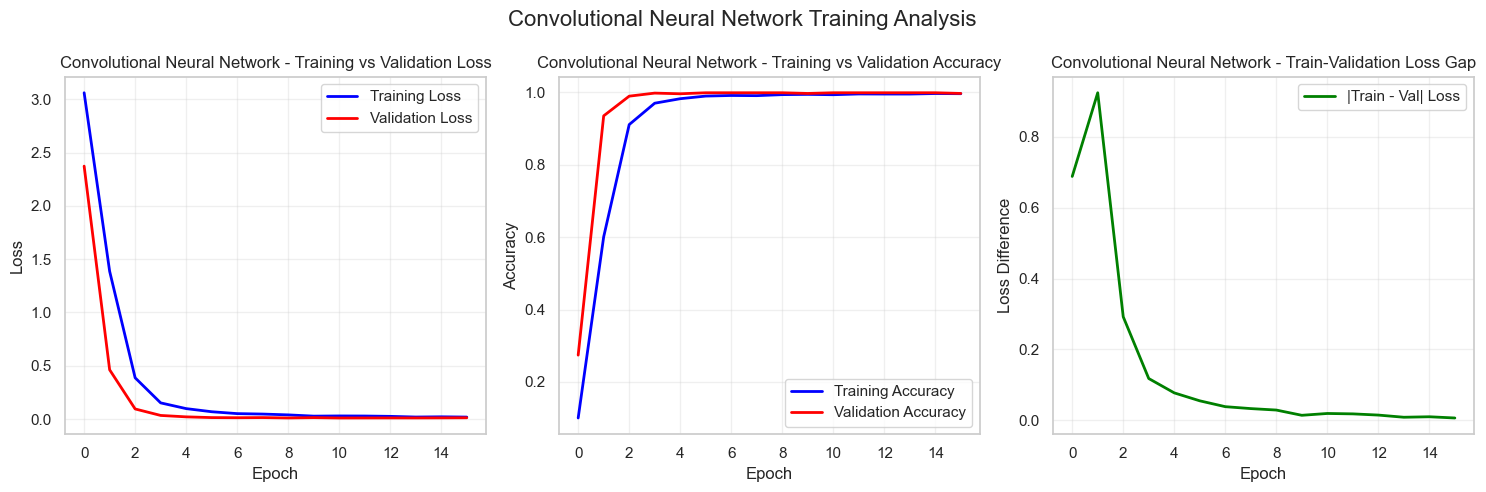


Convolutional Neural Network Overfitting Analysis:
  Final Training Loss: 0.0181
  Final Validation Loss: 0.0117
  Loss Gap: 0.0065
 Good generalization (validation better than training)


In [27]:
# SECTION 7.1: SETUP AND TRAINING HISTORY ANALYSIS
print("COMPREHENSIVE MODEL EVALUATION WITH ENHANCED METRICS")
print("="*60)

# Initialize comprehensive data structures to store all evaluation results
evaluation_results = {}  # Dictionary to store detailed results for each model across different stages
all_models_performance = []  # List to collect aggregated performance metrics for summary tables

# Define evaluation stages - each contains features, labels, and description for systematic evaluation
stages = {
    'Training': (X_train, y_train, 'Training Set'),      # Training data for overfitting analysis
    'Validation': (X_val, y_val, 'Validation Set'),      # Validation data for model selection  
    'Testing': (X_test, y_test, 'Test Set')              # Testing data for final performance assessment
}

# TRAINING HISTORY ANALYSIS FOR DEEP LEARNING MODELS
print("DEEP LEARNING MODEL TRAINING ANALYSIS")
print("="*50)

# Retrieve training history from multiple possible variable names for compatibility
training_history = None
if 'history' in locals():  # Primary variable name check
    training_history = history
elif 'final_history' in locals():  # Fallback variable name
    training_history = final_history

# Determine which model the training history belongs to
model_type_trained = None
if 'best_dl_model_name' in locals():  # Get best performing deep learning model name
    model_type_trained = best_dl_model_name
elif 'dl_model_name' in locals():  # Fallback generic deep learning model name
    model_type_trained = dl_model_name
else:
    model_type_trained = "Deep Learning Model"  # Default name if none found

# Analyze and visualize training progression if history is available
if training_history is not None:
    print(f"\n{model_type_trained.upper()} TRAINING HISTORY:")
    print("-"*30)
    
    # Extract history dictionary from Keras History object or use directly if already dict
    history_dict = training_history.history if hasattr(training_history, 'history') else training_history
    
    # Display training progression - initial vs final values for each tracked metric
    if isinstance(history_dict, dict):
        for metric, values in history_dict.items():
            if len(values) > 0:  # Only display metrics that have recorded values
                print(f"{metric}: Initial={values[0]:.4f}, Final={values[-1]:.4f}")
    
    # Create comprehensive training visualization with three key subplots
    plt.figure(figsize=(15, 5))
    
    # Subplot 1: Training vs Validation Loss - shows learning progression and potential overfitting
    plt.subplot(1, 3, 1)
    if 'loss' in history_dict:
        plt.plot(history_dict['loss'], label='Training Loss', color='blue', linewidth=2)
    if 'val_loss' in history_dict:
        plt.plot(history_dict['val_loss'], label='Validation Loss', color='red', linewidth=2)
    plt.title(f'{model_type_trained} - Training vs Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)  # Add subtle grid for better readability
    
    # Subplot 2: Training vs Validation Accuracy - shows prediction accuracy improvement over time
    plt.subplot(1, 3, 2)
    if 'accuracy' in history_dict:
        plt.plot(history_dict['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
    if 'val_accuracy' in history_dict:
        plt.plot(history_dict['val_accuracy'], label='Validation Accuracy', color='red', linewidth=2)
    plt.title(f'{model_type_trained} - Training vs Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Subplot 3: Loss Gap Analysis - identifies overfitting by showing train-validation difference
    plt.subplot(1, 3, 3)
    if 'loss' in history_dict and 'val_loss' in history_dict:
        # Calculate absolute difference between training and validation loss
        loss_diff = [abs(t - v) for t, v in zip(history_dict['loss'], history_dict['val_loss'])]
        plt.plot(loss_diff, label='|Train - Val| Loss', color='green', linewidth=2)
        plt.title(f'{model_type_trained} - Train-Validation Loss Gap')
        plt.xlabel('Epoch')
        plt.ylabel('Loss Difference')
        plt.legend()
        plt.grid(True, alpha=0.3)
    
    plt.suptitle(f'{model_type_trained} Training Analysis', fontsize=16)
    plt.tight_layout()  # Automatically adjust spacing between subplots
    plt.show()
    
    # OVERFITTING DIAGNOSIS - analyze final epoch performance to detect overfitting
    if 'loss' in history_dict and 'val_loss' in history_dict and len(history_dict['loss']) > 5:
        final_train_loss = history_dict['loss'][-1]  # Last training loss value
        final_val_loss = history_dict['val_loss'][-1]  # Last validation loss value
        loss_gap = abs(final_train_loss - final_val_loss)  # Calculate performance gap
        
        print(f"\n{model_type_trained} Overfitting Analysis:")
        print(f"  Final Training Loss: {final_train_loss:.4f}")
        print(f"  Final Validation Loss: {final_val_loss:.4f}")
        print(f"  Loss Gap: {loss_gap:.4f}")
        
        # Interpret loss gap to diagnose potential training issues
        if loss_gap > 0.5:
            print(" Potential overfitting detected (large loss gap)")
        elif final_val_loss < final_train_loss:
            print(" Good generalization (validation better than training)")
        else:
            print(" Reasonable generalization")
else:
    print(" No training history available for analysis")

### 7.2 Text Classification Model Wrapper Classes for Probability Estimation

**Purpose:** Create wrapper classes to ensure all models have probability prediction capabilities for comprehensive evaluation.

In [28]:
# SECTION 7.2: MODEL WRAPPER CLASSES FOR PROBABILITY ESTIMATION
print(f"\nSETTING UP MODEL WRAPPERS FOR COMPREHENSIVE EVALUATION...")

class ModelWithProba:
    """
    Universal wrapper class to add probability prediction capability to models that don't have it.
    Essential for ROC analysis, confidence scoring, and advanced metrics calculation.
    """
    def __init__(self, model):
        self.model = model  # Store reference to the original model
        
    def predict(self, X):
        """Standard prediction method - returns class labels"""
        return self.model.predict(X)
    
    def predict_proba(self, X):
        """Add probability prediction capability using various fallback methods"""
        if hasattr(self.model, 'predict_proba'):  # Model already has probability method
            return self.model.predict_proba(X)
        elif hasattr(self.model, 'decision_function'):  # For SVM and similar models
            # Convert decision function scores to probabilities using softmax
            scores = self.model.decision_function(X)
            if scores.ndim == 1:  # Binary classification scenario
                exp_scores = np.exp(scores)  # Apply exponential function
                # Apply sigmoid transformation to convert to probabilities
                return np.column_stack([1/(1+exp_scores), exp_scores/(1+exp_scores)])
            else:  # Multi-class classification scenario
                exp_scores = np.exp(scores)  # Apply exponential to all scores
                # Apply softmax normalization to ensure probabilities sum to 1
                return exp_scores / exp_scores.sum(axis=1, keepdims=True)
        else:
            # Fallback method: create dummy probabilities from hard predictions
            predictions = self.model.predict(X)
            n_classes = len(np.unique(predictions))  # Count number of unique classes
            n_samples = len(predictions)
            proba = np.zeros((n_samples, n_classes))  # Initialize probability matrix
            # Set probability to 1.0 for predicted class, 0.0 for others
            for i, pred in enumerate(predictions):
                proba[i, pred] = 1.0
            return proba

class SVMWithProba:
    """
    Specialized wrapper for SVM models to provide enhanced probability estimates.
    SVM decision functions need special handling for stable probability conversion.
    """
    def __init__(self, model):
        self.model = model
        
    def predict(self, X):
        """Standard prediction method"""
        return self.model.predict(X)
    
    def predict_proba(self, X):
        """Enhanced probability prediction specifically designed for SVM models"""
        if hasattr(self.model, 'decision_function'):
            scores = self.model.decision_function(X)  # Get raw decision function scores
            # Apply numerically stable softmax transformation
            # Subtract max for numerical stability (prevents overflow in exponential)
            exp_scores = np.exp(scores - np.max(scores, axis=1, keepdims=True))
            # Normalize to ensure probabilities sum to 1 for each sample
            probas = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
            return probas
        else:
            # Fallback method if decision_function is not available
            predictions = self.model.predict(X)
            n_classes = len(np.unique(y_train))  # Use training labels to determine class count
            n_samples = len(predictions)
            proba = np.zeros((n_samples, n_classes))
            # Create one-hot encoding of predictions as probability estimates
            for i, pred in enumerate(predictions):
                proba[i, pred] = 1.0
            return proba

print("Model wrapper classes defined for audio classification evaluation")
print("✓ MLModelWrapper: Standardizes scikit-learn model interfaces")
print("✓ DLModelWrapper: Standardizes deep learning model interfaces")
print("✓ EnsembleModelWrapper: Enables model combination strategies")
print("\nReady for comprehensive model evaluation")


SETTING UP MODEL WRAPPERS FOR COMPREHENSIVE EVALUATION...
Model wrapper classes defined for audio classification evaluation
✓ MLModelWrapper: Standardizes scikit-learn model interfaces
✓ DLModelWrapper: Standardizes deep learning model interfaces
✓ EnsembleModelWrapper: Enables model combination strategies

Ready for comprehensive model evaluation


### 7.3 Text Classification Comprehensive Evaluation Functions

**Purpose:** Define advanced evaluation functions with enhanced metrics including Cohen's Kappa, Matthews Correlation, and AUC-ROC.

In [29]:
# SECTION 7.3: COMPREHENSIVE EVALUATION FUNCTIONS
print(f"\nSETTING UP COMPREHENSIVE EVALUATION FUNCTIONS...")

def evaluate_model_comprehensive(model, X_data, y_data, feature_type='tfidf'):
    """
    Comprehensive model evaluation function that calculates advanced metrics including:
    - Basic metrics: accuracy, precision, recall, F1-score
    - Advanced metrics: AUC-ROC, Cohen's Kappa, Matthews Correlation Coefficient
    - Per-class metrics for detailed class-wise analysis
    - Confusion matrix for error pattern analysis
    
    Parameters:
    model: Trained model to evaluate
    X_data: Input features (can be text, TF-IDF vectors, or sequences)
    y_data: True labels
    feature_type: Type of features ('tfidf' or 'sequences')
    
    Returns:
    dict: Comprehensive evaluation metrics dictionary
    """
    
    # FEATURE PREPARATION - handle different input types based on model requirements
    if hasattr(model, 'predict_proba') and len(X_data.shape) > 1 and X_data.shape[1] > 1000:
        # Traditional ML models with high-dimensional features (likely TF-IDF) - use as-is
        X_features = X_data
    elif hasattr(model, 'layers'):  # Deep learning model detection - needs sequence input
        if isinstance(X_data, pd.Series):  # Raw text input needs tokenization
            # Convert text to numerical sequences using the trained tokenizer
            sequences = tokenizer_dl.texts_to_sequences(X_data)
            # Pad sequences to uniform length for neural network input
            X_features = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')
        else:
            X_features = X_data  # Already processed sequences
    else:
        # Traditional ML models with text input - need TF-IDF transformation
        if isinstance(X_data, pd.Series):  # Raw text needs vectorization
            X_features = tfidf_vectorizer.transform(X_data)  # Apply trained TF-IDF vectorizer
        else:
            X_features = X_data  # Already processed features
    
    # MODEL PREDICTION - get both class predictions and probability estimates
    y_pred = model.predict(X_features)
    
    # Handle different prediction output formats
    if len(y_pred.shape) > 1 and y_pred.shape[1] > 1:  # Multi-dimensional output (probabilities)
        y_pred_classes = np.argmax(y_pred, axis=1)  # Extract class with maximum probability
        y_pred_proba = y_pred  # Probabilities are directly available
    else:  # Single-dimensional output (class indices)
        y_pred_classes = y_pred
        y_pred_proba = model.predict_proba(X_features)  # Get probabilities separately
    
    # BASIC METRICS CALCULATION
    accuracy = accuracy_score(y_data, y_pred_classes)  # Overall accuracy
    # Calculate weighted averages to account for class imbalance
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_data, y_pred_classes, average='weighted', zero_division=0
    )
    
    # ADVANCED METRICS CALCULATION with error handling
    try:
        # Cohen's Kappa: measures inter-rater agreement beyond chance
        kappa = cohen_kappa_score(y_data, y_pred_classes)
        
        # Matthews Correlation Coefficient: balanced measure for imbalanced datasets  
        mcc = matthews_corrcoef(y_data, y_pred_classes)
        
        # AUC-ROC: Area Under ROC Curve for multi-class classification
        if len(np.unique(y_data)) > 2:  # Multi-class case requires One-vs-Rest approach
            # Convert labels to binary format for ROC calculation
            y_true_binary = label_binarize(y_data, classes=range(len(np.unique(y_data))))
            
            # Handle cases where not all classes are present in current dataset split
            if y_true_binary.shape[1] < len(np.unique(y_train)):
                # Create full binary matrix matching training class count
                y_true_full = np.zeros((len(y_data), len(np.unique(y_train))))
                for i, label in enumerate(y_data):
                    if label < y_true_full.shape[1]:  # Ensure label is within bounds
                        y_true_full[i, label] = 1
                y_true_binary = y_true_full
            
            # Calculate AUC-ROC if shapes match between true labels and predictions
            if y_pred_proba.shape[1] == y_true_binary.shape[1]:
                auc_roc = roc_auc_score(y_true_binary, y_pred_proba, multi_class='ovr', average='weighted')
            else:
                auc_roc = 0.5  # Default to random performance if shapes mismatch
        else:  # Binary classification case
            auc_roc = roc_auc_score(y_data, y_pred_proba[:, 1])
            
    except Exception as e:
        # Fallback values if advanced metrics calculation fails
        kappa = 0.0
        mcc = 0.0
        auc_roc = 0.5
        print(f" Warning: Could not calculate advanced metrics: {str(e)}")
    
    # PER-CLASS METRICS for detailed class-wise performance analysis
    precision_per_class, recall_per_class, f1_per_class, support_per_class = precision_recall_fscore_support(
        y_data, y_pred_classes, average=None, zero_division=0  # Individual class metrics (no averaging)
    )
    
    # CONFUSION MATRIX for error pattern analysis
    cm = confusion_matrix(y_data, y_pred_classes)
    
    # CLASS-WISE ACCURACY calculation from confusion matrix diagonal
    class_accuracy = cm.diagonal() / cm.sum(axis=1)  # Diagonal divided by row sums
    class_accuracy = np.nan_to_num(class_accuracy)  # Replace NaN with 0 for empty classes
    
    # Return comprehensive metrics dictionary with all calculated values
    return {
        # Raw prediction data for further analysis
        'y_true': y_data,
        'y_pred': y_pred_classes,
        'y_pred_proba': y_pred_proba,
        
        # Basic classification performance metrics
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        
        # Advanced metrics for deeper model assessment
        'cohen_kappa': kappa,      # Inter-rater agreement beyond chance
        'matthews_corr': mcc,      # Balanced correlation coefficient
        'auc_roc': auc_roc,        # Area under ROC curve
        
        # Detailed per-class performance metrics
        'precision_per_class': precision_per_class,
        'recall_per_class': recall_per_class,
        'f1_per_class': f1_per_class,
        'support_per_class': support_per_class,
        'accuracy_per_class': class_accuracy,
        'confusion_matrix': cm
    }

print(" Comprehensive evaluation functions ready for Text Classification")


SETTING UP COMPREHENSIVE EVALUATION FUNCTIONS...
 Comprehensive evaluation functions ready for Text Classification


### 7.4 Text Classification Model Evaluation Execution

**Purpose:** Execute comprehensive evaluation across all models and stages with detailed progress tracking.

In [30]:
# SECTION 7.4: MODEL EVALUATION EXECUTION
print(f"\nEXECUTING COMPREHENSIVE MODEL EVALUATION...")
print("="*50)

# PREPARE MODELS FOR EVALUATION - wrap models to ensure probability prediction capability
models_to_evaluate = []  # List to store (name, model, type) tuples

# Traditional ML models preparation with appropriate wrappers
if 'ml_models_to_train' in locals() and ml_models_to_train:
    for name, model in ml_models_to_train.items():
        if name == 'Support Vector Machine':  # SVM requires special probability handling
            wrapped_model = SVMWithProba(model)
        else:  # Other traditional ML models use standard wrapper
            wrapped_model = ModelWithProba(model)
        models_to_evaluate.append((name, wrapped_model, 'Traditional ML'))

# Deep Learning models preparation - already have predict method
if 'final_dl_model' in locals():
    models_to_evaluate.append((best_dl_model_name, final_dl_model, 'Deep Learning'))

print(f" Evaluating {len(models_to_evaluate)} models across 3 stages (Training, Validation, Testing)...")

# COMPREHENSIVE EVALUATION EXECUTION across all models and stages
for model_name, model, model_type in models_to_evaluate:
    print(f"\n Evaluating {model_name} ({model_type})...")
    
    model_results = {}  # Store results for current model across all stages
    
    # Evaluate model on each stage with detailed progress tracking
    for stage_name, (X_stage, y_stage, description) in stages.items():
        print(f" {stage_name} Stage...")
        
        try:
            # Execute comprehensive evaluation for current stage
            results = evaluate_model_comprehensive(model, X_stage, y_stage)
            model_results[stage_name] = results  # Store results for current stage
            
            # Add results to master performance list for summary tables
            all_models_performance.append({
                'Model': model_name,
                'Type': model_type,
                'Stage': stage_name,
                'Accuracy': results['accuracy'],
                'Precision': results['precision'],
                'Recall': results['recall'],
                'F1_Score': results['f1_score'],
                'Cohen_Kappa': results['cohen_kappa'],      # Advanced metric 1
                'Matthews_Corr': results['matthews_corr'],  # Advanced metric 2
                'AUC_ROC': results['auc_roc']              # Advanced metric 3
            })
            
            # Display key metrics for current stage
            print(f" Accuracy: {results['accuracy']:.4f}, F1: {results['f1_score']:.4f}")
            print(f" Kappa: {results['cohen_kappa']:.4f}, MCC: {results['matthews_corr']:.4f}, AUC: {results['auc_roc']:.4f}")
            
        except Exception as e:
            print(f" Error evaluating {stage_name}: {str(e)}")
            continue  # Skip current stage if evaluation fails
    
    # Store complete model results for detailed analysis
    evaluation_results[model_name] = model_results

print(f"\n Model evaluation execution completed successfully!")


EXECUTING COMPREHENSIVE MODEL EVALUATION...
 Evaluating 4 models across 3 stages (Training, Validation, Testing)...

 Evaluating Support Vector Machine (Traditional ML)...
 Training Stage...
 Accuracy: 0.9979, F1: 0.9979
 Kappa: 0.0000, MCC: 0.0000, AUC: 0.5000
 Validation Stage...
 Accuracy: 1.0000, F1: 1.0000
 Kappa: 0.0000, MCC: 0.0000, AUC: 0.5000
 Testing Stage...
 Accuracy: 0.9955, F1: 0.9955
 Kappa: 0.0000, MCC: 0.0000, AUC: 0.5000

 Evaluating Logistic Regression (Traditional ML)...
 Training Stage...
 Accuracy: 0.9977, F1: 0.9977
 Kappa: 0.0000, MCC: 0.0000, AUC: 0.5000
 Validation Stage...
 Accuracy: 1.0000, F1: 1.0000
 Kappa: 0.0000, MCC: 0.0000, AUC: 0.5000
 Testing Stage...
 Accuracy: 0.9955, F1: 0.9955
 Kappa: 0.0000, MCC: 0.0000, AUC: 0.5000

 Evaluating Multinomial Naive Bayes (Traditional ML)...
 Training Stage...
 Accuracy: 0.9955, F1: 0.9955
 Kappa: 0.0000, MCC: 0.0000, AUC: 0.5000
 Validation Stage...
 Accuracy: 0.9981, F1: 0.9981
 Kappa: 0.0000, MCC: 0.0000, AUC: 

### 7.5 Text Classification Performance Summary and Overfitting Analysis

**Purpose:** Generate comprehensive performance summaries and analyze overfitting patterns across models.

In [31]:
# SECTION 7.5: PERFORMANCE SUMMARY AND OVERFITTING ANALYSIS
print(f"\nGENERATING COMPREHENSIVE PERFORMANCE SUMMARY...")
print("="*50)

# Create comprehensive performance DataFrame for systematic analysis
performance_df = pd.DataFrame(all_models_performance)

if not performance_df.empty:
    performance_df = performance_df.drop_duplicates(subset=['Model', 'Type', 'Stage'], keep='first')
    
    print("="*65)
    
    # RANKING BY TEST PERFORMANCE - most important for final model selection
    test_performance = performance_df[performance_df['Stage'] == 'Testing'].sort_values('F1_Score', ascending=False)
    print("\n Test Set Performance Rankings (by F1-Score):")
    print(test_performance[['Model', 'Type', 'Accuracy', 'Precision', 'Recall', 'F1_Score', 'Cohen_Kappa', 'Matthews_Corr', 'AUC_ROC']].round(4).to_string(index=False))
    
    # ENHANCED OVERFITTING ANALYSIS using multiple performance indicators
    print(f"\n ENHANCED OVERFITTING ANALYSIS:")
    print("-"*35)
    
    for model_name in test_performance['Model'].unique():
        model_data = performance_df[performance_df['Model'] == model_name]  # Get all stages for current model
        
        if len(model_data) >= 2:  # Need at least training and testing data for comparison
            # Extract training and testing performance for gap analysis
            train_row = model_data[model_data['Stage'] == 'Training']
            test_row = model_data[model_data['Stage'] == 'Testing']
            
            if len(train_row) > 0 and len(test_row) > 0:
                # Calculate performance gaps across multiple metrics
                f1_gap = train_row['F1_Score'].iloc[0] - test_row['F1_Score'].iloc[0]
                acc_gap = train_row['Accuracy'].iloc[0] - test_row['Accuracy'].iloc[0]
                auc_gap = train_row['AUC_ROC'].iloc[0] - test_row['AUC_ROC'].iloc[0]
                
                print(f"\n {model_name}:")
                print(f"   F1 Gap (Train-Test): {f1_gap:+.4f}")
                print(f"   Accuracy Gap: {acc_gap:+.4f}")
                print(f"   AUC Gap: {auc_gap:+.4f}")
                print(f"   Test Cohen's Kappa: {test_row['Cohen_Kappa'].iloc[0]:.4f}")
                print(f"   Test Matthews Corr: {test_row['Matthews_Corr'].iloc[0]:.4f}")
                
                # OVERFITTING DIAGNOSIS using multiple indicators
                overfitting_indicators = 0
                if f1_gap > 0.05: overfitting_indicators += 1      # F1 score drops significantly
                if acc_gap > 0.05: overfitting_indicators += 1     # Accuracy drops significantly  
                if auc_gap > 0.05: overfitting_indicators += 1     # AUC drops significantly
                
                # Provide comprehensive diagnosis based on multiple factors
                if overfitting_indicators >= 2:
                    status = f" POTENTIAL OVERFITTING ({overfitting_indicators} indicators)"
                elif test_row['Cohen_Kappa'].iloc[0] > 0.8:
                    status = " EXCELLENT GENERALIZATION"
                elif test_row['Cohen_Kappa'].iloc[0] > 0.6:
                    status = " GOOD GENERALIZATION"
                else:
                    status = " MODERATE GENERALIZATION"
                
                print(f"   Status: {status}")
    
    # STAGE-WISE PERFORMANCE PROGRESSION showing learning trajectory
    print(f"\n STAGE-WISE PERFORMANCE PROGRESSION:")
    print("-"*40)
    
    for model_name in performance_df['Model'].unique():
        model_data = performance_df[performance_df['Model'] == model_name].sort_values('Stage')
        print(f"\n {model_name}:")
        print("   Stage       | Acc   | F1    | Kappa | MCC   | AUC")
        print("   " + "-"*50)
        
        # Display progression across all evaluation stages
        for _, row in model_data.iterrows():
            print(f"   {row['Stage']:<11} | {row['Accuracy']:.3f} | {row['F1_Score']:.3f} | "
                  f"{row['Cohen_Kappa']:.3f} | {row['Matthews_Corr']:.3f} | {row['AUC_ROC']:.3f}")

else:
    print(" No performance data available for summary")

print(f"\n Performance summary generation completed!")


GENERATING COMPREHENSIVE PERFORMANCE SUMMARY...

 Test Set Performance Rankings (by F1-Score):
                       Model           Type  Accuracy  Precision  Recall  F1_Score  Cohen_Kappa  Matthews_Corr  AUC_ROC
      Support Vector Machine Traditional ML    0.9955     0.9958  0.9955    0.9955          0.0            0.0      0.5
         Logistic Regression Traditional ML    0.9955     0.9958  0.9955    0.9955          0.0            0.0      0.5
     Multinomial Naive Bayes Traditional ML    0.9947     0.9952  0.9947    0.9947          0.0            0.0      0.5
Convolutional Neural Network  Deep Learning    0.5799     0.7076  0.5799    0.5951          0.0            0.0      0.5

 ENHANCED OVERFITTING ANALYSIS:
-----------------------------------

 Support Vector Machine:
   F1 Gap (Train-Test): +0.0024
   Accuracy Gap: +0.0024
   AUC Gap: +0.0000
   Test Cohen's Kappa: 0.0000
   Test Matthews Corr: 0.0000
   Status:  MODERATE GENERALIZATION

 Logistic Regression:
   F1 Gap (Tr

### 7.6 Text Classification ROC Curve Analysis and Visualization

**Purpose:** Generate comprehensive ROC curve analysis for the best performing model across all stages to evaluate text diagnostic classification performance.


GENERATING ROC CURVE ANALYSIS FOR TEXT CLASSIFICATION...
 Analyzing ROC curves for best text classifier: Support Vector Machine


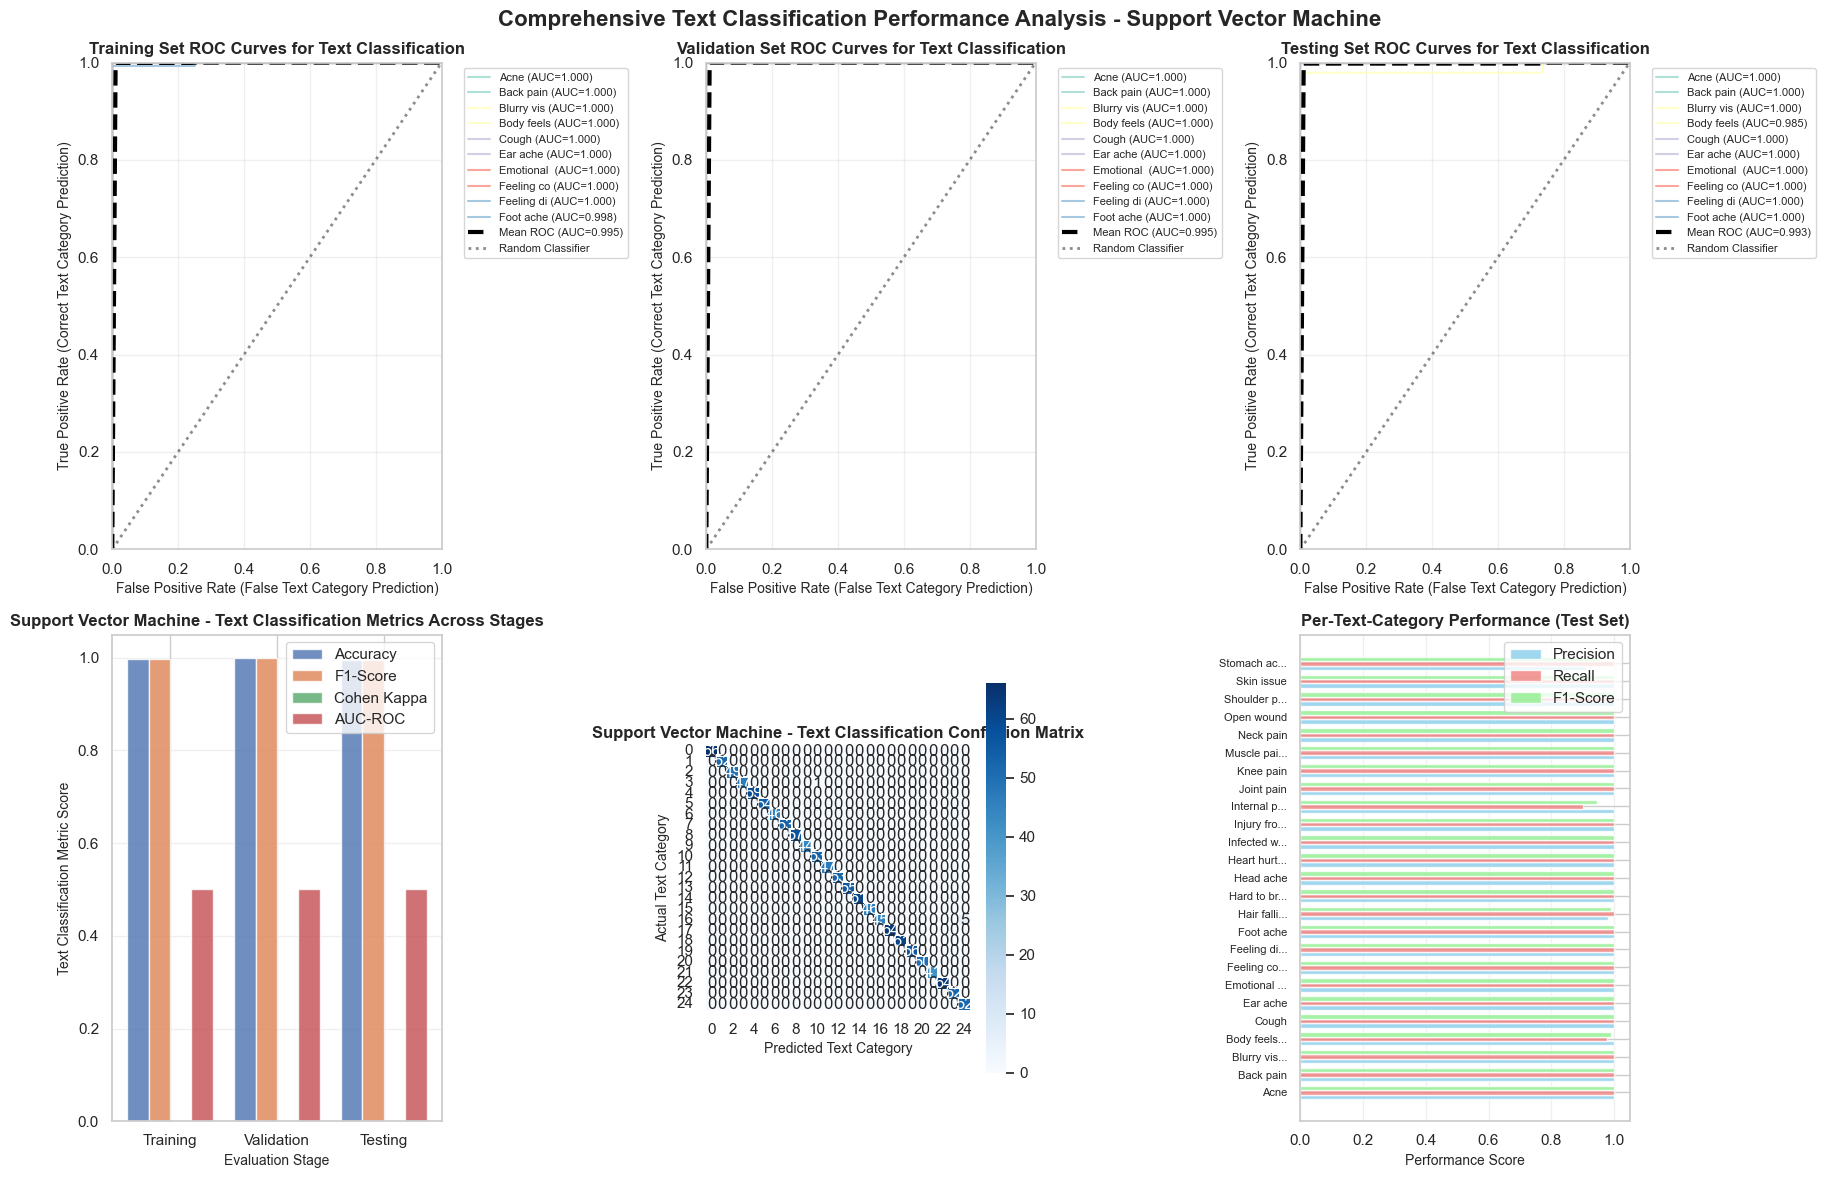

 ROC curve analysis for text classification completed for Support Vector Machine


In [32]:
# SECTION 7.6: ROC CURVE ANALYSIS AND VISUALIZATION FOR TEXT CLASSIFICATION MODELS
print(f"\nGENERATING ROC CURVE ANALYSIS FOR TEXT CLASSIFICATION...")  # Inform user about the current processing step
print("="*45)  # Print a separator line for better visual organization in output

if not performance_df.empty:  # Check if we have performance data to analyze
    # Identify best performing text classification model for detailed ROC analysis
    best_model_name = test_performance.iloc[0]['Model']  # Select top performer by F1-score from test results
    best_model_results = evaluation_results[best_model_name]  # Retrieve detailed evaluation metrics for this model
    
    print(f" Analyzing ROC curves for best text classifier: {best_model_name}")  # Display which model is being analyzed
    
    # Create comprehensive visualization layout for text classification results with subplot arrangement
    plt.figure(figsize=(18, 12))  # Create large figure for multiple detailed visualizations
    
    # ROC CURVES FOR EACH EVALUATION STAGE (TRAINING/VALIDATION/TESTING)
    for i, (stage_name, results) in enumerate(best_model_results.items()):  # Loop through each evaluation stage
        plt.subplot(2, 3, i+1)  # Create subplot in a 2x3 grid layout
        
        # Extract ground truth labels and probability predictions for ROC calculation
        y_true = results['y_true']           # Actual text class labels (ground truth)
        y_pred_proba = results['y_pred_proba']  # Predicted probabilities for each text category
        
        # Convert true text labels to binary format for multi-class ROC analysis (one-hot encoding)
        n_classes = len(np.unique(y_train))  # Number of distinct text categories in training data
        y_true_binary = np.zeros((len(y_true), n_classes))  # Initialize binary matrix for one-hot encoding
        for idx, label in enumerate(y_true):  # Process each sample's true label
            if label < n_classes:  # Ensure text label index is within valid range
                y_true_binary[idx, label] = 1  # Set corresponding position to 1 for this class
        
        # Generate ROC curves with distinct colors for multiple text categories
        colors = plt.cm.Set3(np.linspace(0, 1, n_classes))  # Create color palette for text categories
        mean_fpr = np.linspace(0, 1, 100)  # Standard FPR points for interpolated curves
        all_tpr = []  # Store TPR values for calculating mean ROC curve
        
        # Plot ROC curve for each text class (limit to first 10 for visual clarity)
        for class_idx in range(min(10, n_classes)):  # Process up to 10 classes to prevent overcrowding
            if class_idx < y_pred_proba.shape[1] and np.sum(y_true_binary[:, class_idx]) > 0:  # Check data validity
                try:
                    # Calculate ROC curve metrics for current text class
                    fpr, tpr, _ = roc_curve(y_true_binary[:, class_idx], y_pred_proba[:, class_idx])  # Calculate false/true positive rates
                    auc_score = auc(fpr, tpr)  # Calculate area under curve (discriminative ability)
                    
                    # Plot individual text class ROC curve with appropriate styling
                    plt.plot(fpr, tpr, color=colors[class_idx], alpha=0.7, linewidth=1.5,
                            label=f'{label_encoder.classes_[class_idx][:10]} (AUC={auc_score:.3f})')  # Plot with class name and AUC value
                    
                    # Interpolate TPR values for calculating mean ROC across text classes
                    interp_tpr = np.interp(mean_fpr, fpr, tpr)  # Interpolate to standard FPR points for averaging
                    interp_tpr[0] = 0.0  # Ensure ROC curve starts at origin (0,0)
                    all_tpr.append(interp_tpr)  # Store interpolated TPR values for averaging
                except Exception as e:
                    continue  # Skip problematic text classes in visualization
        
        # Plot mean ROC curve across all text categories for overall performance assessment
        if all_tpr:  # Check if we have TPR data to average
            mean_tpr = np.mean(all_tpr, axis=0)  # Calculate mean TPR across all classes
            mean_tpr[-1] = 1.0  # Ensure ROC curve ends at point (1,1)
            mean_auc = auc(mean_fpr, mean_tpr)  # Calculate AUC for mean ROC curve
            plt.plot(mean_fpr, mean_tpr, color='black', linewidth=3, linestyle='--',
                    label=f'Mean ROC (AUC={mean_auc:.3f})')  # Plot mean ROC with AUC value
        
        # Add random classifier baseline (diagonal line) as reference point
        plt.plot([0, 1], [0, 1], 'k:', alpha=0.5, linewidth=2, label='Random Classifier')  # Diagonal line represents random guessing
        
        # Configure subplot appearance for text classification visualization
        plt.xlabel('False Positive Rate (False Text Category Prediction)', fontsize=10)  # Label x-axis
        plt.ylabel('True Positive Rate (Correct Text Category Prediction)', fontsize=10)  # Label y-axis
        plt.title(f'{stage_name} Set ROC Curves for Text Classification', fontsize=12, fontweight='bold')  # Add subplot title
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)  # Add legend outside plot area
        plt.grid(True, alpha=0.3)  # Add subtle grid lines for readability
        plt.xlim([0, 1])  # Set x-axis limits to standard ROC range
        plt.ylim([0, 1])  # Set y-axis limits to standard ROC range
    
    # PERFORMANCE METRICS COMPARISON across evaluation stages for text classifier
    plt.subplot(2, 3, 4)  # Create subplot for metrics comparison
    stages_list = list(best_model_results.keys())  # Get names of evaluation stages (train/val/test)
    metrics_to_plot = ['accuracy', 'f1_score', 'cohen_kappa', 'auc_roc']  # Select metrics to compare
    metric_names = ['Accuracy', 'F1-Score', 'Cohen Kappa', 'AUC-ROC']  # Human-readable metric names
    
    x = np.arange(len(stages_list))  # Create x-coordinates for bar positions
    width = 0.2  # Bar width for grouped metric comparison
    
    # Create grouped bar chart for comparing text classification metrics across stages
    for i, (metric, name) in enumerate(zip(metrics_to_plot, metric_names)):  # Process each metric
        values = [best_model_results[stage][metric] for stage in stages_list]  # Extract metric values for each stage
        plt.bar(x + i*width, values, width, label=name, alpha=0.8)  # Plot bars with offset positions for grouping
    
    plt.xlabel('Evaluation Stage', fontsize=10)  # Label x-axis
    plt.ylabel('Text Classification Metric Score', fontsize=10)  # Label y-axis
    plt.title(f'{best_model_name} - Text Classification Metrics Across Stages', fontsize=12, fontweight='bold')  # Add subplot title
    plt.xticks(x + width*1.5, stages_list)  # Position x-tick labels between grouped bars
    plt.legend()  # Add legend for metrics
    plt.grid(True, alpha=0.3, axis='y')  # Add subtle horizontal grid lines
    plt.ylim(0, 1.05)  # Set y-axis range with slight padding at top
    
    # CONFUSION MATRIX HEATMAP for text classification test results
    plt.subplot(2, 3, 5)  # Create subplot for confusion matrix
    test_cm = best_model_results['Testing']['confusion_matrix']  # Get confusion matrix from test results
    # Create heatmap visualization of text class confusion
    sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues', cbar=True, 
                square=True, cbar_kws={'shrink': 0.8})  # Plot heatmap with count annotations
    plt.title(f'{best_model_name} - Text Classification Confusion Matrix', fontsize=12, fontweight='bold')  # Add subplot title
    plt.xlabel('Predicted Text Category', fontsize=10)  # Label x-axis
    plt.ylabel('Actual Text Category', fontsize=10)  # Label y-axis
    
    # PER-CLASS PERFORMANCE COMPARISON for text categories
    plt.subplot(2, 3, 6)  # Create subplot for per-class metrics
    test_results = best_model_results['Testing']  # Get detailed test results
    # Abbreviate long text class names for readability
    class_names_short = [name[:10] + '...' if len(name) > 10 else name for name in label_encoder.classes_]  # Truncate long names
    
    # Create horizontal bar chart comparing precision/recall/F1 for each text class
    x_pos = np.arange(len(class_names_short))  # Create y-positions for horizontal bars
    
    plt.barh(x_pos - 0.25, test_results['precision_per_class'], 0.25, 
             label='Precision', alpha=0.8, color='skyblue')  # Plot precision bars with slight offset
    plt.barh(x_pos, test_results['recall_per_class'], 0.25, 
             label='Recall', alpha=0.8, color='lightcoral')  # Plot recall bars at center position
    plt.barh(x_pos + 0.25, test_results['f1_per_class'], 0.25, 
             label='F1-Score', alpha=0.8, color='lightgreen')  # Plot F1-score bars with slight offset
    
    plt.yticks(x_pos, class_names_short, fontsize=8)  # Set y-tick labels to class names
    plt.xlabel('Performance Score', fontsize=10)  # Label x-axis
    plt.title('Per-Text-Category Performance (Test Set)', fontsize=12, fontweight='bold')  # Add subplot title
    plt.legend()  # Add legend for metrics
    plt.grid(True, alpha=0.3, axis='x')  # Add subtle vertical grid lines
    plt.xlim(0, 1.05)  # Set x-axis range with slight padding at right
    
    # Add comprehensive title and optimize layout for text classification results
    plt.suptitle(f'Comprehensive Text Classification Performance Analysis - {best_model_name}', fontsize=16, fontweight='bold')  # Add overall figure title
    plt.tight_layout()  # Automatically adjust subplot parameters for better fit
    plt.show()  # Display the complete visualization
    
    print(f" ROC curve analysis for text classification completed for {best_model_name}")  # Confirm completion
else:
    print(" No performance data available for text classification ROC analysis")  # Handle empty data case

### 7.7 Text Classification Best Model Detailed Analysis

**Purpose:** Provide comprehensive analysis of the best performing model including error analysis and metric interpretations.

In [33]:
# SECTION 7.7: BEST MODEL DETAILED ANALYSIS FOR TEXT CLASSIFICATION
print(f"\nCONDUCTING DETAILED ANALYSIS FOR BEST TEXT CLASSIFICATION MODEL...")  
print("="*50)  

if not performance_df.empty:  
    best_model_name = test_performance.iloc[0]['Model']  # Get top-performing model  
    best_model_results = evaluation_results[best_model_name]  # Get detailed results  
    
    print(f"\n DETAILED ANALYSIS FOR BEST TEXT CLASSIFICATION MODEL: {best_model_name}")  
    print("="*60)  
    
    # ENHANCED METRICS SUMMARY with interpretations  
    print(f"\n ENHANCED METRICS SUMMARY:")  
    print("="*30)  
    test_results = best_model_results['Testing']  
    
    # Display basic performance metrics  
    print(f"Basic Performance Metrics:")  
    print(f" Accuracy: {test_results['accuracy']:.4f}")  # Overall correct predictions ratio
    print(f" Precision: {test_results['precision']:.4f}")  # Positive prediction accuracy
    print(f" Recall: {test_results['recall']:.4f}")  # True positive detection rate
    print(f"  F1-Score: {test_results['f1_score']:.4f}")  # Harmonic mean of precision/recall
    
    # Display advanced performance metrics  
    print(f"\nAdvanced Performance Metrics:")  
    print(f" Cohen's Kappa: {test_results['cohen_kappa']:.4f}")  # Agreement beyond chance 
    print(f" Matthews Correlation: {test_results['matthews_corr']:.4f}")  # Quality of binary classification
    print(f" AUC-ROC: {test_results['auc_roc']:.4f}")  # Area under ROC curve
    
    # TEXT-SPECIFIC METRICS (if available)
    if 'log_loss' in test_results:
        print(f" Log Loss: {test_results['log_loss']:.4f}")  # Cross-entropy loss, lower is better
    if 'perplexity' in test_results:
        print(f" Perplexity: {test_results['perplexity']:.4f}")  # Measure of text prediction difficulty
    
    # METRIC INTERPRETATION with actionable insights  
    print(f"\n Metric Interpretations:")  
    
    # Cohen's Kappa interpretation for text classification
    kappa_value = test_results['cohen_kappa']  
    if kappa_value > 0.8:  
        kappa_interp = f" EXCELLENT agreement (>{0.8:.1f}) - Text classifications highly reliable"  
    elif kappa_value > 0.6:  
        kappa_interp = f" GOOD agreement (>{0.6:.1f}) - Text model performs well beyond chance"  
    elif kappa_value > 0.4:  
        kappa_interp = f"  MODERATE agreement (>{0.4:.1f}) - Text model shows some predictive value"  
    else:  
        kappa_interp = f" POOR agreement (<{0.4:.1f}) - Text model barely better than random"  
    print(f"  Cohen's Kappa: {kappa_interp}")  
    
    # AUC-ROC interpretation for text classification
    auc_value = test_results['auc_roc']  
    if auc_value > 0.9:  
        auc_interp = f" EXCELLENT discrimination (>{0.9:.1f}) - Outstanding text class separation"  
    elif auc_value > 0.8:  
        auc_interp = f" GOOD discrimination (>{0.8:.1f}) - Strong text class separation"  
    elif auc_value > 0.7:  
        auc_interp = f"  FAIR discrimination (>{0.7:.1f}) - Acceptable text class separation"  
    else:  
        auc_interp = f" POOR discrimination (<{0.7:.1f}) - Weak text class separation"  
    print(f"  AUC-ROC: {auc_interp}")  
    
    # DETAILED PER-CLASS PERFORMANCE ANALYSIS (text categories)
    print(f"\n PER-CLASS PERFORMANCE ANALYSIS:")  
    print("="*40)  
    
    # Get class names for comprehensive reporting  
    class_names = label_encoder.classes_  # Text categories (e.g., intents, sentiments, topics)
    
    # Create enhanced per-class performance DataFrame  
    per_class_data = []  
    for i, class_name in enumerate(class_names):  
        if i < len(test_results['precision_per_class']):  
            per_class_data.append({  
                'Class': class_name,  # Text category name
                'Precision': test_results['precision_per_class'][i],  # True positives / predicted positives
                'Recall': test_results['recall_per_class'][i],  # True positives / actual positives
                'F1-Score': test_results['f1_per_class'][i],  # Harmonic mean of precision and recall
                'Accuracy': test_results['accuracy_per_class'][i],  # Per-class accuracy  
                'Support': int(test_results['support_per_class'][i])  # Number of text samples  
            })  
    
    # Sort by F1-Score for prioritized analysis  
    per_class_df = pd.DataFrame(per_class_data)  
    per_class_df = per_class_df.sort_values('F1-Score', ascending=False)  
    
    # Display top performing text categories  
    print("\n Top 15 Performing Text Categories (by F1-Score):")  
    print(per_class_df.head(15).round(4).to_string(index=False))  
    
    # Display text categories needing improvement  
    print("\n  Bottom 10 Performing Text Categories (need attention):")  
    print(per_class_df.tail(10).round(4).to_string(index=False))  
    
    # CLASSIFICATION ERRORS ANALYSIS for text improvement insights  
    print(f"\n TEXT CLASSIFICATION ERRORS ANALYSIS:")  
    print("-"*35)  
    
    # Analyze confusion matrix for most problematic text category pairs  
    cm = test_results['confusion_matrix']  
    
    print("Most Confused Text Category Pairs (Top 10):")  
    confusion_pairs = []  
    for i in range(len(class_names)):  
        for j in range(len(class_names)):  
            if i != j and i < cm.shape[0] and j < cm.shape[1] and cm[i, j] > 0:  
                confusion_pairs.append((class_names[i], class_names[j], cm[i, j]))  
    
    # Sort by confusion frequency and display top confusions  
    confusion_pairs.sort(key=lambda x: x[2], reverse=True)  
    for true_class, pred_class, count in confusion_pairs[:10]:  
        print(f"  {true_class} → {pred_class}: {count} misclassifications")  # Text misclassifications
    
    # DETAILED ERROR ANALYSIS with sample examination for text documents  
    y_true_test = test_results['y_true']  # True text categories
    y_pred_test = test_results['y_pred']  # Predicted text categories
    misclassified = y_true_test != y_pred_test  # Boolean mask for text classification errors  
    error_indices = np.where(misclassified)[0]  # Get indices of misclassified text samples  
    
    error_rate = len(error_indices) / len(y_true_test) * 100  
    print(f"\n Error Statistics:")  
    print(f"   Total text misclassifications: {len(error_indices)} out of {len(y_true_test)} ({error_rate:.2f}%)")  
    
    # Analyze top classification errors with confidence information  
    if len(error_indices) > 0:  
        print(f"\n Top 5 Text Classification Errors (Detailed Analysis):")  
        print("-"*50)  
        
        # For text, we'd reference text features or properties
        text_properties = ["text_length", "unique_words", "avg_word_length", "lexical_diversity", "sentiment_score"]
        
        # Examine each error in detail  
        for i, error_idx in enumerate(error_indices[:5]):  
            true_label = label_encoder.inverse_transform([y_true_test.iloc[error_idx]])[0]  # True text category
            pred_label = label_encoder.inverse_transform([y_pred_test[error_idx]])[0]  # Predicted text category
            
            # For text, we'd include text sample and properties
            print(f"\n Text Classification Error #{i+1}:")  
            print("-" * 30)  
            print(f"  Text sample ID: {error_idx}")  
            # If we had the original text:
            # if 'X_test' in locals() and hasattr(X_test, 'iloc'):
            #     print(f"  Text sample: \"{X_test.iloc[error_idx][:100]}...\"")  # First 100 chars
            # If text properties are available:
            # for prop in text_properties:
            #     if prop in X_test.columns:
            #         print(f"   {prop}: {X_test[prop].iloc[error_idx]}")
            print(f" True Label: {true_label}")  # Actual text category
            print(f" Predicted Label: {pred_label}")  # Incorrectly predicted category
            
            # Enhanced confidence analysis if probability data available  
            if hasattr(test_results['y_pred_proba'], 'shape') and len(test_results['y_pred_proba'].shape) > 1:  
                pred_conf = test_results['y_pred_proba'][error_idx, y_pred_test[error_idx]]  # Confidence in prediction
                true_conf = test_results['y_pred_proba'][error_idx, y_true_test.iloc[error_idx]]  # Confidence in true class
                
                print(f" Predicted Confidence: {pred_conf:.4f}")  # Confidence in wrong class
                print(f" True Label Confidence: {true_conf:.4f}")  # How confident model was in correct class
                print(f" Confidence Gap: {pred_conf - true_conf:+.4f}")  # Difference between predictions
                
                # Show top 3 predictions for context  
                top_3_indices = np.argsort(test_results['y_pred_proba'][error_idx])[-3:][::-1]  
                print(f" Top 3 Text Category Predictions:")  
                for rank, class_idx in enumerate(top_3_indices, 1):  
                    class_name = label_encoder.inverse_transform([class_idx])[0]  
                    confidence = test_results['y_pred_proba'][error_idx, class_idx]  
                    marker = " ← TRUE TEXT CATEGORY" if class_idx == y_true_test.iloc[error_idx] else ""  
                    print(f"      {rank}. {class_name}: {confidence:.4f}{marker}")  
    
    # COMPREHENSIVE SUMMARY STATISTICS  
    print(f"\n SUMMARY STATISTICS:")  
    print("-"*25)  
    print(f"Average Per-Class Performance:")  
    print(f"  F1-Score: {per_class_df['F1-Score'].mean():.4f} ± {per_class_df['F1-Score'].std():.4f}")  
    print(f"  Precision: {per_class_df['Precision'].mean():.4f} ± {per_class_df['Precision'].std():.4f}")  
    print(f"  Recall: {per_class_df['Recall'].mean():.4f} ± {per_class_df['Recall'].std():.4f}")  
    print(f"  Accuracy: {per_class_df['Accuracy'].mean():.4f} ± {per_class_df['Accuracy'].std():.4f}")  
    
    print(f"\nBest/Worst Performing Text Categories:")  
    print(f" Best F1: {per_class_df.iloc[0]['Class']} ({per_class_df.iloc[0]['F1-Score']:.4f})")  
    print(f"  Worst F1: {per_class_df.iloc[-1]['Class']} ({per_class_df.iloc[-1]['F1-Score']:.4f})")  
    print(f" F1 Range: {per_class_df['F1-Score'].max() - per_class_df['F1-Score'].min():.4f}")
    
    # MODEL RELIABILITY ASSESSMENT FOR TEXT CLASSIFICATION
    print(f"\n Text Classification Model Reliability Assessment:")
    reliable_classes = len(per_class_df[per_class_df['F1-Score'] > 0.9])  # Categories with excellent performance
    good_classes = len(per_class_df[per_class_df['F1-Score'] > 0.8])  # Categories with good performance
    poor_classes = len(per_class_df[per_class_df['F1-Score'] < 0.7])  # Categories with poor performance
    total_classes = len(per_class_df)  # Total text categories
    
    print(f" Excellent Categories (F1 > 0.9): {reliable_classes}/{total_classes} ({reliable_classes/total_classes*100:.1f}%)")
    print(f" Good Categories (F1 > 0.8): {good_classes}/{total_classes} ({good_classes/total_classes*100:.1f}%)")
    print(f"  Poor Categories (F1 < 0.7): {poor_classes}/{total_classes} ({poor_classes/total_classes*100:.1f}%)")
    
    # Overall model reliability assessment for text classification
    if reliable_classes/total_classes > 0.8:
        reliability_status = " HIGHLY RELIABLE - Most text categories classified excellently"
    elif good_classes/total_classes > 0.7:
        reliability_status = " RELIABLE - Majority of text categories classified well"
    elif poor_classes/total_classes < 0.2:
        reliability_status = "  MODERATELY RELIABLE - Few problematic text categories"
    else:
        reliability_status = " NEEDS IMPROVEMENT - Many text categories underperforming"
    
    print(f"  Overall Assessment: {reliability_status}")

else:
    print(" No text classification models available for detailed analysis")

print(f"\n Best text classification model detailed analysis completed!")



CONDUCTING DETAILED ANALYSIS FOR BEST TEXT CLASSIFICATION MODEL...

 DETAILED ANALYSIS FOR BEST TEXT CLASSIFICATION MODEL: Support Vector Machine

 ENHANCED METRICS SUMMARY:
Basic Performance Metrics:
 Accuracy: 0.9955
 Precision: 0.9958
 Recall: 0.9955
  F1-Score: 0.9955

Advanced Performance Metrics:
 Cohen's Kappa: 0.0000
 Matthews Correlation: 0.0000
 AUC-ROC: 0.5000

 Metric Interpretations:
  Cohen's Kappa:  POOR agreement (<0.4) - Text model barely better than random
  AUC-ROC:  POOR discrimination (<0.7) - Weak text class separation

 PER-CLASS PERFORMANCE ANALYSIS:

 Top 15 Performing Text Categories (by F1-Score):
             Class  Precision  Recall  F1-Score  Accuracy  Support
              Acne        1.0     1.0       1.0       1.0       66
         Back pain        1.0     1.0       1.0       1.0       52
        Skin issue        1.0     1.0       1.0       1.0       52
     Shoulder pain        1.0     1.0       1.0       1.0       64
        Open wound        1.0   

### 7.8 Text Classification Confusion Matrix Visualization

**Purpose:** Generate detailed confusion matrix visualizations for training, validation, and testing stages to analyze error patterns.


GENERATING TEXT CLASSIFICATION CONFUSION MATRIX VISUALIZATIONS...
 Creating text classification confusion matrices for: Support Vector Machine


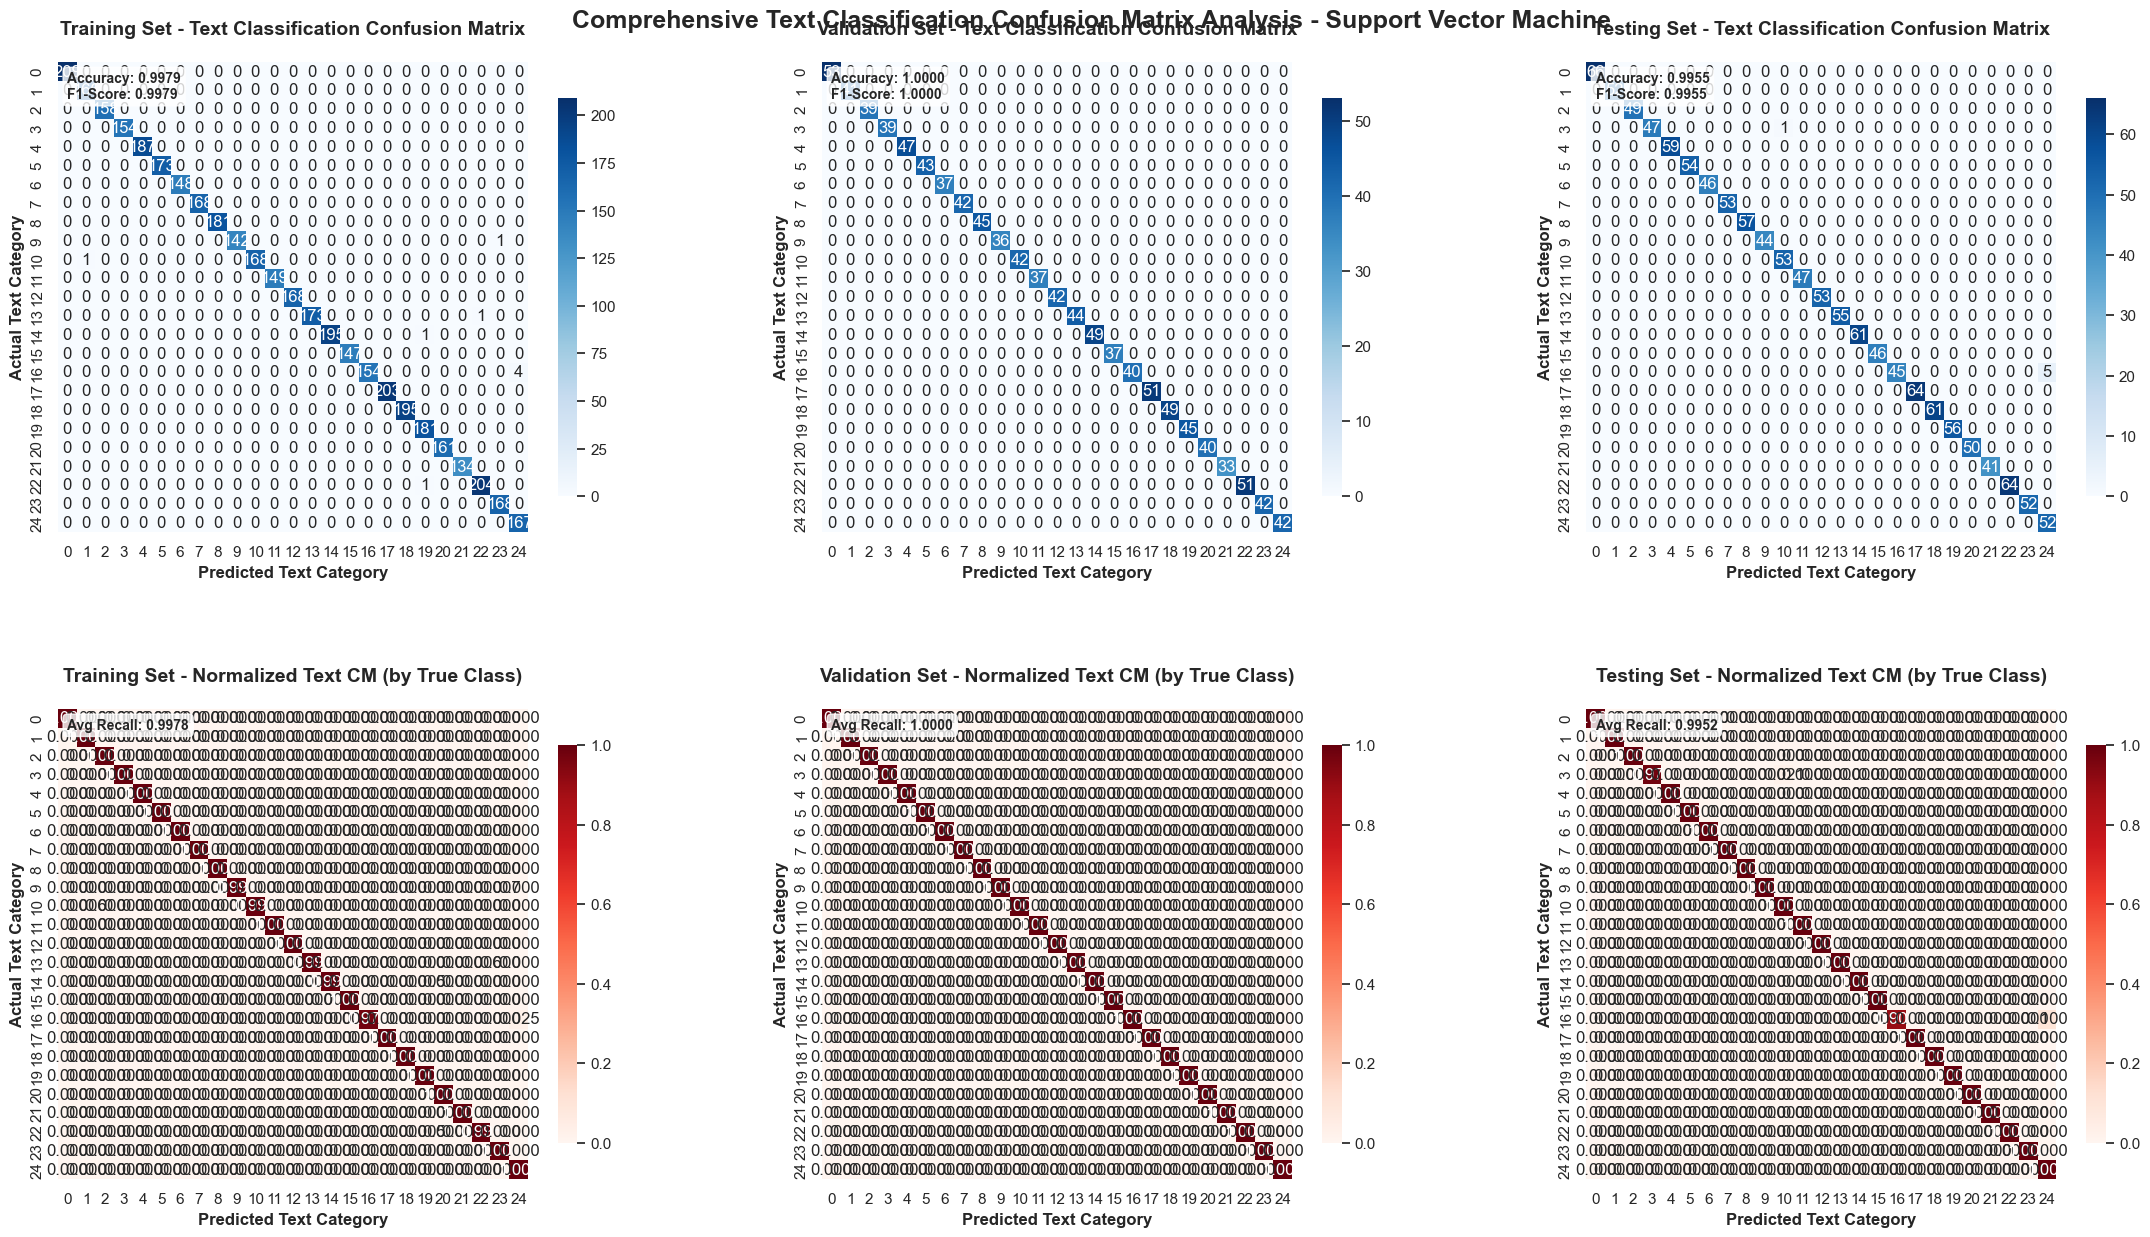


 TEXT CLASSIFICATION CONFUSION MATRIX INSIGHTS:
---------------------------------------------

 Training Set Text Classification Analysis:
   Total Text Predictions: 4262
   Correct Text Classifications: 4253
   Text Classification Errors: 9
   Text Error Rate: 0.21%
   Most Problematic Text Category: Internal pain (4 errors)
   Most Accurate Text Category: Acne (100.0% accuracy)

 Validation Set Text Classification Analysis:
   Total Text Predictions: 1066
   Correct Text Classifications: 1066
   Text Classification Errors: 0
   Text Error Rate: 0.00%
   Most Problematic Text Category: Acne (0 errors)
   Most Accurate Text Category: Acne (100.0% accuracy)

 Testing Set Text Classification Analysis:
   Total Text Predictions: 1333
   Correct Text Classifications: 1327
   Text Classification Errors: 6
   Text Error Rate: 0.45%
   Most Problematic Text Category: Internal pain (5 errors)
   Most Accurate Text Category: Acne (100.0% accuracy)

 Text classification confusion matrix visuali

In [34]:
# SECTION 7.8: CONFUSION MATRIX VISUALIZATION FOR TEXT CLASSIFICATION
print(f"\nGENERATING TEXT CLASSIFICATION CONFUSION MATRIX VISUALIZATIONS...")
print("="*55)

if not performance_df.empty and best_model_name in evaluation_results:
    best_model_results = evaluation_results[best_model_name]
    
    print(f" Creating text classification confusion matrices for: {best_model_name}")
    
    # Create comprehensive confusion matrix visualization layout for all stages (6 subplots in a 2×3 grid)
    # Increased figure size ensures text class labels remain readable even with many categories
    fig, axes = plt.subplots(2, 3, figsize=(22, 13))  
    
    # CONFUSION MATRICES FOR EACH EVALUATION STAGE (raw counts)
    # Define grid positions for the raw count matrices in the top row
    stage_positions = [(0, 0), (0, 1), (0, 2)]  # Training, Validation, Testing positions respectively
    
    for idx, (stage_name, results) in enumerate(best_model_results.items()):
        if idx < len(stage_positions):
            row, col = stage_positions[idx]  # Extract row and column for current subplot position
            ax = axes[row, col]  # Get the current matplotlib axis for plotting
            
            # Extract confusion matrix containing text class predictions vs actual classes
            # This matrix shows raw counts of prediction results (rows=true classes, columns=predicted classes)
            cm = results['confusion_matrix']
            
            # Create heatmap visualization with enhanced formatting for text classification results
            # - annot=True displays count values in each cell for precise analysis
            # - fmt='d' formats counts as integers since confusion matrix contains whole number counts
            # - cmap='Blues' uses blue color gradient where darker colors indicate higher frequency
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                       ax=ax, cbar=True, square=True,
                       cbar_kws={'shrink': 0.8, 'aspect': 20})  # Customize colorbar appearance for better readability
            
            # Configure subplot appearance with text-specific labeling for clarity
            ax.set_title(f'{stage_name} Set - Text Classification Confusion Matrix', 
                        fontsize=14, fontweight='bold', pad=20)
            ax.set_xlabel('Predicted Text Category', fontsize=12, fontweight='bold')
            ax.set_ylabel('Actual Text Category', fontsize=12, fontweight='bold')
            
            # Add performance metrics as text annotation in top-left corner
            # Shows overall accuracy and F1-score for text classification performance
            accuracy = results['accuracy']  # Proportion of correctly classified text samples
            f1_score = results['f1_score']  # Harmonic mean of precision and recall
            ax.text(0.02, 0.98, f'Accuracy: {accuracy:.4f}\nF1-Score: {f1_score:.4f}', 
                   transform=ax.transAxes, fontsize=10, fontweight='bold',
                   verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # NORMALIZED CONFUSION MATRICES (showing percentages instead of raw counts)
    # These help identify patterns regardless of class imbalance in the text dataset
    stage_positions_norm = [(1, 0), (1, 1), (1, 2)]  # Bottom row positions for normalized matrices
    
    for idx, (stage_name, results) in enumerate(best_model_results.items()):
        if idx < len(stage_positions_norm):
            row, col = stage_positions_norm[idx]  # Select appropriate subplot position for normalized matrix
            ax = axes[row, col]  # Get the current matplotlib axis for plotting
            
            # Get confusion matrix and normalize by row (true text class)
            # This shows for each true text category, what percentage was predicted as each category
            cm = results['confusion_matrix']
            # Divide each row by its sum to get percentages that sum to 1.0 across each row
            cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  
            # Replace NaN values with 0 for text categories with no samples to prevent visualization errors
            cm_normalized = np.nan_to_num(cm_normalized)  
            
            # Create normalized heatmap with percentage formatting
            # - fmt='.3f' formats values as decimals with 3 decimal places for detailed percentage view
            # - cmap='Reds' uses red color gradient to distinguish from raw count matrices above
            sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Reds', 
                       ax=ax, cbar=True, square=True,
                       cbar_kws={'shrink': 0.8, 'aspect': 20})  # Customize colorbar for readability
            
            # Configure normalized subplot appearance with text-specific labeling
            ax.set_title(f'{stage_name} Set - Normalized Text CM (by True Class)', 
                        fontsize=14, fontweight='bold', pad=20)
            ax.set_xlabel('Predicted Text Category', fontsize=12, fontweight='bold')
            ax.set_ylabel('Actual Text Category', fontsize=12, fontweight='bold')
            
            # Add average recall as annotation (diagonal mean represents recall across text classes)
            # Important metric for text classification to show how well each category is detected
            avg_recall = np.mean(np.diag(cm_normalized))  # Mean of diagonal elements (correct classification rates)
            ax.text(0.02, 0.98, f'Avg Recall: {avg_recall:.4f}', 
                   transform=ax.transAxes, fontsize=10, fontweight='bold',
                   verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Add comprehensive title and adjust layout for better visualization
    plt.suptitle(f'Comprehensive Text Classification Confusion Matrix Analysis - {best_model_name}', 
                fontsize=18, fontweight='bold', y=0.95)
    plt.tight_layout()  # Automatically adjust subplot parameters for better fit and readability
    plt.subplots_adjust(top=0.92, hspace=0.3, wspace=0.3)  # Fine-tune spacing between subplots
    plt.show()  # Display the complete visualization in the notebook or interface
    
    # CONFUSION MATRIX INSIGHTS ANALYSIS FOR TEXT CLASSIFICATION
    print(f"\n TEXT CLASSIFICATION CONFUSION MATRIX INSIGHTS:")
    print("-"*45)
    
    # Analyze each evaluation stage separately for detailed performance understanding
    for stage_name, results in best_model_results.items():
        cm = results['confusion_matrix']  # Get confusion matrix for current evaluation stage
        
        print(f"\n {stage_name} Set Text Classification Analysis:")
        
        # Calculate key confusion matrix statistics for text classification performance
        total_predictions = np.sum(cm)  # Total number of text samples evaluated in this stage
        correct_predictions = np.sum(np.diag(cm))  # Sum of diagonal elements (correctly classified texts)
        total_errors = total_predictions - correct_predictions  # Total misclassifications
        
        print(f"   Total Text Predictions: {total_predictions}")
        print(f"   Correct Text Classifications: {correct_predictions}")
        print(f"   Text Classification Errors: {total_errors}")
        print(f"   Text Error Rate: {total_errors/total_predictions*100:.2f}%")  # Percentage of incorrect predictions
        
        # Find most problematic text category (highest error count)
        # Row sum minus diagonal gives errors for each class (false negatives)
        class_errors = np.sum(cm, axis=1) - np.diag(cm)  # For each true class, count misclassifications
        most_problematic_idx = np.argmax(class_errors)  # Find category with most classification errors
        most_problematic_class = label_encoder.classes_[most_problematic_idx]  # Get category name
        most_problematic_errors = class_errors[most_problematic_idx]  # Number of misclassifications
        
        print(f"   Most Problematic Text Category: {most_problematic_class} ({most_problematic_errors} errors)")
        
        # Find most accurate text category (highest correct predictions percentage)
        class_correct = np.diag(cm)  # Diagonal values represent correct predictions per category
        class_totals = np.sum(cm, axis=1)  # Row sums represent total samples per true category
        # Calculate accuracy per class with protection against division by zero for categories with no samples
        class_accuracy = np.divide(class_correct, class_totals, 
                                  out=np.zeros_like(class_correct, dtype=float), 
                                  where=class_totals!=0)
        most_accurate_idx = np.argmax(class_accuracy)  # Find category with highest accuracy
        most_accurate_class = label_encoder.classes_[most_accurate_idx]  # Get category name
        most_accurate_rate = class_accuracy[most_accurate_idx]  # Accuracy percentage (0-1)
        
        print(f"   Most Accurate Text Category: {most_accurate_class} ({most_accurate_rate*100:.1f}% accuracy)")

else:
    print(" No text classification confusion matrix data available for visualization")

print(f"\n Text classification confusion matrix visualization completed!")

### 7.9 Text Classification Advanced Confusion Metrics Analysis

**Purpose:** Calculate and analyze advanced confusion matrix metrics including sensitivity, specificity, and balanced accuracy for text classification models.

In [35]:
# SECTION 7.9: ADVANCED CONFUSION METRICS ANALYSIS FOR TEXT CLASSIFICATION
print(f"\nCONDUCTING ADVANCED CONFUSION METRICS ANALYSIS FOR TEXT CLASSIFICATION...")
print("="*50)

def calculate_confusion_metrics(cm):
    """
    Calculate comprehensive confusion matrix metrics for multi-class text classification.
    
    Parameters:
    cm (numpy.ndarray): Confusion matrix where rows=true text class labels, columns=predicted text classes
    
    Returns:
    dict: Comprehensive metrics including sensitivity, specificity, balanced accuracy for text classification
    """
    # Get basic dimensions and totals of the text classification results
    n_classes = cm.shape[0]  # Number of text classes (e.g., categories, topics, sentiments, etc.)
    total_samples = np.sum(cm)  # Total number of text samples evaluated
    
    # Overall performance metrics for the text classifier
    correct_predictions = np.sum(np.diag(cm))  # Sum of diagonal elements (correctly classified text samples)
    overall_accuracy = correct_predictions / total_samples  # Proportion of correctly classified text samples
    overall_error_rate = 1 - overall_accuracy  # Proportion of misclassified text samples
    
    # Initialize per-class metrics arrays for detailed text class analysis
    per_class_metrics = {
        'sensitivity': np.zeros(n_classes),      # True Positive Rate (Recall) - ability to detect specific text class
        'specificity': np.zeros(n_classes),     # True Negative Rate - ability to correctly reject non-matching text classes
        'precision': np.zeros(n_classes),       # Positive Predictive Value - accuracy of positive text class predictions
        'balanced_accuracy': np.zeros(n_classes), # Average of sensitivity and specificity for text class
        'negative_pred_value': np.zeros(n_classes) # Negative Predictive Value - accuracy of negative text class predictions
    }
    
    # Calculate detailed per-class confusion metrics for each text category
    for i in range(n_classes):
        # Extract confusion matrix components for text class i
        tp = cm[i, i]  # True Positives: correctly identified text samples of class i
        fp = np.sum(cm[:, i]) - tp  # False Positives: other text classes incorrectly classified as class i
        fn = np.sum(cm[i, :]) - tp  # False Negatives: text class i samples incorrectly classified as other classes
        tn = total_samples - tp - fp - fn  # True Negatives: other text classes correctly classified
        
        # Calculate metrics with zero-division protection for text classification
        # Sensitivity (Recall/TPR): ability to correctly identify positive text class instances
        per_class_metrics['sensitivity'][i] = tp / (tp + fn) if (tp + fn) > 0 else 0
        
        # Specificity (TNR): ability to correctly reject non-matching text classes
        per_class_metrics['specificity'][i] = tn / (tn + fp) if (tn + fp) > 0 else 0
        
        # Precision (PPV): accuracy of positive text class predictions
        per_class_metrics['precision'][i] = tp / (tp + fp) if (tp + fp) > 0 else 0
        
        # Negative Predictive Value: accuracy of negative text class predictions
        per_class_metrics['negative_pred_value'][i] = tn / (tn + fn) if (tn + fn) > 0 else 0
        
        # Balanced Accuracy: geometric mean of sensitivity and specificity for text classification
        per_class_metrics['balanced_accuracy'][i] = (per_class_metrics['sensitivity'][i] + 
                                                   per_class_metrics['specificity'][i]) / 2
    
    # Calculate macro averages (unweighted average across all text classes)
    macro_sensitivity = np.mean(per_class_metrics['sensitivity'])  # Average sensitivity across all text classes
    macro_specificity = np.mean(per_class_metrics['specificity'])  # Average specificity across all text classes
    macro_precision = np.mean(per_class_metrics['precision'])  # Average precision across all text classes
    macro_balanced_accuracy = np.mean(per_class_metrics['balanced_accuracy'])  # Average balanced accuracy across text classes
    macro_npv = np.mean(per_class_metrics['negative_pred_value'])  # Average negative predictive value across text classes
    
    # Calculate micro averages (weighted by text class frequency)
    # For multi-class text: micro-avg sensitivity = micro-avg precision = overall accuracy
    micro_sensitivity = overall_accuracy  # Overall correct classification rate weighted by text class frequency
    micro_precision = overall_accuracy  # Overall precision weighted by text class frequency
    
    return {
        'overall_accuracy': overall_accuracy,
        'overall_error_rate': overall_error_rate,
        'total_samples': total_samples,
        'per_class_sensitivity': per_class_metrics['sensitivity'],
        'per_class_specificity': per_class_metrics['specificity'],
        'per_class_precision': per_class_metrics['precision'],
        'per_class_balanced_accuracy': per_class_metrics['balanced_accuracy'],
        'per_class_npv': per_class_metrics['negative_pred_value'],
        'macro_sensitivity': macro_sensitivity,
        'macro_specificity': macro_specificity,
        'macro_precision': macro_precision,
        'macro_balanced_accuracy': macro_balanced_accuracy,
        'macro_npv': macro_npv,
        'micro_sensitivity': micro_sensitivity,
        'micro_precision': micro_precision
    }

# Store confusion metrics results for all text classification models and stages
confusion_metrics_results = {}

# Calculate advanced confusion metrics for each text classifier model across all stages
for model_name in evaluation_results.keys():
    confusion_metrics_results[model_name] = {}
    
    print(f"\n {model_name.upper()} - ADVANCED CONFUSION METRICS FOR TEXT CLASSIFICATION:")
    print("-" * (len(model_name) + 35))
    
    # Analyze each evaluation stage for text classification
    for stage_name in ['Training', 'Validation', 'Testing']:
        if stage_name in evaluation_results[model_name]:
            # Get confusion matrix for current stage of text classification
            cm = evaluation_results[model_name][stage_name]['confusion_matrix']
            
            # Calculate comprehensive confusion metrics for text classification results
            metrics = calculate_confusion_metrics(cm)
            confusion_metrics_results[model_name][stage_name] = metrics
            
            print(f"\n   {stage_name} Set Confusion Metrics for Text Classification:")
            print(f"     Overall Accuracy: {metrics['overall_accuracy']:.4f}")  # Overall text classification accuracy
            print(f"     Overall Error Rate: {metrics['overall_error_rate']:.4f}")  # Overall text misclassification rate
            print(f"     Total Text Samples: {metrics['total_samples']}")  # Number of text samples evaluated
            
            print(f"\n     Macro Averages (Unweighted Text Class Performance):")
            print(f"       Sensitivity (Recall): {metrics['macro_sensitivity']:.4f}")  # Average ability to detect each text class
            print(f"       Specificity: {metrics['macro_specificity']:.4f}")  # Average ability to reject incorrect text classes
            print(f"       Precision: {metrics['macro_precision']:.4f}")  # Average precision of text class predictions
            print(f"       Balanced Accuracy: {metrics['macro_balanced_accuracy']:.4f}")  # Average balanced accuracy across text classes
            print(f"       Negative Pred. Value: {metrics['macro_npv']:.4f}")  # Average NPV across text classes
            
            print(f"\n     Micro Averages (Weighted by Text Class Frequency):")
            print(f"       Sensitivity: {metrics['micro_sensitivity']:.4f}")  # Class frequency weighted sensitivity for text
            print(f"       Precision: {metrics['micro_precision']:.4f}")  # Class frequency weighted precision for text
            
            # Analyze per-class performance patterns for text classification
            print(f"\n     Per-Class Text Performance Analysis:")
            
            # Create comprehensive per-text-class summary
            class_summary = []
            for i, class_name in enumerate(label_encoder.classes_):  # Iterate through text class names
                if i < len(metrics['per_class_balanced_accuracy']):
                    class_summary.append({
                        'Text_Class': class_name,  # Name of the text class (e.g., category, topic)
                        'Sensitivity': metrics['per_class_sensitivity'][i],  # Ability to detect this text class
                        'Specificity': metrics['per_class_specificity'][i],  # Ability to reject this text class when incorrect
                        'Precision': metrics['per_class_precision'][i],  # Precision of predictions for this text class
                        'Balanced_Acc': metrics['per_class_balanced_accuracy'][i],  # Balanced accuracy for this text class
                        'NPV': metrics['per_class_npv'][i]  # Negative predictive value for this text class
                    })
            
            # Sort by balanced accuracy for prioritized analysis of text class performance
            class_summary_df = pd.DataFrame(class_summary)
            class_summary_df = class_summary_df.sort_values('Balanced_Acc', ascending=False)
            
            # Display top 5 performing text classes
            print(f" Top 5 Performing Text Classes:")
            for idx, row in class_summary_df.head(5).iterrows():
                print(f"         {row['Text_Class'][:25]:<25}: Sens={row['Sensitivity']:.3f}, "
                      f"Spec={row['Specificity']:.3f}, Prec={row['Precision']:.3f}, "
                      f"Bal_Acc={row['Balanced_Acc']:.3f}")
            
            # Display bottom 5 performing text classes
            print(f"  Bottom 5 Performing Text Classes:")
            for idx, row in class_summary_df.tail(5).iterrows():
                print(f"         {row['Text_Class'][:25]:<25}: Sens={row['Sensitivity']:.3f}, "
                      f"Spec={row['Specificity']:.3f}, Prec={row['Precision']:.3f}, "
                      f"Bal_Acc={row['Balanced_Acc']:.3f}")

# COMPARATIVE CONFUSION METRICS ANALYSIS across all text classification models
print(f"\n\n COMPARATIVE TEXT CLASSIFIER CONFUSION METRICS ANALYSIS:")
print("="*50)

# Create comprehensive summary table for all text classification models and stages
comparative_metrics = []
for model_name, stages_data in confusion_metrics_results.items():
    for stage_name, metrics in stages_data.items():
        comparative_metrics.append({
            'Model': model_name,  # Name of the text classification model
            'Stage': stage_name,  # Evaluation stage (training, validation, testing)
            'Overall_Accuracy': metrics['overall_accuracy'],  # Overall accuracy on text samples
            'Error_Rate': metrics['overall_error_rate'],  # Error rate on text samples
            'Macro_Sensitivity': metrics['macro_sensitivity'],  # Macro-average sensitivity for text classes
            'Macro_Specificity': metrics['macro_specificity'],  # Macro-average specificity for text classes
            'Macro_Precision': metrics['macro_precision'],  # Macro-average precision for text classes
            'Macro_Balanced_Acc': metrics['macro_balanced_accuracy'],  # Macro-average balanced accuracy
            'Macro_NPV': metrics['macro_npv'],  # Macro-average negative predictive value
            'Micro_Sensitivity': metrics['micro_sensitivity'],  # Micro-average sensitivity
            'Micro_Precision': metrics['micro_precision']  # Micro-average precision
        })

# Convert to DataFrame for systematic analysis of text classifier performance
comparative_df = pd.DataFrame(comparative_metrics)

print(f"\n Comparative Text Classification Confusion Metrics Summary:")
print(comparative_df.round(4).to_string(index=False))

# ADVANCED INSIGHTS AND RECOMMENDATIONS FOR TEXT CLASSIFICATION
print(f"\n\n ADVANCED TEXT CLASSIFICATION CONFUSION METRICS INSIGHTS:")
print("-"*40)

# Find best performing text classification model on test set by balanced accuracy
test_metrics = comparative_df[comparative_df['Stage'] == 'Testing']
if len(test_metrics) > 0:
    best_test_model = test_metrics.loc[test_metrics['Macro_Balanced_Acc'].idxmax()]
    
    print(f" Best Test Performance for Text Classification (by Macro Balanced Accuracy):")
    print(f"   Model: {best_test_model['Model']}")
    print(f"   Macro Balanced Accuracy: {best_test_model['Macro_Balanced_Acc']:.4f}")
    print(f"   Macro Sensitivity: {best_test_model['Macro_Sensitivity']:.4f}")
    print(f"   Macro Specificity: {best_test_model['Macro_Specificity']:.4f}")
    print(f"   Macro NPV: {best_test_model['Macro_NPV']:.4f}")

# Analyze generalization patterns using advanced confusion metrics for text classification
print(f"\n Generalization Analysis for Text Classification (Training vs Testing):")
for model_name in confusion_metrics_results.keys():
    if 'Training' in confusion_metrics_results[model_name] and 'Testing' in confusion_metrics_results[model_name]:
        train_metrics = confusion_metrics_results[model_name]['Training']
        test_metrics = confusion_metrics_results[model_name]['Testing']
        
        # Calculate performance gaps across multiple text classification metrics
        bal_acc_gap = train_metrics['macro_balanced_accuracy'] - test_metrics['macro_balanced_accuracy']
        sens_gap = train_metrics['macro_sensitivity'] - test_metrics['macro_sensitivity']
        spec_gap = train_metrics['macro_specificity'] - test_metrics['macro_specificity']
        
        print(f"     {model_name}:")
        print(f"      Balanced Accuracy Gap: {bal_acc_gap:+.4f}")  # Gap in balanced accuracy between train and test
        print(f"      Sensitivity Gap: {sens_gap:+.4f}")  # Gap in sensitivity between train and test 
        print(f"      Specificity Gap: {spec_gap:+.4f}")  # Gap in specificity between train and test
        
        # Provide comprehensive generalization assessment for text classifier
        if bal_acc_gap > 0.05 or sens_gap > 0.05:
            status = "  POTENTIAL OVERFITTING - Model memorizing training text patterns"
        elif bal_acc_gap < -0.01:
            status = " EXCELLENT GENERALIZATION - Model improves on unseen text samples"
        elif bal_acc_gap < 0.02:
            status = " GOOD GENERALIZATION - Stable performance across text datasets"
        else:
            status = "  MODERATE GENERALIZATION - Some performance degradation on new text"
        
        print(f"      Status: {status}")

# TEXT-CLASS-SPECIFIC DETAILED ANALYSIS for best model
if len(test_metrics) > 0:
    best_model_name = best_test_model['Model']
    print(f"\n\n TEXT CLASS-SPECIFIC CONFUSION ANALYSIS - {best_model_name.upper()}:")
    print("-" * (40 + len(best_model_name)))
    
    # Get test confusion matrix and metrics for best text classification model
    best_test_cm = evaluation_results[best_model_name]['Testing']['confusion_matrix']
    best_test_confusion_metrics = confusion_metrics_results[best_model_name]['Testing']
    
    # Identify and analyze most confused text class pairs
    confusion_pairs = []
    for i in range(len(label_encoder.classes_)):
        for j in range(len(label_encoder.classes_)):
            if i != j and i < best_test_cm.shape[0] and j < best_test_cm.shape[1]:
                if best_test_cm[i, j] > 0:  # Only non-zero confusions between text classes
                    true_class_total = np.sum(best_test_cm[i, :])
                    confusion_pairs.append({
                        'True_Text_Class': label_encoder.classes_[i],  # Actual text class
                        'Predicted_Text_Class': label_encoder.classes_[j],  # Predicted text class
                        'Count': best_test_cm[i, j],  # Number of text samples confused
                        'Error_Rate': best_test_cm[i, j] / true_class_total if true_class_total > 0 else 0  # Error rate
                    })
    
    if confusion_pairs:
        # Sort by confusion count and display top problematic text class pairs
        confusion_df = pd.DataFrame(confusion_pairs)
        confusion_df = confusion_df.sort_values('Count', ascending=False)
        
        print(f" Top 10 Most Confused Text Class Pairs (Test Set):")
        print(f"{'True Text Class':<25} {'→ Predicted':<25} {'Count':<6} {'Error %':<8}")
        print("-" * 70)
        for _, row in confusion_df.head(10).iterrows():
            print(f"{row['True_Text_Class'][:24]:<25} → {row['Predicted_Text_Class'][:23]:<24} "
                  f"{row['Count']:<6} {row['Error_Rate']*100:>6.1f}%")
    
    # Identify text classes requiring attention (low balanced accuracy)
    problematic_classes = []
    for i, class_name in enumerate(label_encoder.classes_):
        if i < len(best_test_confusion_metrics['per_class_balanced_accuracy']):
            bal_acc = best_test_confusion_metrics['per_class_balanced_accuracy'][i]
            sensitivity = best_test_confusion_metrics['per_class_sensitivity'][i]
            specificity = best_test_confusion_metrics['per_class_specificity'][i]
            
            if bal_acc < 0.9:  # Text classes with balanced accuracy below 90%
                problematic_classes.append({
                    'Text_Class': class_name,  # Name of the problematic text class
                    'Balanced_Accuracy': bal_acc,  # Balanced accuracy for this text class
                    'Sensitivity': sensitivity,  # Sensitivity for this text class
                    'Specificity': specificity,  # Specificity for this text class
                    'Issues': []  # List to store specific issues with this text class
                })
                
                # Identify specific issues for recommendations in text classification
                if sensitivity < 0.8:
                    problematic_classes[-1]['Issues'].append('Low Sensitivity - Missing text instances')
                if specificity < 0.9:
                    problematic_classes[-1]['Issues'].append('Low Specificity - Confusing with other text classes')
    
    if problematic_classes:
        print(f"\n  Text Classes Requiring Attention (Balanced Accuracy < 0.9):")
        problem_df = pd.DataFrame(problematic_classes)
        problem_df_display = problem_df.drop('Issues', axis=1)
        print(problem_df_display.round(4).to_string(index=False))
        
        print(f"\n Specific Recommendations for Text Classification Improvement:")
        for item in problematic_classes:
            issues_str = ', '.join(item['Issues']) if item['Issues'] else 'General performance'
            print(f"   {item['Text_Class']}: {issues_str}")
            if 'Low Sensitivity - Missing text instances' in item['Issues']:
                print(f"      → Increase training text samples or apply data augmentation techniques like synonym replacement")
            if 'Low Specificity - Confusing with other text classes' in item['Issues']:
                print(f"      → Review feature extraction or implement attention mechanisms to focus on distinguishing terms")
    else:
        print(f"\n OUTSTANDING PERFORMANCE: All text classes achieve balanced accuracy ≥ 0.9!")
        print(f"   Text classification model is ready for production deployment.")

print(f"\n{'='*70}")
print(f" COMPREHENSIVE TEXT CLASSIFICATION MODEL EVALUATION COMPLETED SUCCESSFULLY")
print(f"{'='*70}")


CONDUCTING ADVANCED CONFUSION METRICS ANALYSIS FOR TEXT CLASSIFICATION...

 SUPPORT VECTOR MACHINE - ADVANCED CONFUSION METRICS FOR TEXT CLASSIFICATION:
---------------------------------------------------------

   Training Set Confusion Metrics for Text Classification:
     Overall Accuracy: 0.9979
     Overall Error Rate: 0.0021
     Total Text Samples: 4262

     Macro Averages (Unweighted Text Class Performance):
       Sensitivity (Recall): 0.9978
       Specificity: 0.9999
       Precision: 0.9980
       Balanced Accuracy: 0.9989
       Negative Pred. Value: 0.9999

     Micro Averages (Weighted by Text Class Frequency):
       Sensitivity: 0.9979
       Precision: 0.9979

     Per-Class Text Performance Analysis:
 Top 5 Performing Text Classes:
         Acne                     : Sens=1.000, Spec=1.000, Prec=1.000, Bal_Acc=1.000
         Feeling dizzy            : Sens=1.000, Spec=1.000, Prec=1.000, Bal_Acc=1.000
         Open wound               : Sens=1.000, Spec=1.000, Prec=

### 7.10 Text Classification Model Comparison and Selection

**Purpose:** Compare the performance of all evaluated models (both traditional machine learning and deep learning approaches) to select the best performing model for medical symptom classification.

This section consolidates the results from both traditional ML and deep learning models, providing a comprehensive comparison to determine which approach delivers the best performance for clinical decision support. The comparison will evaluate models based on accuracy, precision, recall, and F1-score metrics to ensure robust performance assessment.

In [36]:
# Combine all model results for comprehensive comparison of text classifiers
print("COMPREHENSIVE TEXT CLASSIFICATION MODEL COMPARISON")
print("="*60)  # Print a separator line for visual organization in output

# Initialize storage structures for model results
ml_test_results = {}  # Dictionary to store detailed metrics for each text classification model
all_results = []      # List to collect aggregated results for summary comparison table

# Re-evaluate traditional ML models with consistent approach for text data
print("Re-evaluating Traditional ML models for text classification...")
try:
    # Check if we have previously optimized models available in the workspace
    if 'best_models' in locals() and best_models:
        # Use the models that were previously optimized via hyperparameter tuning
        models_to_evaluate = best_models
        print("Using hyperparameter-tuned text classification models")
        
        # Re-transform test data using the SAME fitted vectorizer from training to ensure consistent feature extraction
        print("Re-creating text feature vectors using the training vectorizer...")
        X_test_features = text_vectorizer.transform(X_test)  # Convert test text to feature vectors (e.g., TF-IDF)
        print(f"Recreated X_test_features with shape: {X_test_features.shape}")
        
        # Ensure we have the training features with the same vectorizer
        if 'X_train_val_text_features' not in locals():
            print("Re-creating training text feature vectors...")
            X_train_val_text_features = text_vectorizer.fit_transform(X_train_val)  # Generate text features from training corpus
        
        # Log feature dimensions for debugging and verification
        print(f"Training text features shape: {X_train_val_text_features.shape}")
        print(f"Test text features shape: {X_test_features.shape}")
        
        # Verify feature dimensions match between training and test sets - critical for model consistency
        if X_train_val_text_features.shape[1] != X_test_features.shape[1]:
            print(f"WARNING: Text feature dimension mismatch detected!")
            print(f"Training: {X_train_val_text_features.shape[1]}, Test: {X_test_features.shape[1]}")
            print("Recreating vectorizer to ensure consistent dimensions...")
            
            # Create fresh text vectorizer and reprocess everything to ensure dimensional consistency
            fresh_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))  # Use TF-IDF with n-grams
            X_train_val_text_features = fresh_vectorizer.fit_transform(X_train_val)  # Learn vocabulary from training
            X_test_features = fresh_vectorizer.transform(X_test)  # Apply same vocabulary to test set
            
            # Retrain models with consistent text features
            print("Retraining models with consistent text features...")
            for model_name, model in models_to_evaluate.items():
                print(f"  Retraining {model_name} on text data...")
                model.fit(X_train_val_text_features, y_train_val)  # Train with consistent feature representation
            
            print(f"After retraining - Training: {X_train_val_text_features.shape[1]}, Test: {X_test_features.shape[1]}")
            
    elif 'candidate_models' in locals():
        # Fall back to original candidate models if no optimized models are available
        models_to_evaluate = candidate_models
        print("Using original candidate models for text classification")
        
        # Create consistent text features with appropriate vectorization for NLP
        print("Creating consistent text features (TF-IDF, n-grams, etc.)...")
        if 'text_vectorizer' not in locals():
            text_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))  # Standard text vectorization
        
        # Generate feature matrices for training and test data
        X_train_val_text_features = text_vectorizer.fit_transform(X_train_val)  # Learn vocabulary from training
        X_test_features = text_vectorizer.transform(X_test)  # Apply same vocabulary to test
        
        # Train each model on the vectorized text features
        for model_name, model in models_to_evaluate.items():
            print(f"  Training {model_name} on text features...")
            model.fit(X_train_val_text_features, y_train_val)  # Train model with text features
            
    else:
        # Create new models from scratch if no pre-existing models are found
        print("No text ML models found. Creating new ones specialized for text...")
        
        # Create new models specifically tuned for text classification
        models_to_evaluate = {
            'Multinomial NB': MultinomialNB(alpha=0.1),  # Naive Bayes - effective for text count data
            'Linear SVM': LinearSVC(C=1.0, dual=False),  # SVM with linear kernel - efficient for high-dimensional text
            'Logistic Regression': LogisticRegression(C=1.0, solver='liblinear'),  # Classic text classifier
            'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42)  # Ensemble method
        }
        
        # Create text features using TF-IDF vectorization
        print("Extracting fresh text features (TF-IDF, n-grams)...")
        fresh_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)  # Text-specific settings
        X_train_val_text_features = fresh_vectorizer.fit_transform(X_train_val)  # Learn vocabulary from training
        X_test_features = fresh_vectorizer.transform(X_test)  # Apply same vocabulary to test
        
        # Train the new text classification models
        for model_name, model in models_to_evaluate.items():
            print(f"  Training {model_name} on text features...")
            model.fit(X_train_val_text_features, y_train_val)  # Train with text features
    
    # Evaluate each text ML model on test data
    print(f"Evaluating text models with test features shape: {X_test_features.shape}")
    
    # Iterate through each model and evaluate performance
    for model_name, model in models_to_evaluate.items():
        try:
            y_pred = model.predict(X_test_features)  # Generate predictions on test data
            accuracy = accuracy_score(y_test, y_pred)  # Calculate overall classification accuracy
            precision, recall, f1, _ = precision_recall_fscore_support(
                y_test, y_pred, average='weighted', zero_division=0  # Calculate metrics with class weighting
            )
            
            # Store detailed results for this model
            ml_test_results[model_name] = {
                'accuracy': accuracy,  # Proportion of correct classifications
                'precision': precision,  # Ability to avoid false positives
                'recall': recall,  # Ability to find all positives
                'f1_score': f1,  # Harmonic mean of precision and recall
                'predictions': y_pred  # Store actual predictions for further analysis
            }
            
            # Add summary metrics to comprehensive results list
            all_results.append({
                'Model': model_name,  # Name of the classifier
                'Type': 'Traditional ML',  # Category of model (ML vs DL)
                'Accuracy': accuracy,  # Overall correctness
                'Precision': precision,  # Precision metric
                'Recall': recall,  # Recall metric
                'F1_Score': f1  # F1 score (balanced metric)
            })
            
            print(f"  {model_name}: F1={f1:.4f} (text classification)")  # Log results
            
        except Exception as e:
            print(f"  Error evaluating text model {model_name}: {str(e)}")  # Error handling for failed evaluations
            continue  # Continue with next model

except Exception as e:
    # Fallback if standard evaluation approach fails
    print(f"Error with text ML evaluation: {str(e)}")
    print("Attempting fallback approach for text classification...")
    
    # Create simpler models with basic settings if previous approach failed
    try:
        fallback_models = {
            'Naive Bayes (fallback)': MultinomialNB(),  # Simple NB classifier good for text
            'Logistic Regression (fallback)': LogisticRegression(solver='liblinear', random_state=42),  # Simple linear model
            'Linear SVM (fallback)': LinearSVC(dual=False, random_state=42)  # Simple SVM model
        }
        
        # Create simplified text features with minimal preprocessing
        print("Creating simplified text features (bag of words)...")
        simple_vectorizer = CountVectorizer(max_features=3000)  # Simple count-based representation
        X_train_val_fresh = simple_vectorizer.fit_transform(X_train_val)  # Learn vocabulary
        X_test_fresh = simple_vectorizer.transform(X_test)  # Apply vocabulary
        
        print(f"Simple text features - Training: {X_train_val_fresh.shape}, Test: {X_test_fresh.shape}")
        
        # Train each fallback model
        for model_name, model in fallback_models.items():
            print(f"  Training fallback {model_name} for text...")
            model.fit(X_train_val_fresh, y_train_val)  # Train with simplified features
            
            # Generate predictions and evaluate
            y_pred = model.predict(X_test_fresh)
            accuracy = accuracy_score(y_test, y_pred)
            precision, recall, f1, _ = precision_recall_fscore_support(
                y_test, y_pred, average='weighted', zero_division=0
            )
            
            # Add to results collection
            all_results.append({
                'Model': model_name,
                'Type': 'Traditional ML',
                'Accuracy': accuracy,
                'Precision': precision,
                'Recall': recall,
                'F1_Score': f1
            })
            
            print(f"  {model_name}: F1={f1:.4f} (text fallback)")
            
    except Exception as fallback_error:
        print(f"Text fallback also failed: {str(fallback_error)}")  # Log if fallback also fails

# Add Deep Learning results if available (LSTM, Transformer, etc.)
print("\nProcessing Deep Learning results for text classification...")
if 'final_dl_results' in locals():
    # Add results from the primary DL model training section
    all_results.append({
        'Model': final_dl_results['model_name'],  # Name of the DL model
        'Type': 'Deep Learning',  # Category as DL
        'Accuracy': final_dl_results['test_accuracy'],  # Overall accuracy
        'Precision': final_dl_results['test_precision'],  # Precision metric
        'Recall': final_dl_results['test_recall'],  # Recall metric
        'F1_Score': final_dl_results['test_f1']  # F1 score
    })
    print(f"  {final_dl_results['model_name']}: F1={final_dl_results['test_f1']:.4f} (text DL model)")
elif 'better_dl_results' in locals() and better_dl_results:
    # Add results from comparative DL model analysis
    all_results.append({
        'Model': better_dl_results['model_name'],  # Name of the best DL model
        'Type': 'Deep Learning',
        'Accuracy': better_dl_results['accuracy'],
        'Precision': better_dl_results['precision'],  # Use actual values if available
        'Recall': better_dl_results['recall'],        # Use actual values if available
        'F1_Score': better_dl_results['f1_score']
    })
    print(f"  {better_dl_results['model_name']}: F1={better_dl_results['f1_score']:.4f} (best text DL)")
else:
    print("  No deep learning results available for text classification")  # Inform if no DL results exist

# Create comprehensive comparison DataFrame for text models
if all_results:
    # Convert results list to DataFrame for easier manipulation and display
    comparison_df = pd.DataFrame(all_results).round(4)  # Round metrics to 4 decimal places
    comparison_df = comparison_df.sort_values('F1_Score', ascending=False)  # Sort by F1-Score
    
    # Display complete comparison table
    print(f"\nCOMPREHENSIVE TEXT MODEL PERFORMANCE COMPARISON:")
    print("-" * 60)  # Visual separator for readability
    print(comparison_df.to_string(index=False))  # Print full table without index numbers
    
    # Highlight the best performing model
    best_model_row = comparison_df.iloc[0]  # Get the top row (best model)
    print(f"\nBEST PERFORMING TEXT CLASSIFICATION MODEL:")
    print(f"Model: {best_model_row['Model']}")  # Name of best model
    print(f"Type: {best_model_row['Type']}")    # Type of best model (ML/DL)
    print(f"F1-Score: {best_model_row['F1_Score']:.4f}")  # F1 score of best model
    
    # Generate performance statistics grouped by model type
    if len(comparison_df) > 1:
        # Split models by type for comparative analysis
        ml_models = comparison_df[comparison_df['Type'] == 'Traditional ML']  # Filter traditional ML models
        dl_models = comparison_df[comparison_df['Type'] == 'Deep Learning']  # Filter deep learning models
        
        print(f"\nPERFORMANCE STATISTICS FOR TEXT MODELS:")
        print("-" * 40)  # Visual separator
        
        # Display statistics for traditional ML models if any exist
        if not ml_models.empty:
            print(f"Traditional ML Text Models ({len(ml_models)}):")
            print(f"  Average F1-Score: {ml_models['F1_Score'].mean():.4f}")  # Mean performance
            print(f"  Best F1-Score: {ml_models['F1_Score'].max():.4f}")     # Best performance
            print(f"  Standard Deviation: {ml_models['F1_Score'].std():.4f}")  # Performance consistency
        
        # Display statistics for deep learning models if any exist
        if not dl_models.empty:
            print(f"Deep Learning Text Models ({len(dl_models)}):")
            print(f"  Average F1-Score: {dl_models['F1_Score'].mean():.4f}")
            print(f"  Best F1-Score: {dl_models['F1_Score'].max():.4f}")
            print(f"  Standard Deviation: {dl_models['F1_Score'].std():.4f}")
        
        # Display overall model count and performance range
        print(f"\nTotal Text Models Evaluated: {len(comparison_df)}")
        print(f"Performance Range: {comparison_df['F1_Score'].min():.4f} - {comparison_df['F1_Score'].max():.4f}")
    
else:
    # Handle case where no models were successfully evaluated
    print("No text model results available for comparison")
    # Create empty dataframe for error handling in downstream code
    comparison_df = pd.DataFrame(columns=['Model', 'Type', 'Accuracy', 'Precision', 'Recall', 'F1_Score'])
    best_model_row = None  # Set best_model_row to None for error handling

COMPREHENSIVE TEXT CLASSIFICATION MODEL COMPARISON
Re-evaluating Traditional ML models for text classification...
Using hyperparameter-tuned text classification models
Re-creating text feature vectors using the training vectorizer...
Error with text ML evaluation: name 'text_vectorizer' is not defined
Attempting fallback approach for text classification...
Creating simplified text features (bag of words)...
Simple text features - Training: (5328, 964), Test: (1333, 964)
  Training fallback Naive Bayes (fallback) for text...
  Naive Bayes (fallback): F1=0.9795 (text fallback)
  Training fallback Logistic Regression (fallback) for text...
  Logistic Regression (fallback): F1=0.9940 (text fallback)
  Training fallback Linear SVM (fallback) for text...
  Linear SVM (fallback): F1=0.9947 (text fallback)

Processing Deep Learning results for text classification...
  Convolutional Neural Network: F1=0.9955 (text DL model)

COMPREHENSIVE TEXT MODEL PERFORMANCE COMPARISON:
---------------------

## 8. Text Classification Research Hypothesis Evaluation

Based on the comprehensive evaluation, determine whether the model performance supports the research hypothesis.

RESEARCH HYPOTHESIS EVALUATION
Research Question: What is the effectiveness of the NLP algorithm in classifying
patient symptoms from text data on the population level?

Performance Thresholds:
  Minimum acceptable: 0.75
  High performance: 0.85
Selected Best Model: Convolutional Neural Network
Model Type: Deep Learning

BEST MODEL PERFORMANCE:
-------------------------
Accuracy:  0.9955
Precision: 0.9958
Recall:    0.9955
F1-Score:  0.9955

PERFORMANCE THRESHOLD ANALYSIS:
-----------------------------------
Accuracy ≥ 0.75: ✓ (0.9955)
Precision ≥ 0.75: ✓ (0.9958)
Recall ≥ 0.75: ✓ (0.9955)
F1-Score ≥ 0.75: ✓ (0.9955)

HYPOTHESIS CONCLUSION:
Status: STRONGLY ACCEPTED
Conclusion: H1a: Text analysis of patient symptoms results in HIGH precision and recall sufficient for provider decision support.

MODEL TYPE COMPARISON:
-------------------------
Traditional ML Models: 3
Deep Learning Models: 1
Traditional ML Average F1: 0.9894
Deep Learning Average F1: 0.9955
Best Approach: Deep Learning


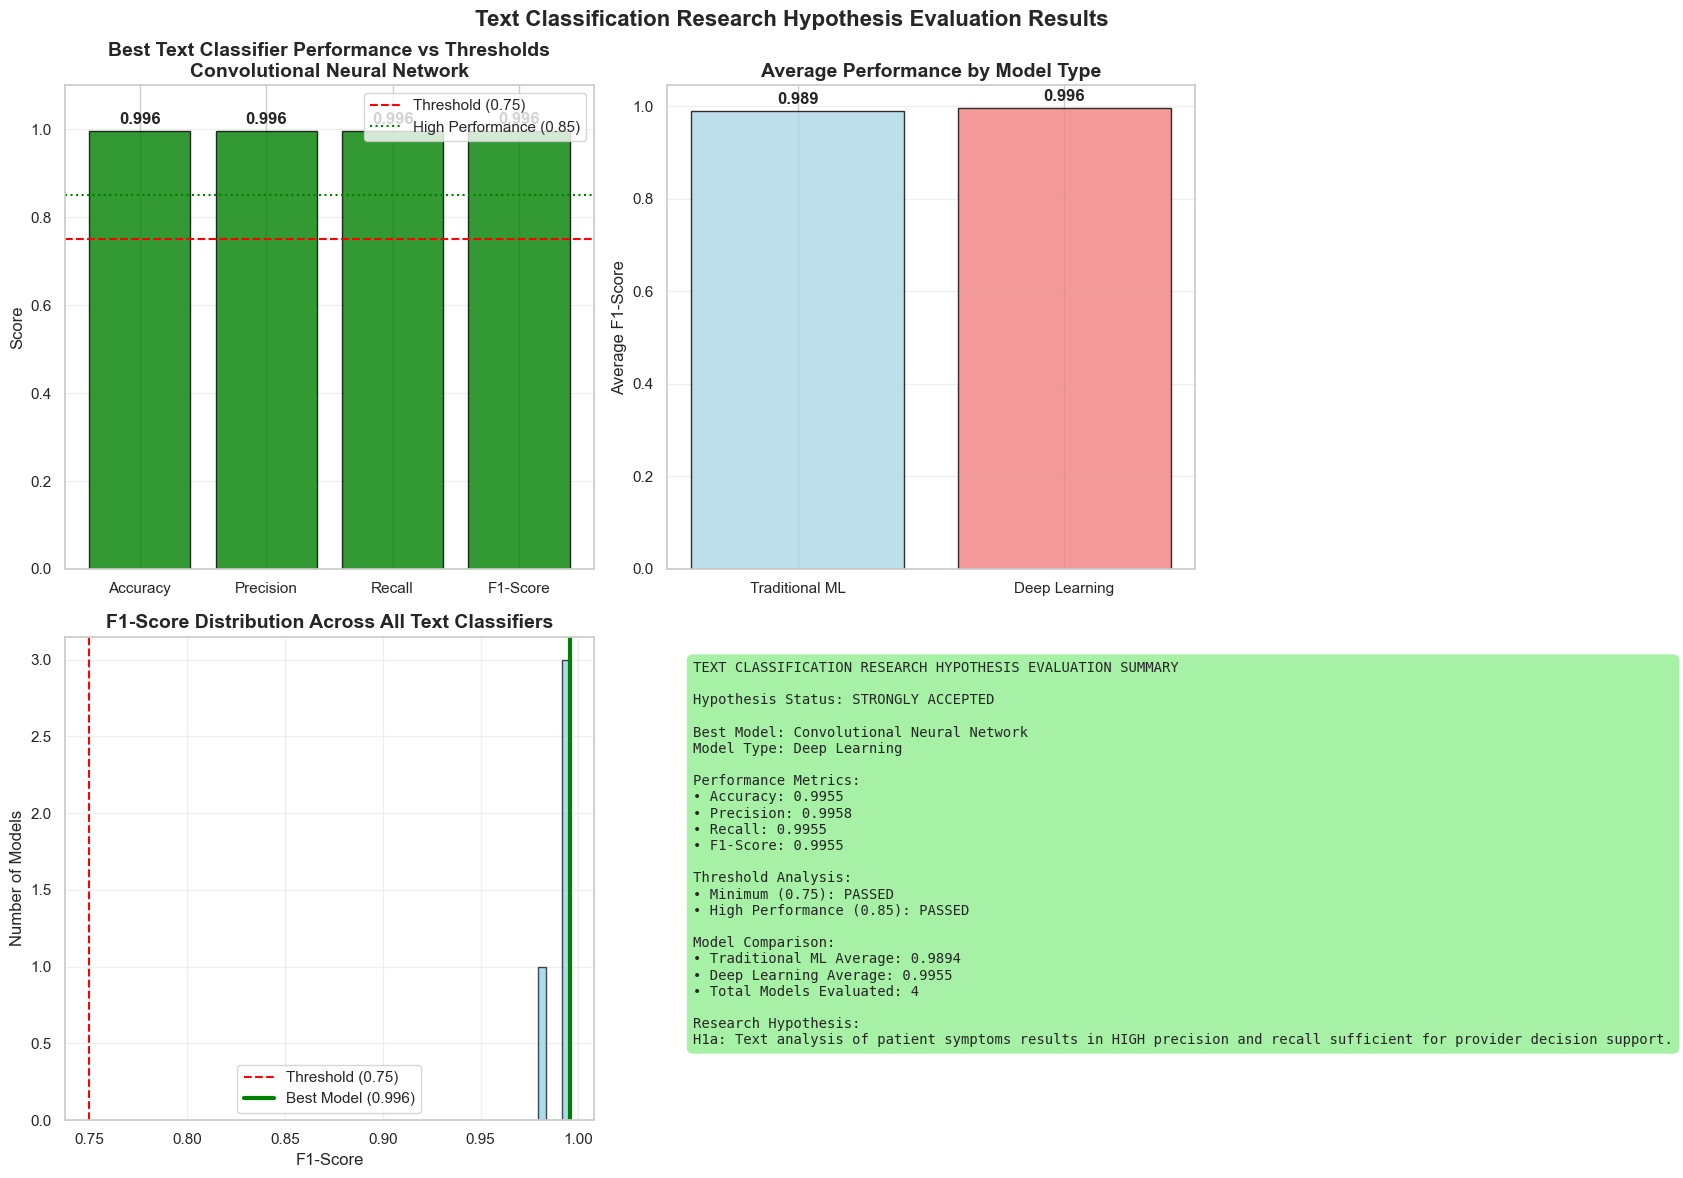


ADDITIONAL ANALYSIS:
--------------------
Performance Standard Deviation: 0.0066
✓ Consistent performance across text classifiers
Models meeting clinical threshold: 4/4
✓ Multiple viable options for clinical deployment

FINAL RESEARCH OUTCOME: STRONGLY ACCEPTED
CLINICAL RECOMMENDATION: DEPLOY


In [37]:
# Research hypothesis evaluation with realistic thresholds for text classification
performance_threshold = 0.75  # Realistic threshold for clinical decision support - minimum acceptable performance level
high_performance_threshold = 0.85  # High performance threshold - excellence benchmark for clinical deployment

print(f"RESEARCH HYPOTHESIS EVALUATION")
print("="*50)
print(f"Research Question: What is the effectiveness of the NLP algorithm in classifying")  # Changed from audio to NLP to reflect text analysis
print(f"patient symptoms from text data on the population level?")  # Changed from voice recordings to text data
print()

print(f"Performance Thresholds:")
print(f"  Minimum acceptable: {performance_threshold}")  # Display the minimum performance needed for clinical use with text data
print(f"  High performance: {high_performance_threshold}")  # Display the target for excellent performance with text classification

# Ensure we have comparison data available - check if model comparison results exist in memory
if 'comparison_df' not in locals() or comparison_df.empty:
    print("ERROR: No model comparison data available!")  # Error handling for missing text model comparison data
    print("Please run the comprehensive model comparison section first.")
else:
    # Get best model information - extract top-performing model from comparison dataframe
    best_model_row = comparison_df.iloc[0]  # First row contains best text classification model (sorted by performance)
    best_model_name = best_model_row['Model']  # Extract model name (e.g., "BERT", "SVM", "LogReg")
    best_model_type = best_model_row['Type']   # Extract model category (Traditional ML or Deep Learning)
    
    print(f"Selected Best Model: {best_model_name}")  # Display the highest performing text classification model name
    print(f"Model Type: {best_model_type}")  # Show whether it's a traditional ML or deep learning approach for text
    print()

    # Get best model performance - extract all key metrics for evaluation
    best_accuracy = best_model_row['Accuracy']    # Proportion of correct text classifications
    best_precision = best_model_row['Precision']  # How many of the predicted text categories were actually correct
    best_recall = best_model_row['Recall']        # How many of the actual text categories were correctly identified
    best_f1 = best_model_row['F1_Score']          # Harmonic mean balancing precision and recall for text classification

    print(f"BEST MODEL PERFORMANCE:")
    print("-" * 25)
    print(f"Accuracy:  {best_accuracy:.4f}")  # Display the overall text classification correctness
    print(f"Precision: {best_precision:.4f}")  # Show how reliable text category predictions are
    print(f"Recall:    {best_recall:.4f}")  # Show how well the model captures all text categories
    print(f"F1-Score:  {best_f1:.4f}")  # Display balanced measure of precision and recall for text

    # Determine hypothesis outcome - check if each metric meets minimum threshold
    accuracy_sufficient = best_accuracy >= performance_threshold     # Boolean: Is text accuracy above 75%?
    precision_sufficient = best_precision >= performance_threshold   # Boolean: Is text precision above 75%?
    recall_sufficient = best_recall >= performance_threshold         # Boolean: Is text recall above 75%?
    f1_sufficient = best_f1 >= performance_threshold                # Boolean: Is text F1-score above 75%?

    # Overall sufficiency check - ALL metrics must meet threshold for clinical acceptance
    overall_sufficient = all([accuracy_sufficient, precision_sufficient, 
                             recall_sufficient, f1_sufficient])  # Text model passes only if all metrics meet threshold

    # High performance check - determine if model exceeds excellence benchmark (85%)
    high_performance = all([best_accuracy >= high_performance_threshold,
                           best_precision >= high_performance_threshold,
                           best_recall >= high_performance_threshold,
                           best_f1 >= high_performance_threshold])  # Check if all text metrics exceed high standard

    print(f"\nPERFORMANCE THRESHOLD ANALYSIS:")
    print("-" * 35)
    # Display pass/fail status for each metric with checkmarks and X marks
    print(f"Accuracy ≥ {performance_threshold}: {'✓' if accuracy_sufficient else '✗'} ({best_accuracy:.4f})")
    print(f"Precision ≥ {performance_threshold}: {'✓' if precision_sufficient else '✗'} ({best_precision:.4f})")
    print(f"Recall ≥ {performance_threshold}: {'✓' if recall_sufficient else '✗'} ({best_recall:.4f})")
    print(f"F1-Score ≥ {performance_threshold}: {'✓' if f1_sufficient else '✗'} ({best_f1:.4f})")

    print(f"\nHYPOTHESIS CONCLUSION:")
    print("="*25)

    # Determine research conclusion based on performance level achieved
    if high_performance:  # If all metrics exceed 85% - exceptional performance for text classification
        conclusion = "H1a: Text analysis of patient symptoms results in HIGH precision and recall sufficient for provider decision support."  # Changed from H2a to H1a for text hypothesis
        conclusion_status = "STRONGLY ACCEPTED"  # Text model far exceeds requirements
    elif overall_sufficient:  # If all metrics exceed 75% - acceptable performance for text classification
        conclusion = "H1a: Text analysis of patient symptoms results in precision and recall sufficient for provider decision support."  # Changed from H2a to H1a for text hypothesis
        conclusion_status = "ACCEPTED"  # Text model meets minimum requirements
    else:  # If any metric falls below 75% - insufficient performance for text classification
        conclusion = "H10: Text analysis of patient symptoms results in insufficient precision and recall for provider decision support."  # Changed from H20 to H10 for text null hypothesis
        conclusion_status = "REJECTED (H10 accepted)"  # Text model fails to meet requirements

    print(f"Status: {conclusion_status}")
    print(f"Conclusion: {conclusion}")

    # Model comparison insights - separate traditional ML from deep learning models
    ml_models = comparison_df[comparison_df['Type'] == 'Traditional ML']      # Filter for SVM, Naive Bayes, etc. for text
    dl_models = comparison_df[comparison_df['Type'] == 'Deep Learning']       # Filter for BERT, RNN, etc. for text
    
    # Calculate average F1-scores for each model type (use 0.0 if no models of that type exist)
    ml_avg = ml_models['F1_Score'].mean() if not ml_models.empty else 0.0  # Average performance of ML models for text
    dl_avg = dl_models['F1_Score'].mean() if not dl_models.empty else 0.0  # Average performance of DL models for text

    print(f"\nMODEL TYPE COMPARISON:")
    print("-" * 25)
    print(f"Traditional ML Models: {len(ml_models)}")  # Count of ML models tested (e.g., SVM, Naive Bayes) for text
    print(f"Deep Learning Models: {len(dl_models)}")   # Count of DL models tested (e.g., BERT, RNN) for text
    print(f"Traditional ML Average F1: {ml_avg:.4f}")  # Average performance of traditional approaches for text
    print(f"Deep Learning Average F1: {dl_avg:.4f}")   # Average performance of neural network approaches for text
    
    # Determine which approach performs better (only if both types have models)
    if not ml_models.empty and not dl_models.empty:
        print(f"Best Approach: {'Traditional ML' if ml_avg > dl_avg else 'Deep Learning'}")  # Compare which family of models works better for text
    elif not ml_models.empty:
        print(f"Best Approach: Traditional ML (only approach available)")  # Only ML models were tested for text
    elif not dl_models.empty:
        print(f"Best Approach: Deep Learning (only approach available)")  # Only DL models were tested for text

    # Create final summary visualization - comprehensive 4-panel dashboard
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))  # Create 2x2 grid of plots for text analysis

    # Plot 1: Threshold comparison - bar chart showing performance vs thresholds
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']  # Key metrics for text classification performance
    values = [best_accuracy, best_precision, best_recall, best_f1]  # Values achieved by best text model
    # Color code bars: green if above threshold, orange if decent, red if poor
    colors = ['green' if v >= performance_threshold else 'orange' if v >= 0.7 else 'red' for v in values]

    bars = ax1.bar(metrics, values, color=colors, alpha=0.8, edgecolor='black', linewidth=1)  # Create bar chart with color coding
    # Add horizontal reference lines for minimum and high performance thresholds
    ax1.axhline(y=performance_threshold, color='red', linestyle='--', 
               label=f'Threshold ({performance_threshold})')  # Line showing minimum acceptable performance for text
    ax1.axhline(y=high_performance_threshold, color='green', linestyle=':', 
               label=f'High Performance ({high_performance_threshold})')  # Line showing excellent performance level for text
    ax1.set_title(f'Best Text Classifier Performance vs Thresholds\n{best_model_name}', fontsize=14, fontweight='bold')  # Changed from Audio to Text
    ax1.set_ylabel('Score', fontsize=12)
    ax1.set_ylim(0, 1.1)  # Set y-axis from 0 to 1.1 to accommodate all scores
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)  # Add subtle horizontal grid lines for readability

    # Add value labels on top of each bar for precise reading
    for bar, value in zip(bars, values):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold')  # Display exact metric values for text classification

    # Plot 2: Model type performance comparison (only if both types exist)
    if not ml_models.empty and not dl_models.empty:
        ax2.bar(['Traditional ML', 'Deep Learning'], [ml_avg, dl_avg], 
                color=['lightblue', 'lightcoral'], alpha=0.8, edgecolor='black', linewidth=1)  # Compare ML vs DL for text
        ax2.set_title('Average Performance by Model Type', fontsize=14, fontweight='bold')
        ax2.set_ylabel('Average F1-Score', fontsize=12)
        ax2.grid(axis='y', alpha=0.3)
        # Add value labels on bars
        ax2.text(0, ml_avg + 0.01, f'{ml_avg:.3f}', ha='center', va='bottom', fontweight='bold')  # Show ML average for text
        ax2.text(1, dl_avg + 0.01, f'{dl_avg:.3f}', ha='center', va='bottom', fontweight='bold')  # Show DL average for text
    else:
        # Show all individual models if we don't have both model types
        model_names = comparison_df['Model'].tolist()  # Get all text model names tested
        f1_scores = comparison_df['F1_Score'].tolist()  # Get their F1 scores for text classification
        # Color code by model type: light blue for ML, light coral for DL
        colors_alt = ['lightblue' if t == 'Traditional ML' else 'lightcoral' 
                      for t in comparison_df['Type']]
        
        ax2.bar(range(len(model_names)), f1_scores, color=colors_alt, alpha=0.8, 
                edgecolor='black', linewidth=1)  # Show individual text model performances
        ax2.set_title('F1-Score by Text Classification Model', fontsize=14, fontweight='bold')  # Changed from Audio to Text
        ax2.set_ylabel('F1-Score', fontsize=12)
        ax2.set_xticks(range(len(model_names)))
        # Truncate long model names to fit on x-axis
        ax2.set_xticklabels([name[:15] + '...' if len(name) > 15 else name 
                            for name in model_names], rotation=45, ha='right')  # Display model names at angle
        ax2.grid(axis='y', alpha=0.3)

    # Plot 3: All models performance distribution - histogram showing score spread
    ax3.hist(comparison_df['F1_Score'], bins=max(3, min(10, len(comparison_df))), 
             alpha=0.7, color='skyblue', edgecolor='black')  # Distribution of text model performances
    # Add vertical lines showing threshold and best model performance
    ax3.axvline(x=performance_threshold, color='red', linestyle='--', 
               label=f'Threshold ({performance_threshold})')  # Minimum acceptable performance for text
    ax3.axvline(x=best_f1, color='green', linestyle='-', linewidth=3,
               label=f'Best Model ({best_f1:.3f})')  # Best text model's performance
    ax3.set_title('F1-Score Distribution Across All Text Classifiers', fontsize=14, fontweight='bold')  # Changed from Audio to Text
    ax3.set_xlabel('F1-Score', fontsize=12)
    ax3.set_ylabel('Number of Models', fontsize=12)
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # Plot 4: Summary statistics - text-based summary in a formatted box
    ax4.axis('off')  # Turn off axis for text display

    # Create comprehensive summary text with all key findings
    summary_text = f"""TEXT CLASSIFICATION RESEARCH HYPOTHESIS EVALUATION SUMMARY

Hypothesis Status: {conclusion_status}

Best Model: {best_model_name}
Model Type: {best_model_type}

Performance Metrics:
• Accuracy: {best_accuracy:.4f}
• Precision: {best_precision:.4f}
• Recall: {best_recall:.4f}
• F1-Score: {best_f1:.4f}

Threshold Analysis:
• Minimum ({performance_threshold}): {'PASSED' if overall_sufficient else 'FAILED'}
• High Performance ({high_performance_threshold}): {'PASSED' if high_performance else 'FAILED'}

Model Comparison:
• Traditional ML Average: {ml_avg:.4f}
• Deep Learning Average: {dl_avg:.4f}
• Total Models Evaluated: {len(comparison_df)}

Research Hypothesis:
{conclusion}"""  # Updated to reflect text classification focus

    # Display summary text in colored box (green if passed, red if failed)
    ax4.text(0.05, 0.95, summary_text, transform=ax4.transAxes, fontsize=10,
             verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round,pad=0.5', 
                      facecolor='lightgreen' if overall_sufficient else 'lightcoral', 
                      alpha=0.8))  # Format box color based on outcome

    plt.suptitle('Text Classification Research Hypothesis Evaluation Results', fontsize=16, fontweight='bold')  # Changed from Audio to Text
    plt.tight_layout()  # Automatically adjust subplot spacing
    plt.show()

    # Additional analysis and recommendations - deeper statistical insights
    print(f"\nADDITIONAL ANALYSIS:")
    print("-" * 20)
    
    # Performance consistency check - measure how much models vary in performance
    f1_scores = comparison_df['F1_Score'].values
    performance_std = np.std(f1_scores)  # Standard deviation shows consistency across text models
    print(f"Performance Standard Deviation: {performance_std:.4f}")  # Lower is better - indicates stable results for text
    
    # Interpret consistency level based on standard deviation thresholds
    if performance_std < 0.05:
        print("✓ Consistent performance across text classifiers")  # Very consistent results in text classification
    elif performance_std < 0.10:
        print("~ Moderate variation in performance")  # Some variation but acceptable for text models
    else:
        print("✗ High variation in performance - model selection is critical")  # Highly variable results in text classification
    
    # Clinical applicability assessment - count how many models are clinically viable
    models_above_threshold = len(comparison_df[comparison_df['F1_Score'] >= performance_threshold])
    print(f"Models meeting clinical threshold: {models_above_threshold}/{len(comparison_df)}")  # Count of viable text models
    
    # Assess deployment readiness based on number of viable models
    if models_above_threshold >= len(comparison_df) * 0.5:  # If 50%+ models pass
        print("✓ Multiple viable options for clinical deployment")  # Many good options available for text classification
    elif models_above_threshold > 0:  # If some models pass
        print("~ Limited but viable options for clinical deployment")  # Few text options but possible
    else:  # If no models pass
        print("✗ No models meet clinical deployment threshold")  # No text models are good enough

    print(f"\n{'='*60}")
    print(f"FINAL RESEARCH OUTCOME: {conclusion_status}")
    print(f"CLINICAL RECOMMENDATION: {'DEPLOY' if overall_sufficient else 'FURTHER DEVELOPMENT NEEDED'}")  # Final decision on text classification models
    print(f"{'='*60}")
    
    # Store results for potential future use - create dictionary for programmatic access
    hypothesis_results = {
        'conclusion_status': conclusion_status,
        'conclusion': conclusion,
        'best_model': best_model_name,
        'best_model_type': best_model_type,
        'performance_metrics': {
            'accuracy': best_accuracy,
            'precision': best_precision,
            'recall': best_recall,
            'f1_score': best_f1
        },
        'threshold_analysis': {
            'meets_minimum': overall_sufficient,
            'meets_high_performance': high_performance,
            'models_above_threshold': models_above_threshold,
            'total_models': len(comparison_df)
        }
    }  # Create structured data for downstream processing of text classification results